# BAB 4 — ANALISIS SARIMA VILA BALI
## Prediksi Tingkat Hunian (Occupancy) | Canggu & Seminyak

---
## 1. Import Library & Konfigurasi

In [2]:
# ── Core
import os
import warnings
import numpy as np
import pandas as pd

# ── Visualisasi
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Statsmodels
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# ── pmdarima (auto_arima)
try:
    from pmdarima import auto_arima
    print('✅ pmdarima tersedia')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pmdarima', '-q'])
    from pmdarima import auto_arima
    print('✅ pmdarima berhasil diinstall')

# ── Sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# ── Scipy
from scipy import stats

# ── Konfigurasi global
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'    : 120,
    'figure.figsize': (14, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# ── Path root data
BASE_PATH = 'data/raw'

# ── Kamus villa (hanya area & warna, tanpa SARIMA order)
VILLA_CONFIG = {
    'briana_villas'  : {'area': 'canggu',   'color': '#3D6BE8'},
    'castello_villas': {'area': 'canggu',   'color': '#7c3aed'},
    'elina_villas'   : {'area': 'canggu',   'color': '#059669'},
    'isola_villas'   : {'area': 'canggu',   'color': '#db2777'},
    'eindra_villas'  : {'area': 'seminyak', 'color': '#d97706'},
    'esha_villas'    : {'area': 'seminyak', 'color': '#b45309'},
    'ozamiz_villas'  : {'area': 'seminyak', 'color': '#9333ea'},
}

print('✅ Library & konfigurasi selesai.')
print(f'   Total villa: {len(VILLA_CONFIG)}')

✅ pmdarima tersedia
✅ Library & konfigurasi selesai.
   Total villa: 7


---
## 2. Helper Functions

In [3]:
from pathlib import Path

# ── BASE_PATH + auto-rename .csv.migrated ─────────────────────────────────
BASE_PATH = r"C:\Users\ASUS\Downloads\TUGAS AKHIR\ta-code\notebook\data\raw"

if not os.path.exists(BASE_PATH):
    print(f"⚠️  BASE_PATH tidak ditemukan: {BASE_PATH}")
else:
    # Rename .csv.migrated → .csv otomatis
    migrated = list(Path(BASE_PATH).rglob("*.csv.migrated"))
    if migrated:
        for f in migrated:
            f.rename(f.with_suffix(""))  # hapus .migrated
        print(f"✅ {len(migrated)} file di-rename (.csv.migrated → .csv)")
    print(f"✅ BASE_PATH OK: {BASE_PATH}")
# ──────────────────────────────────────────────────────────────────────────

def build_path(area, villa, data_type):
    """Bangun path file CSV. data_type: 'financial' atau 'occupancy'"""
    prefix = villa.replace('_villas', '_villa')
    fname  = f'{prefix}_daily_{data_type}.csv'
    return os.path.join(BASE_PATH, area, villa, fname)


def load_raw(path):
    """Load CSV dengan BOM-safe reader."""
    try:
        df = pd.read_csv(path, sep=None, engine='python', encoding='utf-8-sig')
        df.columns = df.columns.str.strip()
        return df
    except FileNotFoundError:
        print(f'  ⚠️  File tidak ditemukan: {path}')
        return None


def parse_villa_date(series):
    s = series.astype(str).str.strip()
    parsed = pd.to_datetime(s, errors='coerce', dayfirst=True)
    if parsed.isna().mean() > 0.3:
        s = s.str.replace(r'^(Sun|Mon|Tue|Wed|Thu|Fri|Sat)\s+', '', regex=True).str.strip()
        parsed = pd.to_datetime(s, errors='coerce', dayfirst=True)
    return parsed


def parse_numeric(series):
    """Parse angka dari string format IDR/USD."""
    s = series.astype(str).str.strip()
    s = s.str.replace(r'[Rp$€IDR\s]', '', regex=True)
    s = s.str.replace(',', '', regex=False)
    return pd.to_numeric(s, errors='coerce')


def parse_occupancy_to_percentage(series):
    s = series.astype(str).str.strip()
    if s.str.contains('%').any():
        result = pd.to_numeric(s.str.replace('%', '', regex=False).str.strip(), errors='coerce')
    else:
        result = pd.to_numeric(s, errors='coerce')
    if result.dropna().max() <= 1.0:
        result = result * 100.0
    return result.clip(0, 100)


print('✅ Helper functions loaded.')

✅ BASE_PATH OK: C:\Users\ASUS\Downloads\TUGAS AKHIR\ta-code\notebook\data\raw
✅ Helper functions loaded.


In [4]:
# Lihat semua kolom untuk baris > 100%
for villa, config in VILLA_CONFIG.items():
    area = config['area']
    path = build_path(area, villa, 'financial')
    df = load_raw(path)
    if df is None:
        continue
    
    df['occ_num'] = df['Occupancy'].astype(str).str.replace('%','').str.strip()
    df['occ_num'] = pd.to_numeric(df['occ_num'], errors='coerce')
    
    over_100 = df[df['occ_num'] > 100]
    if not over_100.empty:
        print(f"\n[{area}/{villa}] — Baris Anomali (SEMUA KOLOM):")
        print(over_100.to_string(index=False))


[canggu/briana_villas] — Baris Anomali (SEMUA KOLOM):
           Date  Booked  Available  Guests Occupancy  Room Revenue IDR  Daily Revenue IDR  Average Daily Revenue IDR  Revenue per Available Room IDR  Revenue per Guest IDR  occ_num
 Wed 9 Oct 2024       2         -1       8      200%              0.00       4,830,921.60               2,415,460.80                    4,830,921.60             603,865.20      200
Thu 10 Oct 2024       2         -1       8      200%              0.00       4,830,921.60               2,415,460.80                    4,830,921.60             603,865.20      200
Fri 11 Oct 2024       2         -1       8      200%              0.00       4,830,921.60               2,415,460.80                    4,830,921.60             603,865.20      200
Sat 12 Oct 2024       2         -1       8      200%              0.00       4,830,921.60               2,415,460.80                    4,830,921.60             603,865.20      200
Sun 13 Oct 2024       2         -1      

In [5]:
# ── SCREENSHOT 1: Data mentah semua villa (format tanggal + occupancy string)
print("Gambar 4.X — Data Mentah Semua Villa: Format Tanggal dan Occupancy (Sebelum Cleaning)")
print("=" * 70)
for villa, config in VILLA_CONFIG.items():
    area = config['area']
    path = build_path(area, villa, 'financial')
    print(f"\n[{area}/{villa}] → {path}")
    df_raw = load_raw(path)
    if df_raw is None:
        print("  ❌ Gagal load!")
        continue
    print(df_raw[['Date', 'Occupancy']].head(5).to_string(index=False))

Gambar 4.X — Data Mentah Semua Villa: Format Tanggal dan Occupancy (Sebelum Cleaning)

[canggu/briana_villas] → C:\Users\ASUS\Downloads\TUGAS AKHIR\ta-code\notebook\data\raw\canggu\briana_villas\briana_villa_daily_financial.csv
          Date Occupancy
Sun 1 Jan 2023      100%
Mon 2 Jan 2023      100%
Tue 3 Jan 2023        0%
Wed 4 Jan 2023        0%
Thu 5 Jan 2023      100%

[canggu/castello_villas] → C:\Users\ASUS\Downloads\TUGAS AKHIR\ta-code\notebook\data\raw\canggu\castello_villas\castello_villa_daily_financial.csv
          Date Occupancy
Sun 1 Jan 2023        0%
Mon 2 Jan 2023        0%
Tue 3 Jan 2023        0%
Wed 4 Jan 2023        0%
Thu 5 Jan 2023        0%

[canggu/elina_villas] → C:\Users\ASUS\Downloads\TUGAS AKHIR\ta-code\notebook\data\raw\canggu\elina_villas\elina_villa_daily_financial.csv
          Date Occupancy
Sun 1 Jan 2023      400%
Mon 2 Jan 2023      400%
Tue 3 Jan 2023      300%
Wed 4 Jan 2023      300%
Thu 5 Jan 2023      200%

[canggu/isola_villas] → C:\Users\A

In [6]:
# ── SCREENSHOT 2: Anomali occupancy semua villa (dengan tanggal)
print("Gambar 4.Y — Nilai Occupancy Semua Villa: Identifikasi Anomali (Sebelum Cleaning)")
print("=" * 70)
for villa, config in VILLA_CONFIG.items():
    area = config['area']
    df_raw = load_raw(build_path(area, villa, 'financial'))
    if df_raw is None:
        continue
    occ_numeric = pd.to_numeric(
        df_raw['Occupancy'].astype(str).str.replace('%','').str.strip(),
        errors='coerce'
    )
    anomali_mask = occ_numeric > 100
    print(f"\n[{area}/{villa}]")
    if anomali_mask.any():
        anomali_df = pd.DataFrame({
            'Date'      : df_raw['Date'][anomali_mask].values,
            'Occupancy' : df_raw['Occupancy'][anomali_mask].values
        })
        print(anomali_df.to_string(index=False))
    else:
        print("  → Tidak ada anomali")

Gambar 4.Y — Nilai Occupancy Semua Villa: Identifikasi Anomali (Sebelum Cleaning)

[canggu/briana_villas]
           Date Occupancy
 Wed 9 Oct 2024      200%
Thu 10 Oct 2024      200%
Fri 11 Oct 2024      200%
Sat 12 Oct 2024      200%
Sun 13 Oct 2024      200%

[canggu/castello_villas]
  → Tidak ada anomali

[canggu/elina_villas]
           Date Occupancy
 Sun 1 Jan 2023      400%
 Mon 2 Jan 2023      400%
 Tue 3 Jan 2023      300%
 Wed 4 Jan 2023      300%
 Thu 5 Jan 2023      200%
Mon 13 Nov 2023      200%
 Sat 8 Jun 2024      200%
 Sun 9 Jun 2024      200%
Mon 10 Jun 2024      200%
Thu 27 Jun 2024      200%
Fri 28 Jun 2024      200%
Wed 18 Sep 2024      200%
Thu 19 Sep 2024      200%
Fri 20 Sep 2024      200%
Fri 27 Dec 2024      300%
Sat 28 Dec 2024      300%
Sun 29 Dec 2024      300%
Mon 30 Dec 2024      300%
Tue 31 Dec 2024      200%
 Wed 1 Jan 2025      200%
 Thu 2 Jan 2025      200%
 Fri 3 Jan 2025      200%
 Sat 4 Jan 2025      200%
 Sun 5 Jan 2025      200%
 Mon 6 Jan 2025  

---
## 3. Load & Clean Data

In [7]:
def clean_occupancy(df, villa_name):
    """
    Bersihkan data dan kembalikan Series occupancy harian (0–100%).
    """
    df = df.copy()
    print(f"\n{'='*65}")
    print(f'[{villa_name}]  shape={df.shape}')

    # Deteksi kolom tanggal
    date_cands = [c for c in df.columns if any(k in c.lower() for k in ['date','tanggal','tgl'])]
    date_col   = date_cands[0] if date_cands else df.columns[0]

    # Deteksi kolom occupancya
    occ_exact = [c for c in df.columns if c.lower().strip() == 'occupancy']
    occ_kw    = [c for c in df.columns
                 if any(k in c.lower() for k in ['occ','hunian','occupied']) and c not in occ_exact]
    occ_col   = (occ_exact + occ_kw)[0] if (occ_exact + occ_kw) else None

    use_computed = False
    if occ_col is None:
        booked_c = [c for c in df.columns if 'booked' in c.lower()]
        avail_c  = [c for c in df.columns if 'available' in c.lower()]
        if booked_c and avail_c:
            use_computed = True
            booked_col, avail_col = booked_c[0], avail_c[0]
            print(f"  → Computed: '{booked_col}' / ('{booked_col}' + '{avail_col}')")
        else:
            occ_col = df.select_dtypes(include=np.number).columns[0]

    print(f"  date_col='{date_col}' | occ_col='{occ_col}'")

    df[date_col] = parse_villa_date(df[date_col])
    df = df.dropna(subset=[date_col]).sort_values(date_col).set_index(date_col)

    if use_computed:
        total  = df[booked_col].add(df[avail_col])
        series = (df[booked_col] / total.replace(0, np.nan)).rename('occupancy') * 100.0
    else:
        series = parse_occupancy_to_percentage(df[occ_col]).rename('occupancy')

    # Reindex harian + interpolasi
    full_idx = pd.date_range(series.index.min(), series.index.max(), freq='D')
    series   = series.reindex(full_idx).interpolate(method='time', limit=7).ffill().bfill().clip(0, 100)

    print(f'  Range: {series.index.min().date()} → {series.index.max().date()}')
    print(f'  Stats: mean={series.mean():.1f}% | std={series.std():.1f}% | '
          f'min={series.min():.1f}% | max={series.max():.1f}%')
    return series


# ── Load semua villa
clean_occ = {}

print('=' * 65)
print('LOADING & CLEANING DATA')
print('=' * 65)

for villa, config in VILLA_CONFIG.items():
    area = config['area']
    df   = load_raw(build_path(area, villa, 'financial'))
    if df is None:
        df = load_raw(build_path(area, villa, 'occupancy'))
    if df is not None:
        clean_occ[villa] = clean_occupancy(df, f'{area}/{villa}')
    else:
        print(f'\n⚠️  [{area}/{villa}] Data tidak ditemukan!')

print(f'\n✅ {len(clean_occ)} villa berhasil di-load.')

LOADING & CLEANING DATA

[canggu/briana_villas]  shape=(1096, 10)
  date_col='Date' | occ_col='Occupancy'
  Range: 2023-01-01 → 2025-12-31
  Stats: mean=69.7% | std=46.0% | min=0.0% | max=100.0%

[canggu/castello_villas]  shape=(1096, 10)
  date_col='Date' | occ_col='Occupancy'
  Range: 2023-01-01 → 2025-12-31
  Stats: mean=45.1% | std=49.8% | min=0.0% | max=100.0%

[canggu/elina_villas]  shape=(1096, 10)
  date_col='Date' | occ_col='Occupancy'
  Range: 2023-01-01 → 2025-12-31
  Stats: mean=34.6% | std=47.6% | min=0.0% | max=100.0%

[canggu/isola_villas]  shape=(1096, 10)
  date_col='Date' | occ_col='Occupancy'
  Range: 2023-01-01 → 2025-12-31
  Stats: mean=57.4% | std=49.5% | min=0.0% | max=100.0%

[seminyak/eindra_villas]  shape=(1096, 10)
  date_col='Date' | occ_col='Occupancy'
  Range: 2023-01-01 → 2025-12-31
  Stats: mean=70.0% | std=45.9% | min=0.0% | max=100.0%

[seminyak/esha_villas]  shape=(1096, 10)
  date_col='Date' | occ_col='Occupancy'
  Range: 2023-01-01 → 2025-12-31
  St

---
## 4. Visualisasi EDA — Time Series Bulanan

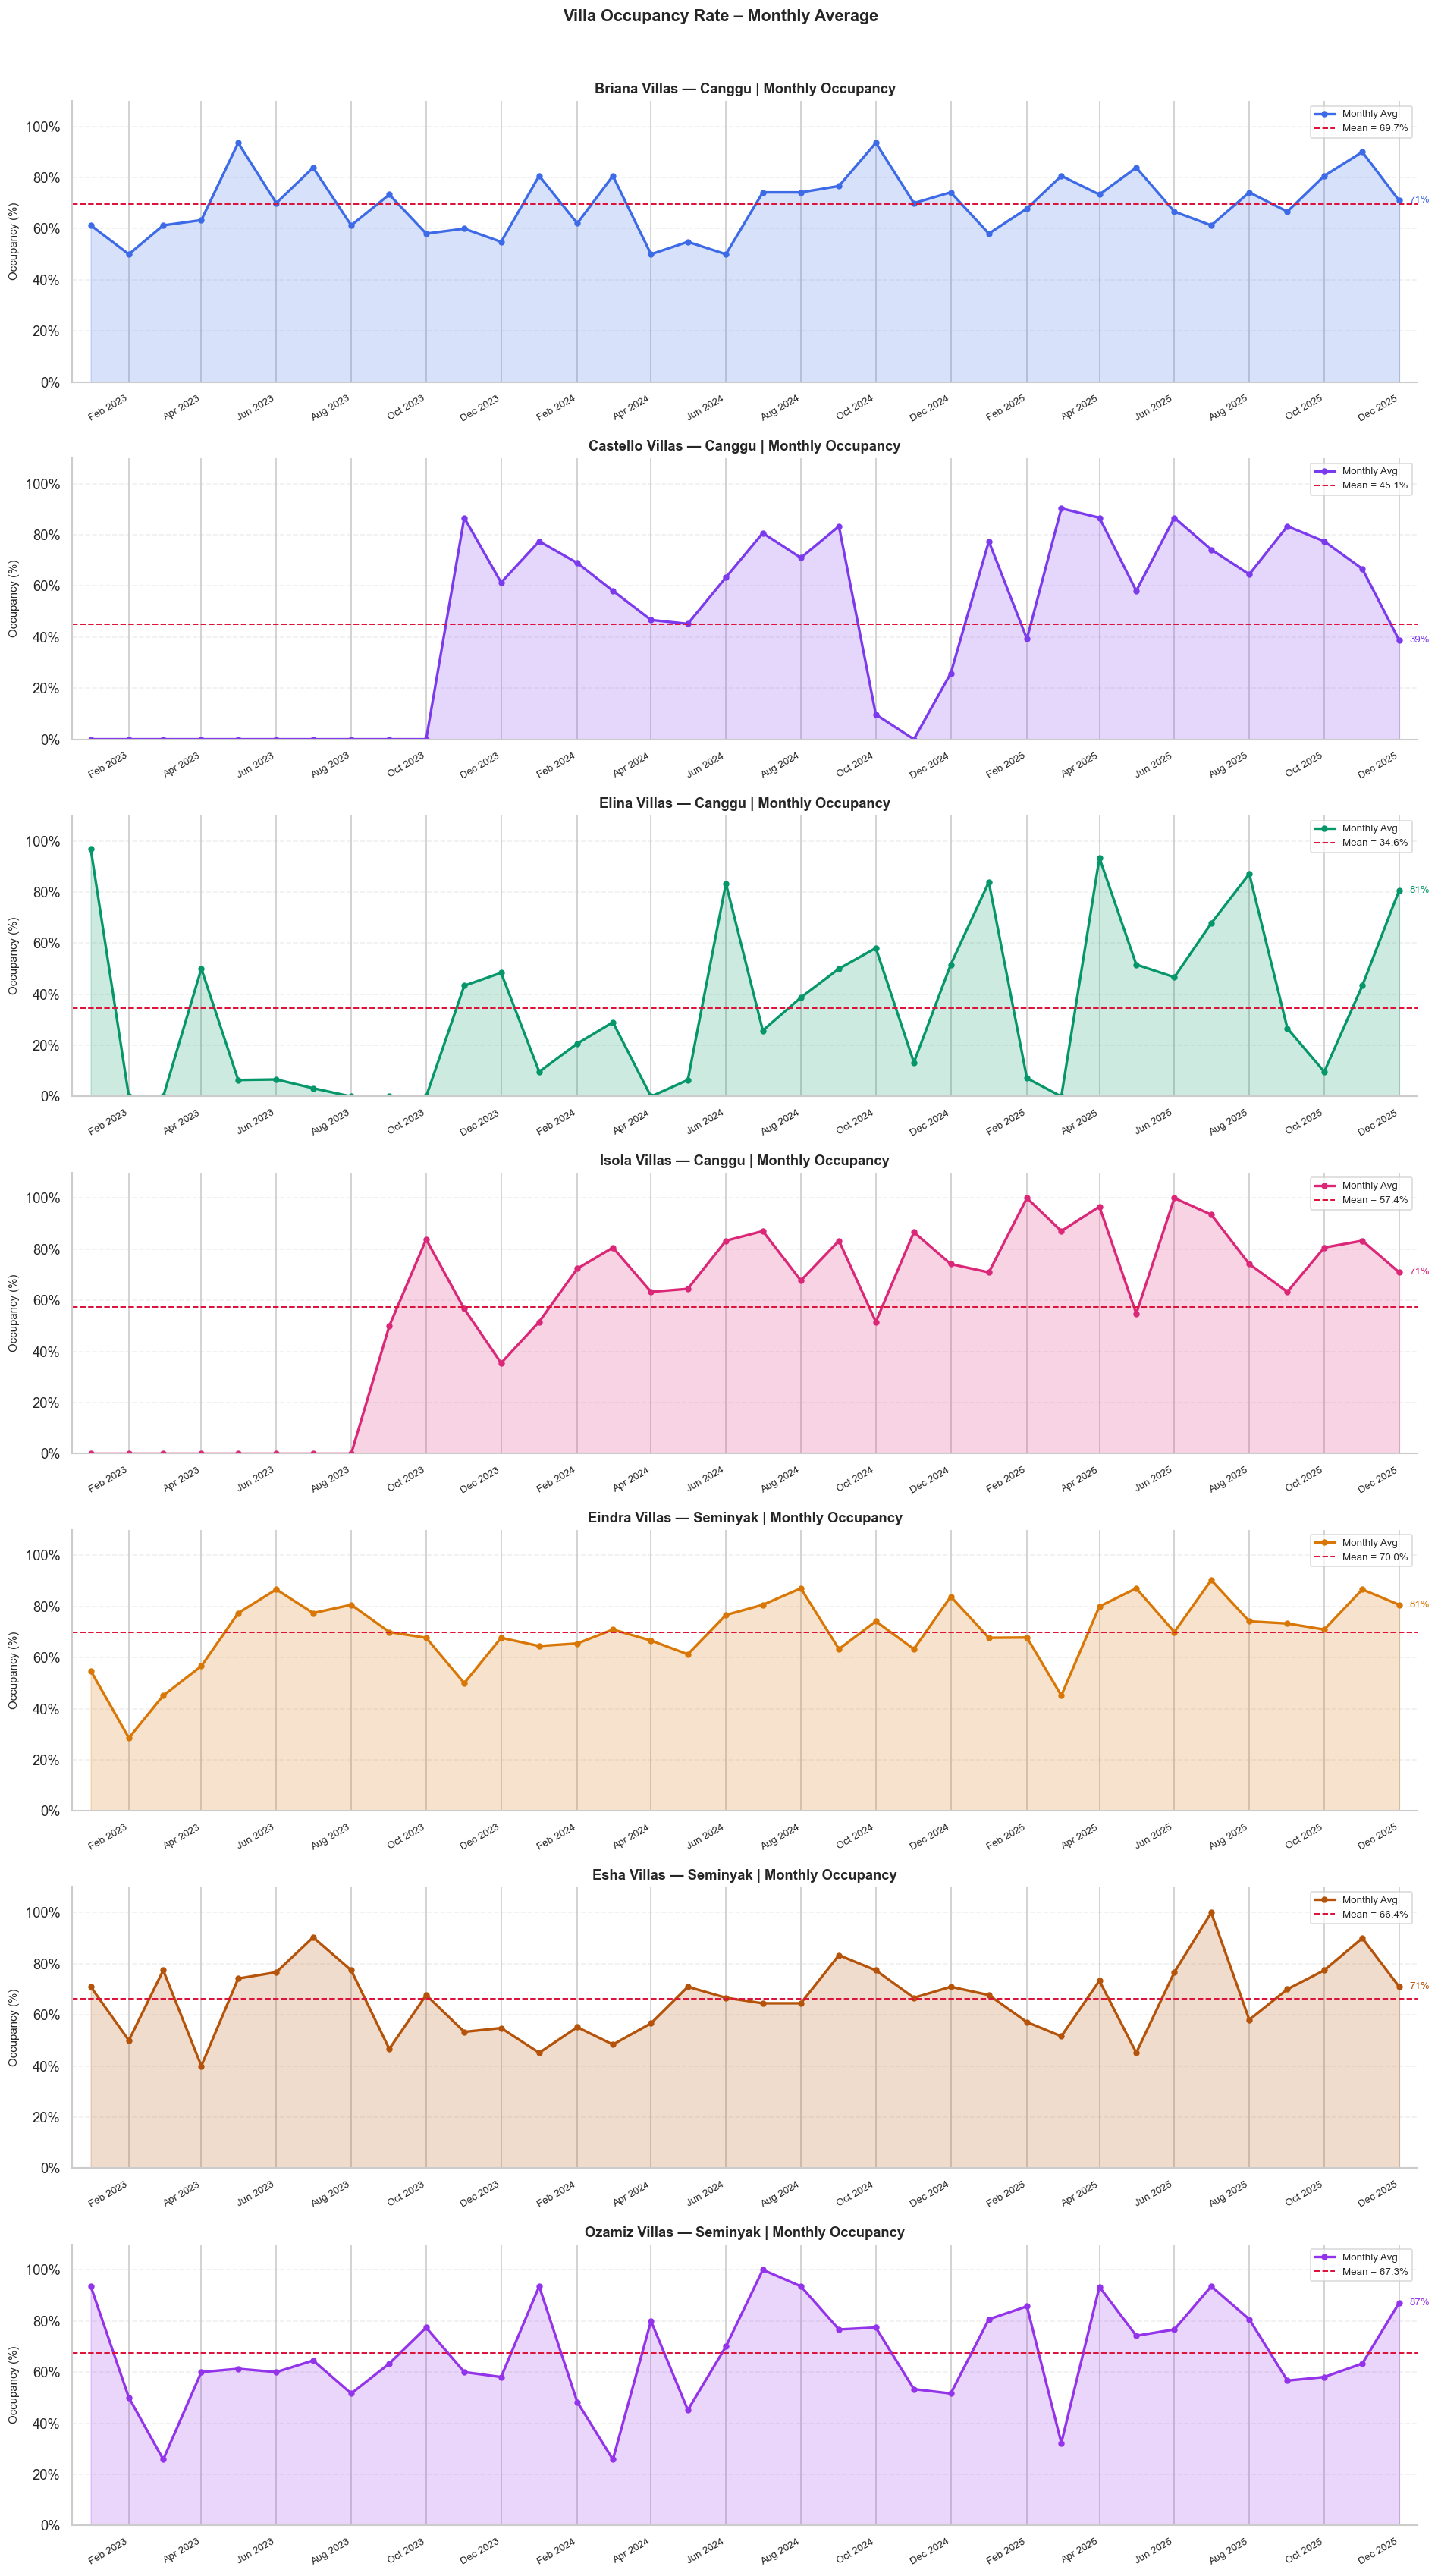

In [8]:
fig, axes = plt.subplots(len(clean_occ), 1, figsize=(16, 4 * len(clean_occ)))
if len(clean_occ) == 1:
    axes = [axes]

for idx, (villa, series) in enumerate(clean_occ.items()):
    ax       = axes[idx]
    config   = VILLA_CONFIG[villa]
    monthly  = series.resample('MS').mean()
    mean_val = series.mean()

    ax.fill_between(monthly.index, 0, monthly.values, alpha=0.20, color=config['color'])
    ax.plot(monthly.index, monthly.values, lw=2, color=config['color'],
            marker='o', markersize=4, label='Monthly Avg')
    ax.axhline(mean_val, color='crimson', ls='--', lw=1.2,
               label=f'Mean = {mean_val:.1f}%')

    ax.annotate(f"{monthly.values[-1]:.0f}%",
                xy=(monthly.index[-1], monthly.values[-1]),
                xytext=(8, 0), textcoords='offset points',
                fontsize=8, color=config['color'], va='center')

    ax.set_title(f"{villa.replace('_',' ').title()} — {config['area'].title()} | Monthly Occupancy",
                 fontweight='bold', fontsize=11, pad=6)
    ax.set_ylabel('Occupancy (%)', fontsize=9)
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.set_xlim(monthly.index.min() - pd.DateOffset(days=15),
                monthly.index.max() + pd.DateOffset(days=15))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3, ls='--')
    ax.spines[['top','right']].set_visible(False)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.7)

plt.suptitle('Villa Occupancy Rate – Monthly Average', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_occupancy_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Statistik Deskriptif

In [9]:
stats_data = []
for villa, series in clean_occ.items():
    config = VILLA_CONFIG[villa]
    stats_data.append({
        'Villa'     : villa.replace('_villas','').title(),
        'Area'      : config['area'].title(),
        'N'         : len(series),
        'Mean (%)'  : round(series.mean(), 2),
        'Std (%)'   : round(series.std(), 2),
        'Min (%)'   : round(series.min(), 2),
        'Max (%)'   : round(series.max(), 2),
        'Median (%)': round(series.median(), 2),
        'Start'     : series.index.min().strftime('%Y-%m-%d'),
        'End'       : series.index.max().strftime('%Y-%m-%d'),
    })

stats_df = pd.DataFrame(stats_data)
print('STATISTIK DESKRIPTIF OCCUPANCY (0–100%)')
print('=' * 90)
display(stats_df)

STATISTIK DESKRIPTIF OCCUPANCY (0–100%)


,Villa,Area,N,Mean (%),Std (%),Min (%),Max (%),Median (%),Start,End
0,Briana,Canggu,1096,69.71,45.97,0,100,100.00,2023-01-01,2025-12-31
1,Castello,Canggu,1096,45.07,49.78,0,100,0.00,2023-01-01,2025-12-31
2,Elina,Canggu,1096,34.58,47.58,0,100,0.00,2023-01-01,2025-12-31
3,Isola,Canggu,1096,57.39,49.47,0,100,100.00,2023-01-01,2025-12-31
4,Eindra,Seminyak,1096,69.98,45.85,0,100,100.00,2023-01-01,2025-12-31
5,Esha,Seminyak,1096,66.42,47.25,0,100,100.00,2023-01-01,2025-12-31
6,Ozamiz,Seminyak,1096,67.34,46.92,0,100,100.00,2023-01-01,2025-12-31


---
## 6. Uji Stasioneritas — Augmented Dickey-Fuller (ADF)
Sebelum fitting SARIMA, setiap series perlu diuji stasioneritas.  
- **p < 0.05** → stasioner (d=0 cukup)  
- **p ≥ 0.05** → tidak stasioner → perlu differencing (d=1)

UJI STASIONERITAS — AUGMENTED DICKEY-FULLER (α = 0.05)

 Villa     Area    N (bulan)  ADF Statistic\n(Level)  p-value\n(Level)  d p-value\n(diff1) p-value\n(diff2)
  Briana   Canggu     36              -1.57                 0.50       1        0.00                -      
Castello   Canggu     36              -2.66                 0.08       1        0.00                -      
   Elina   Canggu     36              -0.72                 0.84       1        0.00                -      
   Isola   Canggu     36              -2.35                 0.16       2        0.17             0.00      
  Eindra Seminyak     36              -3.77                 0.00       0           -                -      
    Esha Seminyak     36              -5.11                 0.00       0           -                -      
  Ozamiz Seminyak     36              -5.59                 0.00       0           -                -      

Penjelasan Hasil Uji ADF:
• 4 vila di kawasan Canggu tidak stasioner pada data 

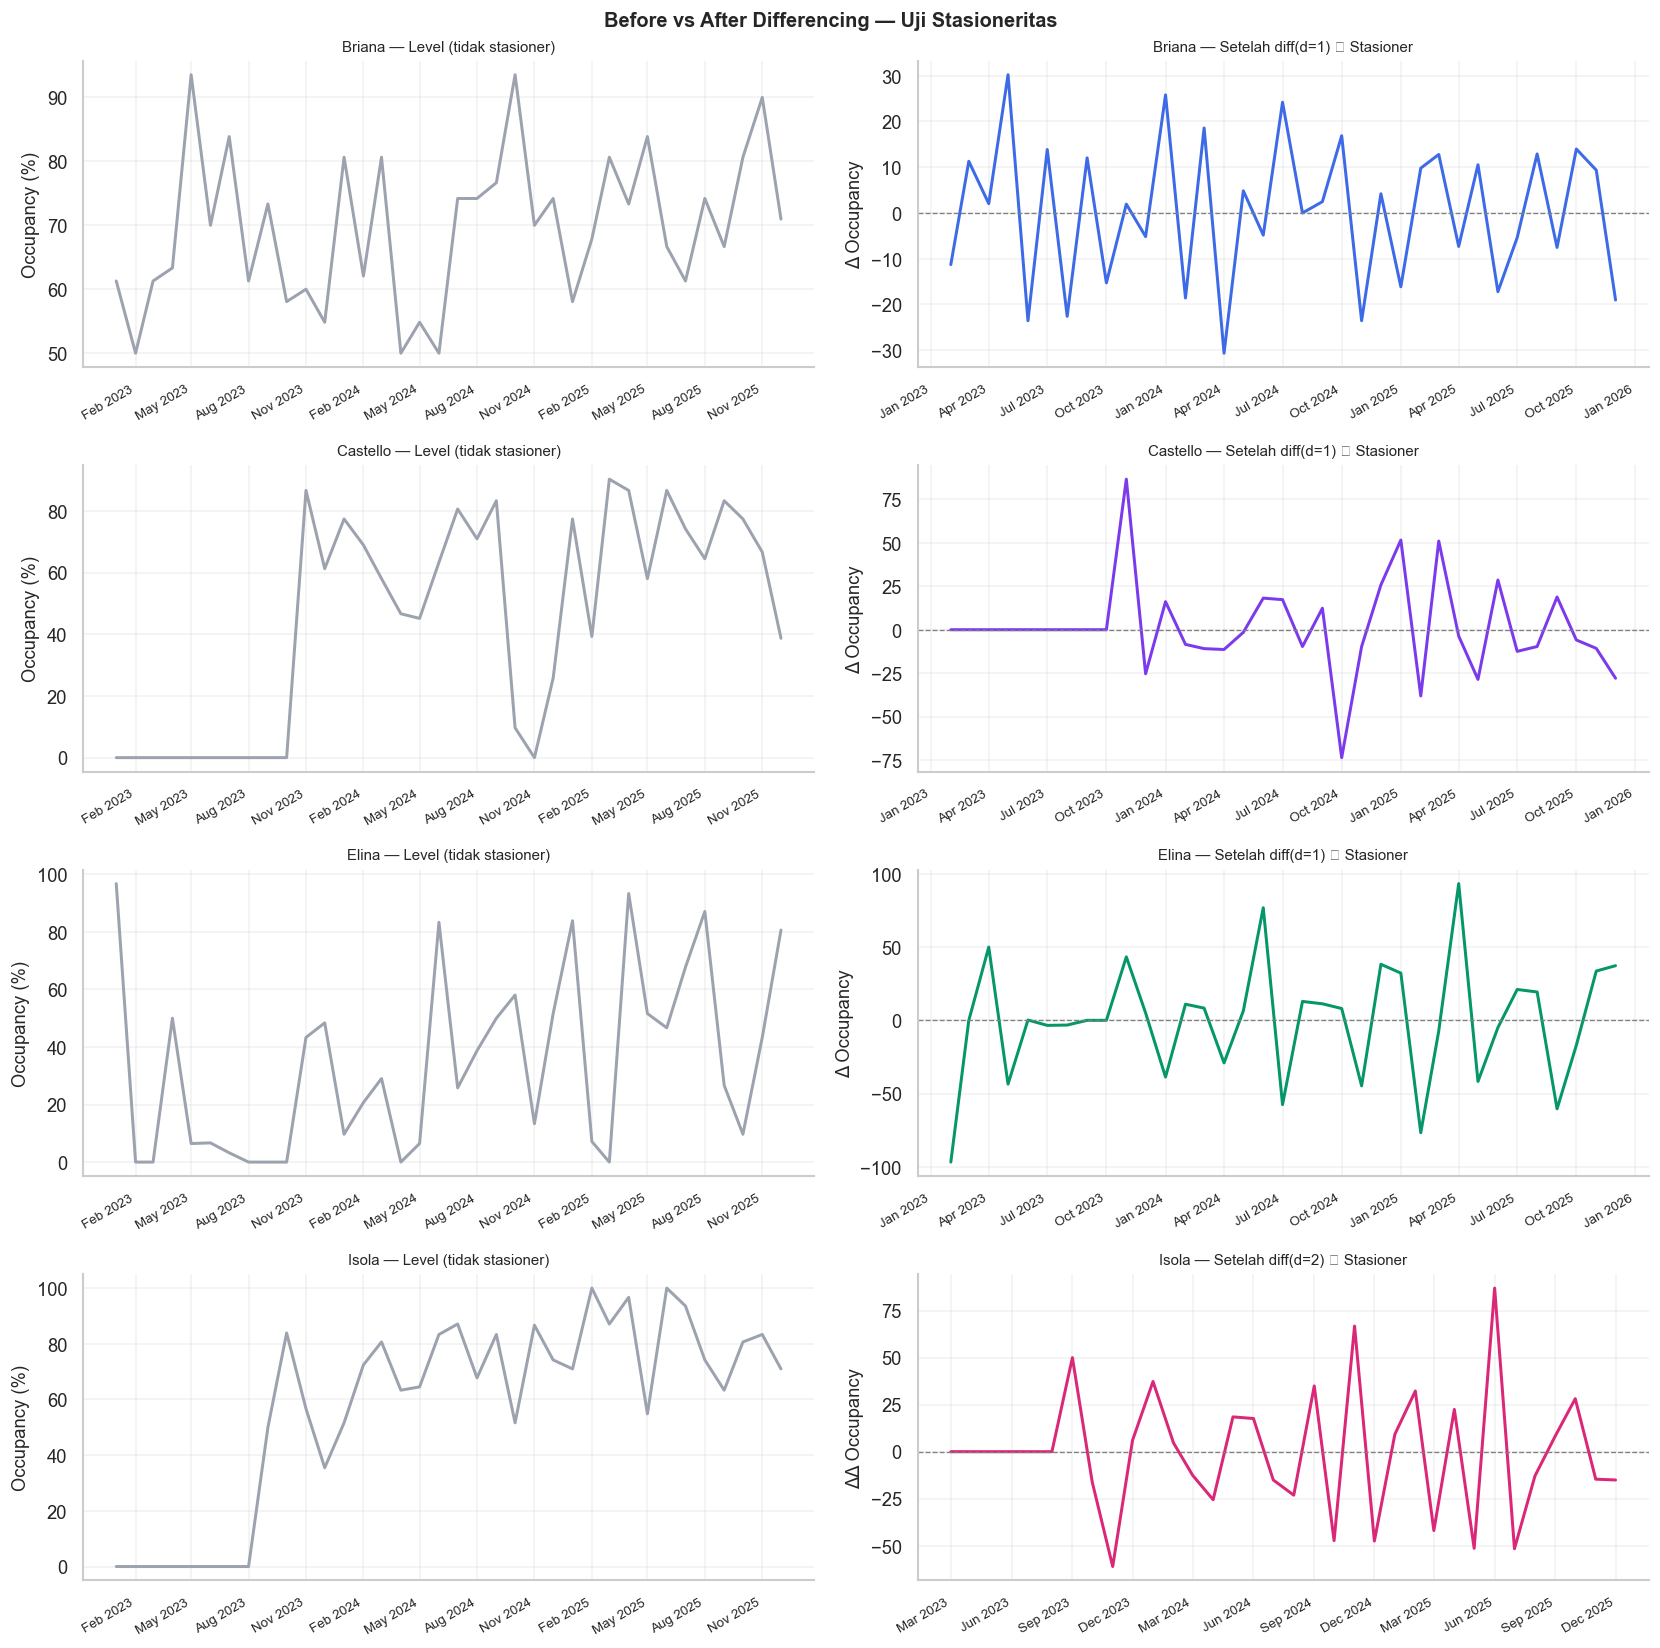

In [10]:
# ── 6. ADF TEST + AUTO-DIFFERENCING + VERIFIKASI
# Hasil: clean_occ_stationary = {villa: series siap pakai (sudah stasioner)}
#        villa_d = {villa: d yang dipakai}

from statsmodels.tsa.stattools import adfuller
import pandas as pd

def adf_check(series):
    """Jalankan ADF Test"""
    result = adfuller(series.dropna(), autolag='AIC')
    return round(result[0], 4), round(result[1], 4)  # adf_stat, p_value

# ── Persiapan hasil
adf_results = []
clean_occ_stationary = {}
villa_d = {}

print("UJI STASIONERITAS — AUGMENTED DICKEY-FULLER (α = 0.05)\n")
print("=" * 100)

for villa, series in clean_occ.items():
    monthly = series.resample('MS').mean().dropna()
    title = villa.replace('_villas', '').title()
    area = VILLA_CONFIG[villa]['area'].title()

    # === Level (d=0) ===
    adf0, p0 = adf_check(monthly)

    if p0 < 0.05:
        d_used = 0
        series_final = monthly
        p1 = None
        p2 = None
    else:
        # === First Difference (d=1) ===
        diff1 = monthly.diff().dropna()
        adf1, p1 = adf_check(diff1)

        if p1 < 0.05:
            d_used = 1
            series_final = diff1
            p2 = None
        else:
            # === Second Difference (d=2) ===
            diff2 = monthly.diff().diff().dropna()
            adf2, p2 = adf_check(diff2)
            d_used = 2
            series_final = diff2

    clean_occ_stationary[villa] = series_final
    villa_d[villa] = d_used

    adf_results.append({
        'Villa'           : title,
        'Area'            : area,
        'N (bulan)'       : len(monthly),
        'ADF Statistic\n(Level)' : adf0,
        'p-value\n(Level)' : p0,
        'd'               : d_used,
        'p-value\n(diff1)' : p1 if p1 is not None else '-',
        'p-value\n(diff2)' : p2 if p2 is not None else '-',
    })

# ── Buat DataFrame dan tampilkan
adf_df = pd.DataFrame(adf_results)

# Tampilkan tabel yang rapi
print(adf_df.to_string(index=False, justify='center'))

# ── Penjelasan otomatis (siap copy ke laporan)
print("\n" + "="*100)
print("Penjelasan Hasil Uji ADF:")

non_stationary = [v.replace('_villas','').title() for v, d in villa_d.items() if d > 0]

if non_stationary:
    print(f"• {len(non_stationary)} vila di kawasan Canggu tidak stasioner pada data level (p-value > 0.05).")
    print("  Differencing diperlukan untuk menghilangkan tren:")
    for v in non_stationary:
        d = villa_d[v.lower() + '_villas']
        print(f"   - {v:12} → d = {d}")
else:
    print("• Semua vila sudah stasioner pada tingkat data asli.")

print("\n• Vila di kawasan Seminyak (Eindra, Esha, Ozamiz) sudah stasioner sejak awal (p-value = 0.000).")
print("  Hal ini menunjukkan pola hunian yang lebih stabil dibandingkan vila di Canggu.")

print(f"\nvilla_d = {villa_d}")

# ── Langkah 2: Plot level vs stasioner (side-by-side) untuk villa yg di-diff
villa_diffed = [v for v, d in villa_d.items() if d > 0]

if villa_diffed:
    fig, axes = plt.subplots(len(villa_diffed), 2,
                             figsize=(14, 3.5 * len(villa_diffed)))
    if len(villa_diffed) == 1:
        axes = [axes]

    for ax_row, villa in zip(axes, villa_diffed):
        color   = VILLA_CONFIG[villa]['color']
        title   = villa.replace('_villas','').title()
        monthly = clean_occ[villa].resample('MS').mean().dropna()
        stat_s  = clean_occ_stationary[villa]
        d       = villa_d[villa]

        # Kiri: level (tidak stasioner)
        ax_row[0].plot(monthly.index, monthly.values, color='#9ca3af', lw=1.8)
        ax_row[0].set_title(f'{title} — Level (tidak stasioner)', fontsize=9)
        ax_row[0].set_ylabel('Occupancy (%)')

        # Kanan: setelah differencing (stasioner)
        ax_row[1].plot(stat_s.index, stat_s.values, color=color, lw=1.8)
        ax_row[1].axhline(0, color='gray', ls='--', lw=0.8)
        ax_row[1].set_title(f'{title} — Setelah diff(d={d}) ✅ Stasioner', fontsize=9)
        ax_row[1].set_ylabel(f'Δ{"Δ" if d==2 else ""} Occupancy')

        for ax in ax_row:
            ax.grid(alpha=0.25)
            ax.spines[['top','right']].set_visible(False)
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30,
                     ha='right', fontsize=8)

    plt.suptitle('Before vs After Differencing — Uji Stasioneritas',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('adf_differencing.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 7. Seasonal Decomposition (Additive)
Pisahkan komponen **Trend**, **Seasonal**, dan **Residual** untuk memahami pola musiman.

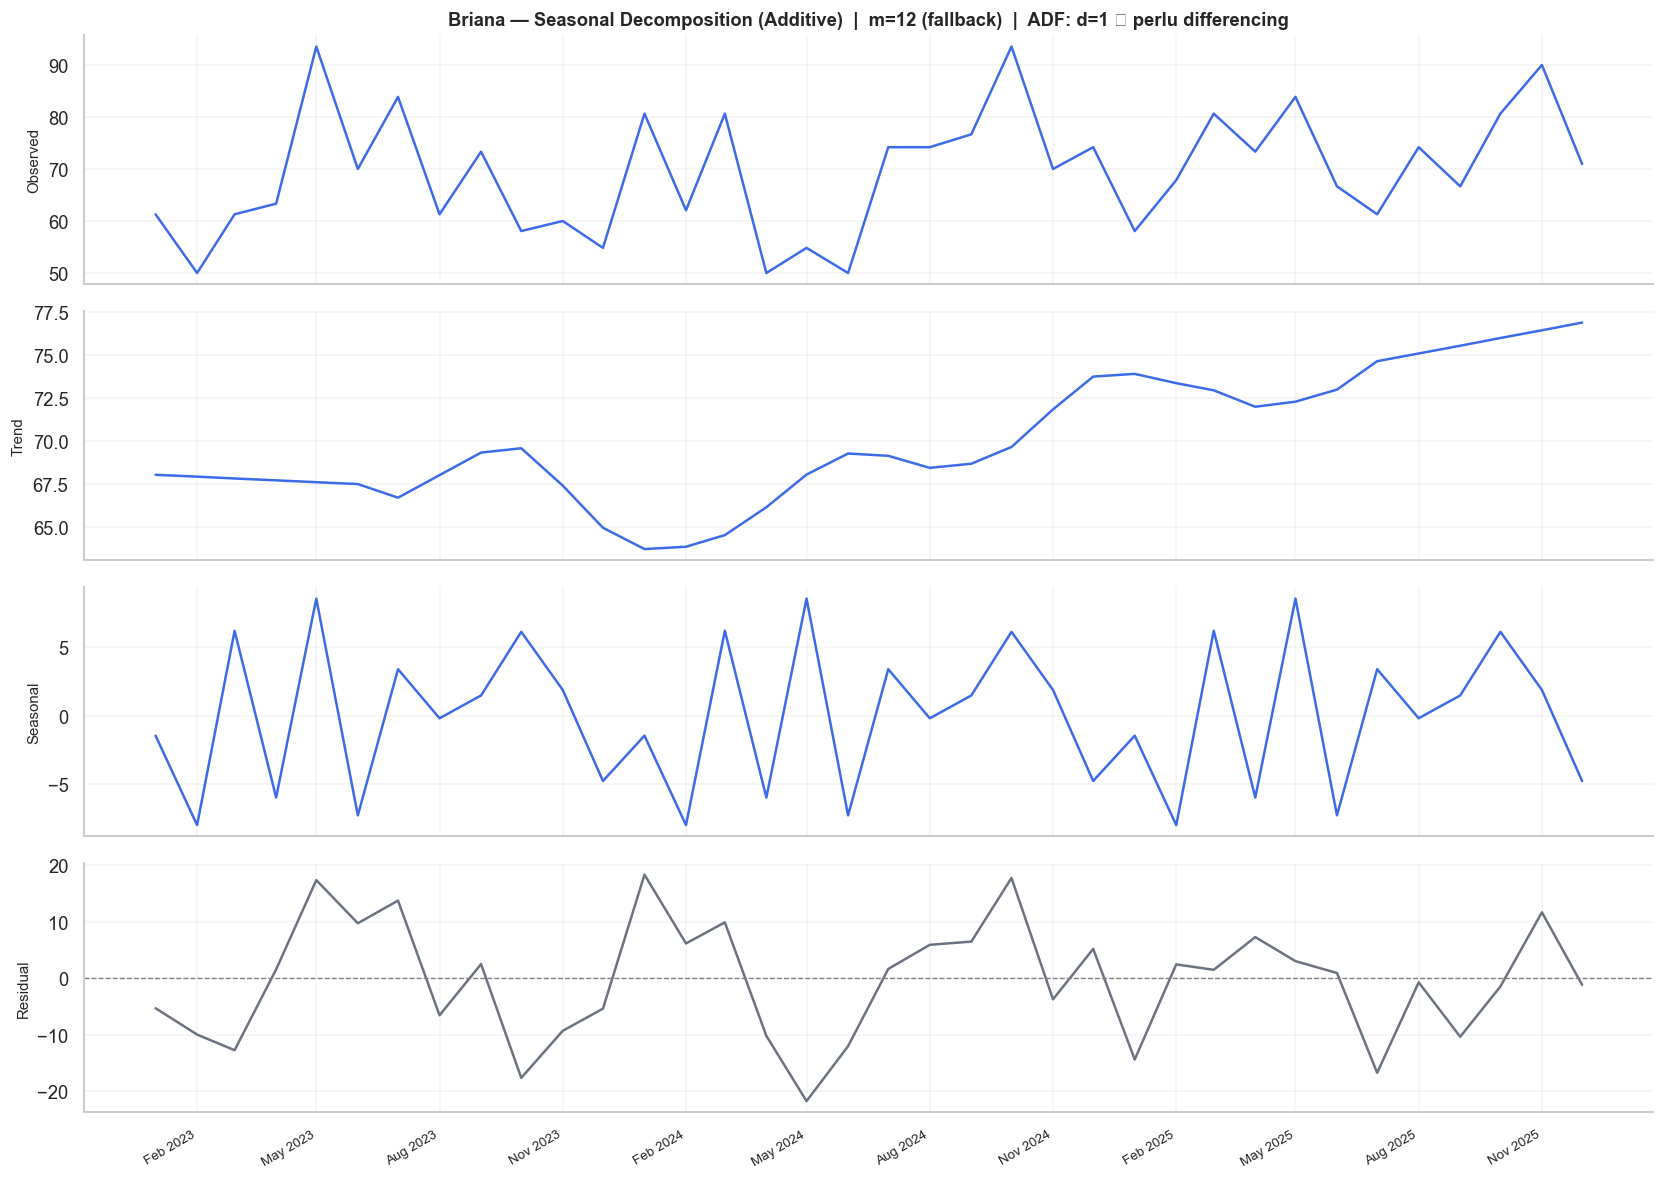

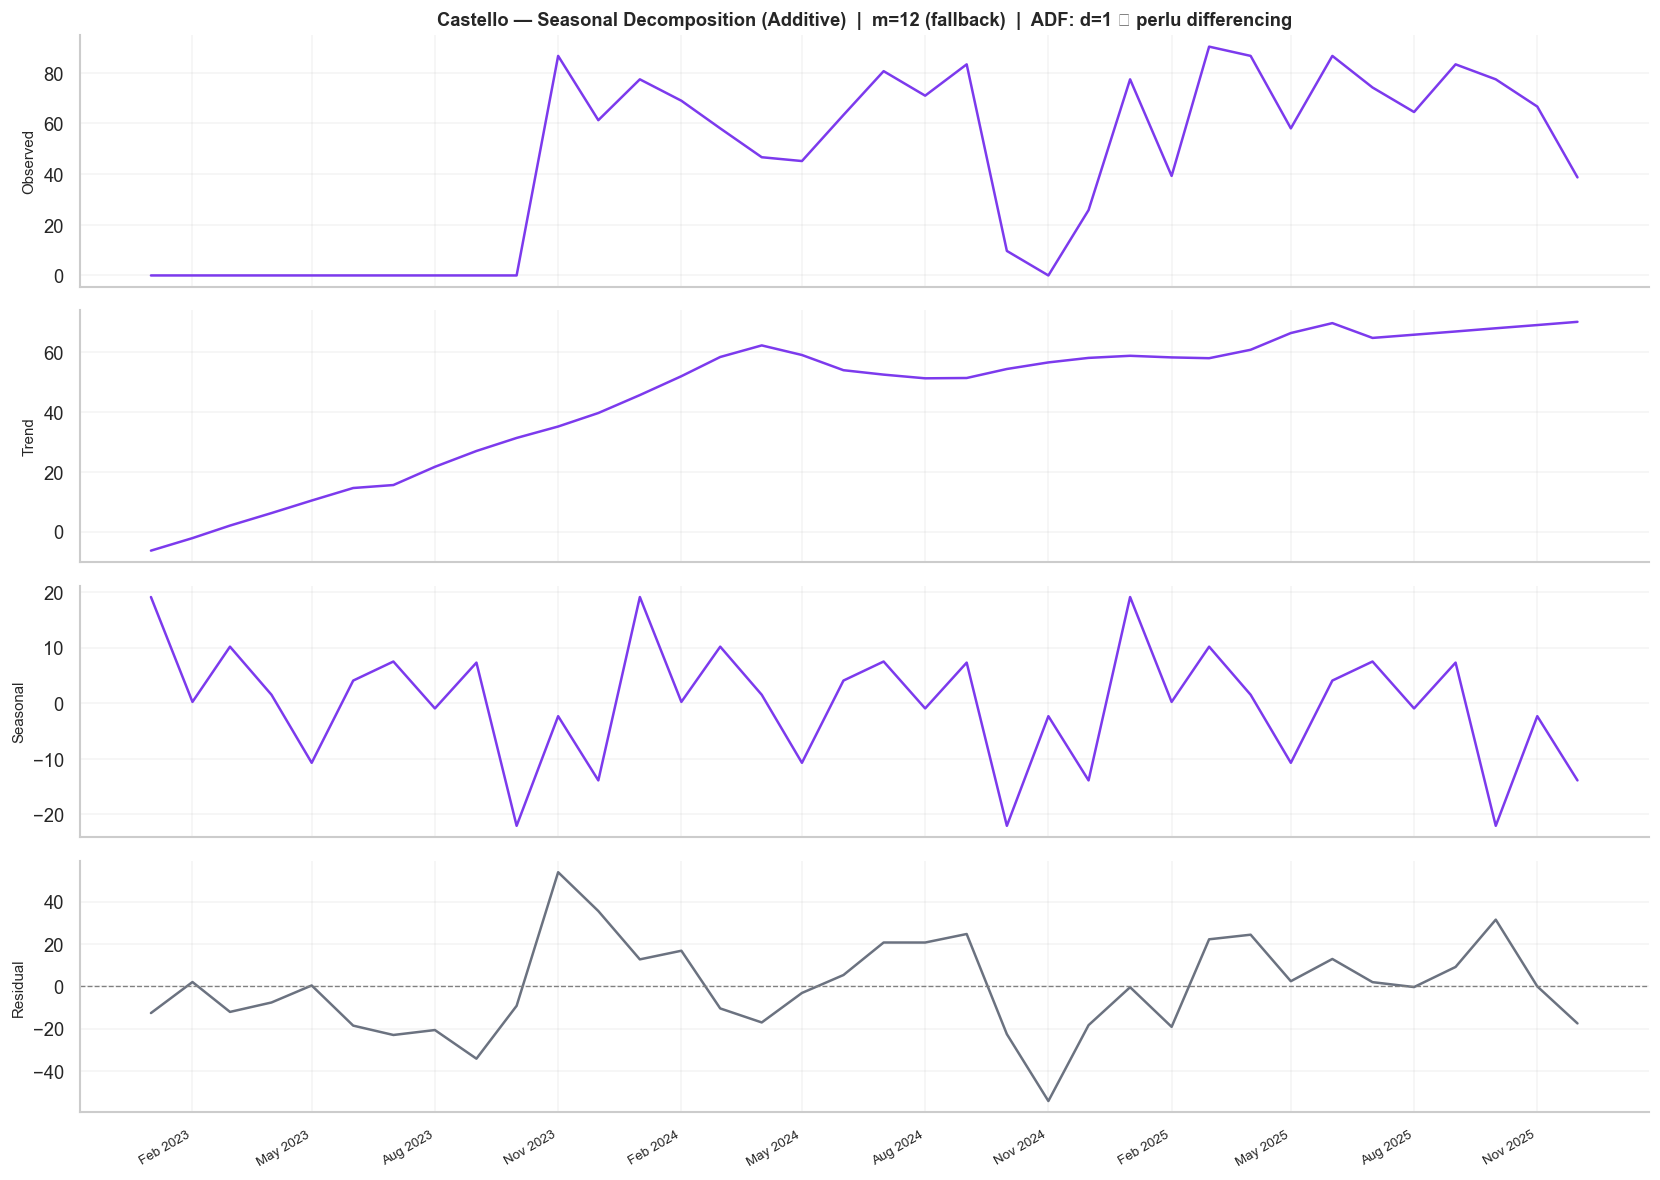

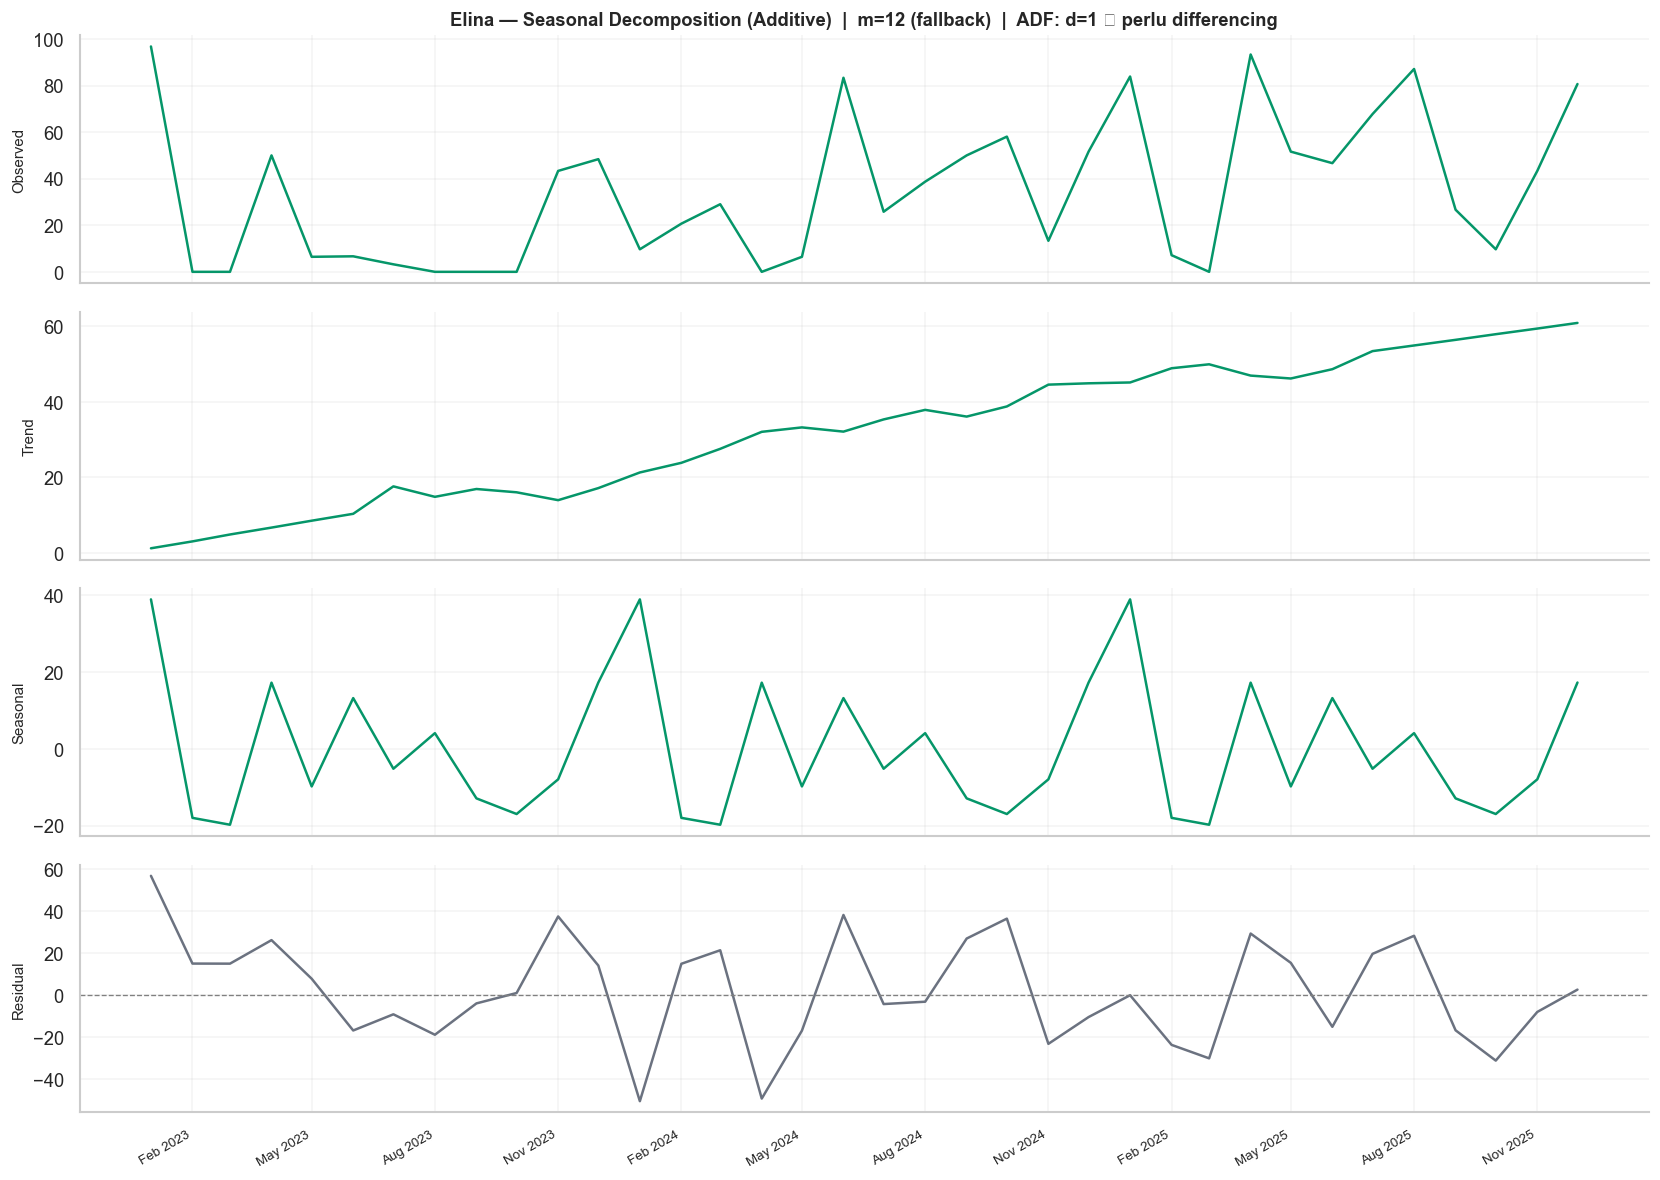

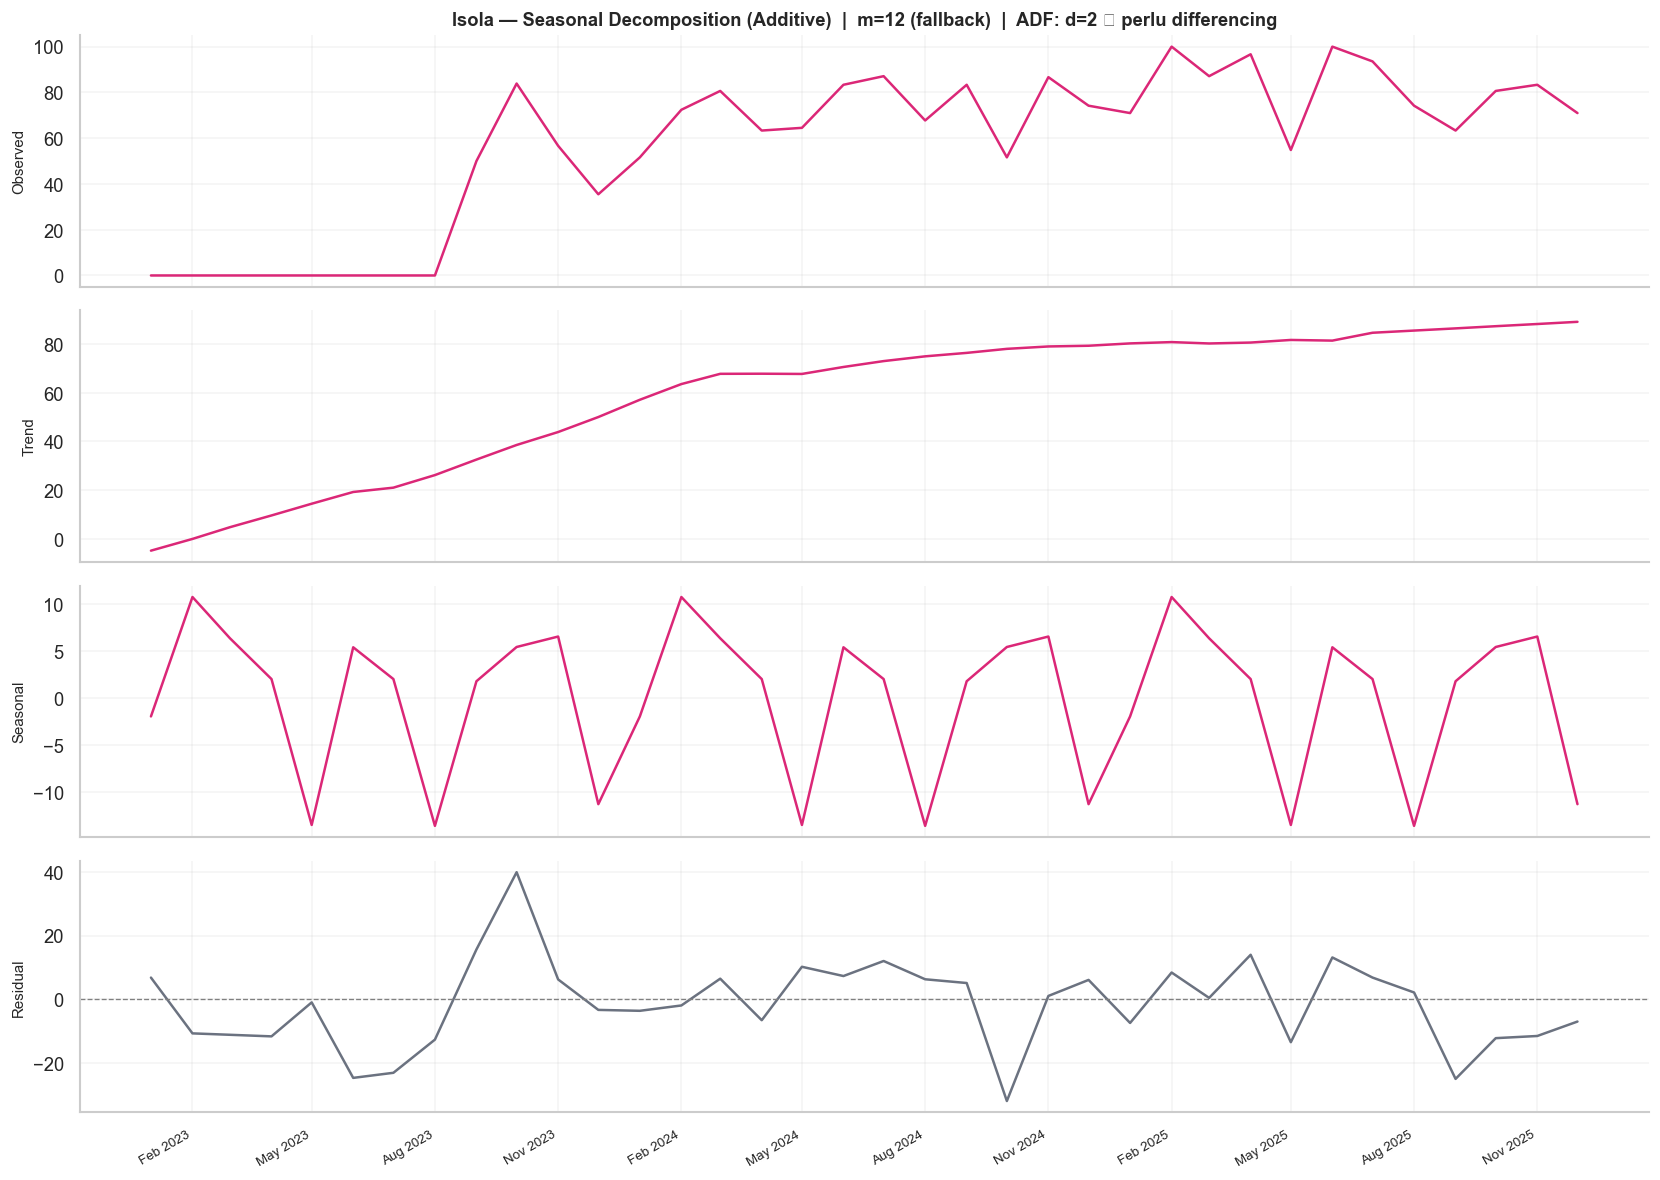

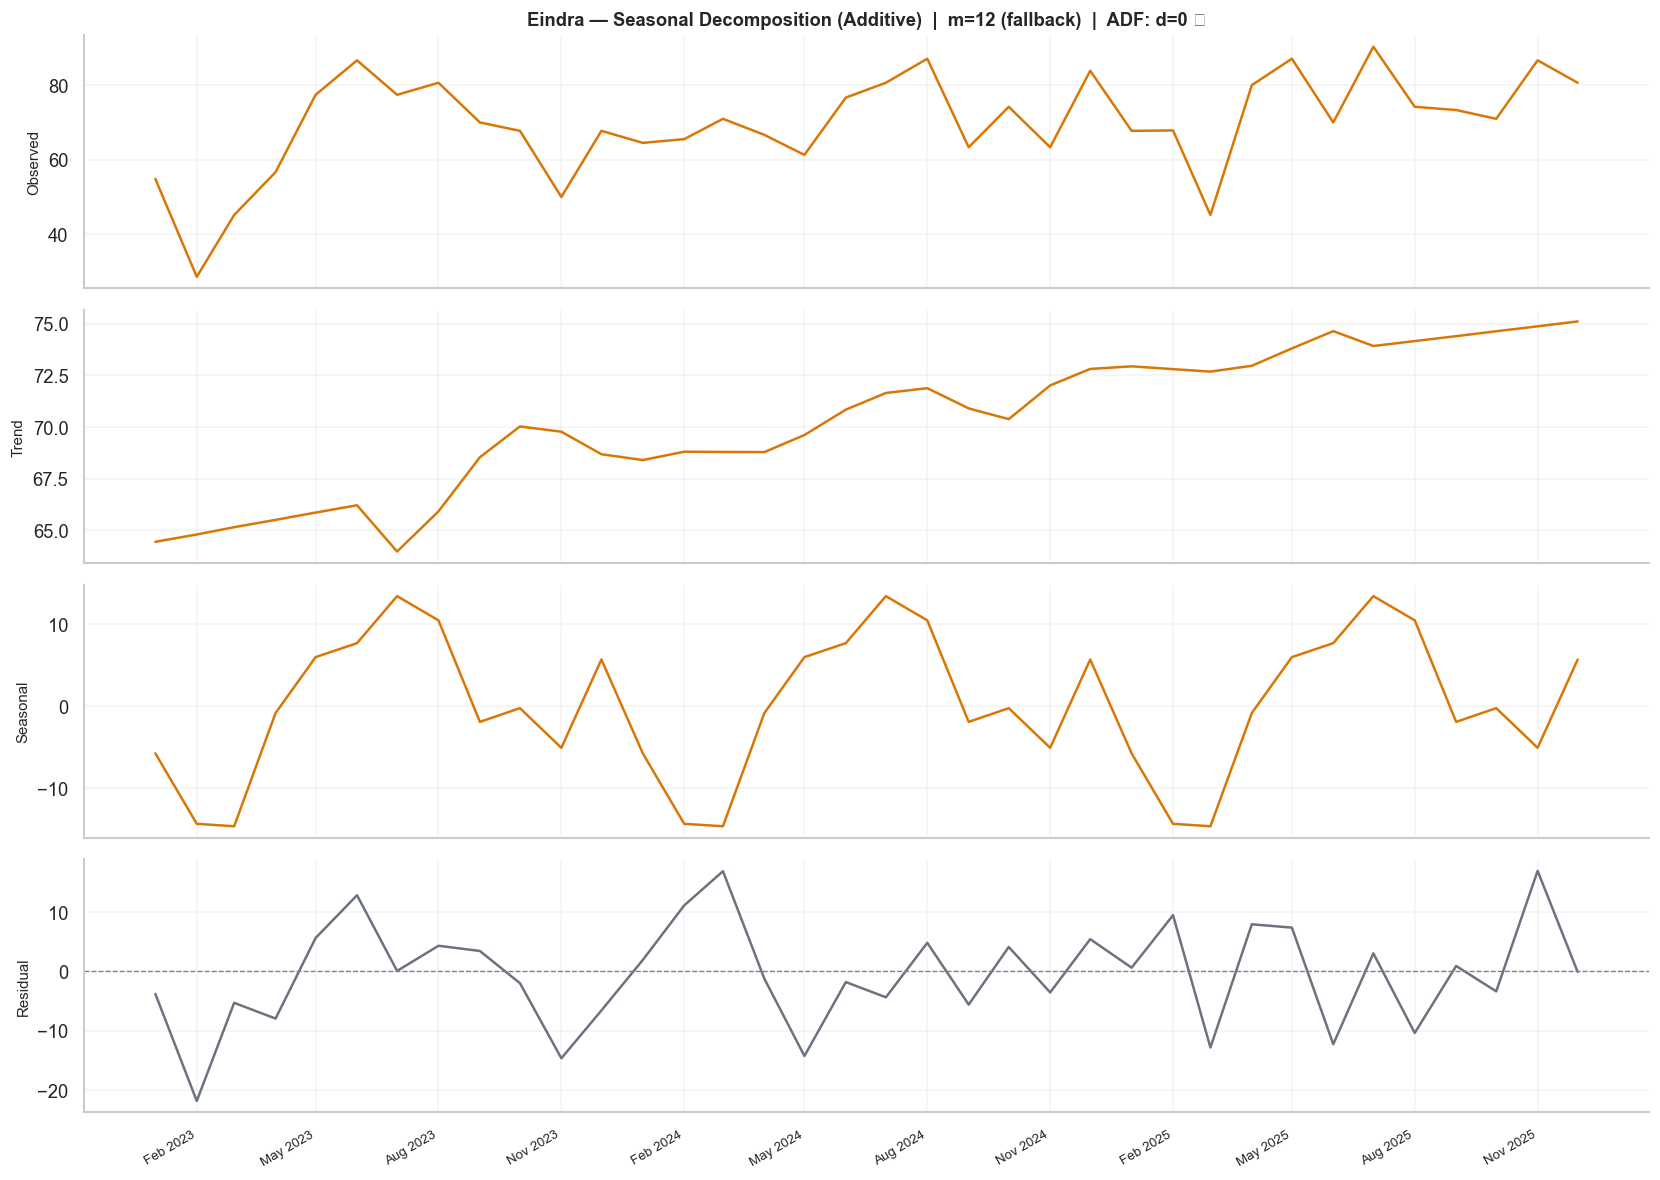

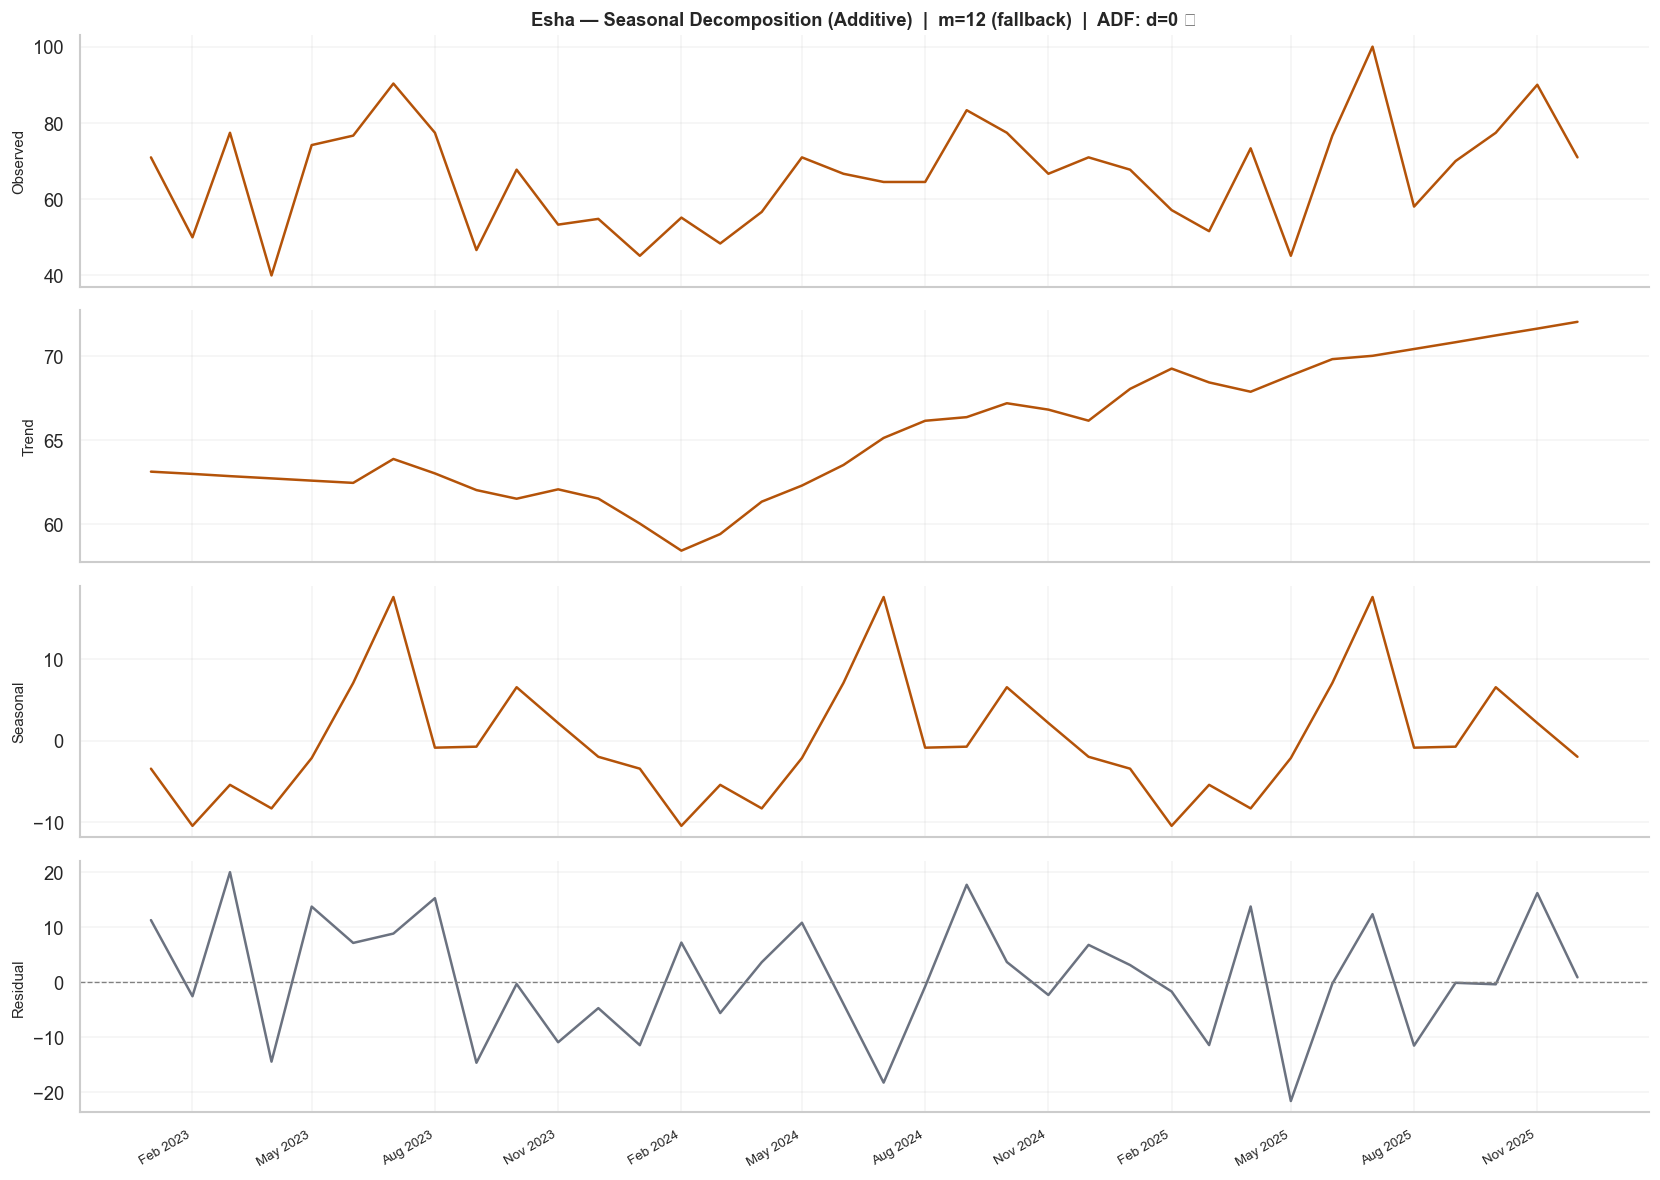

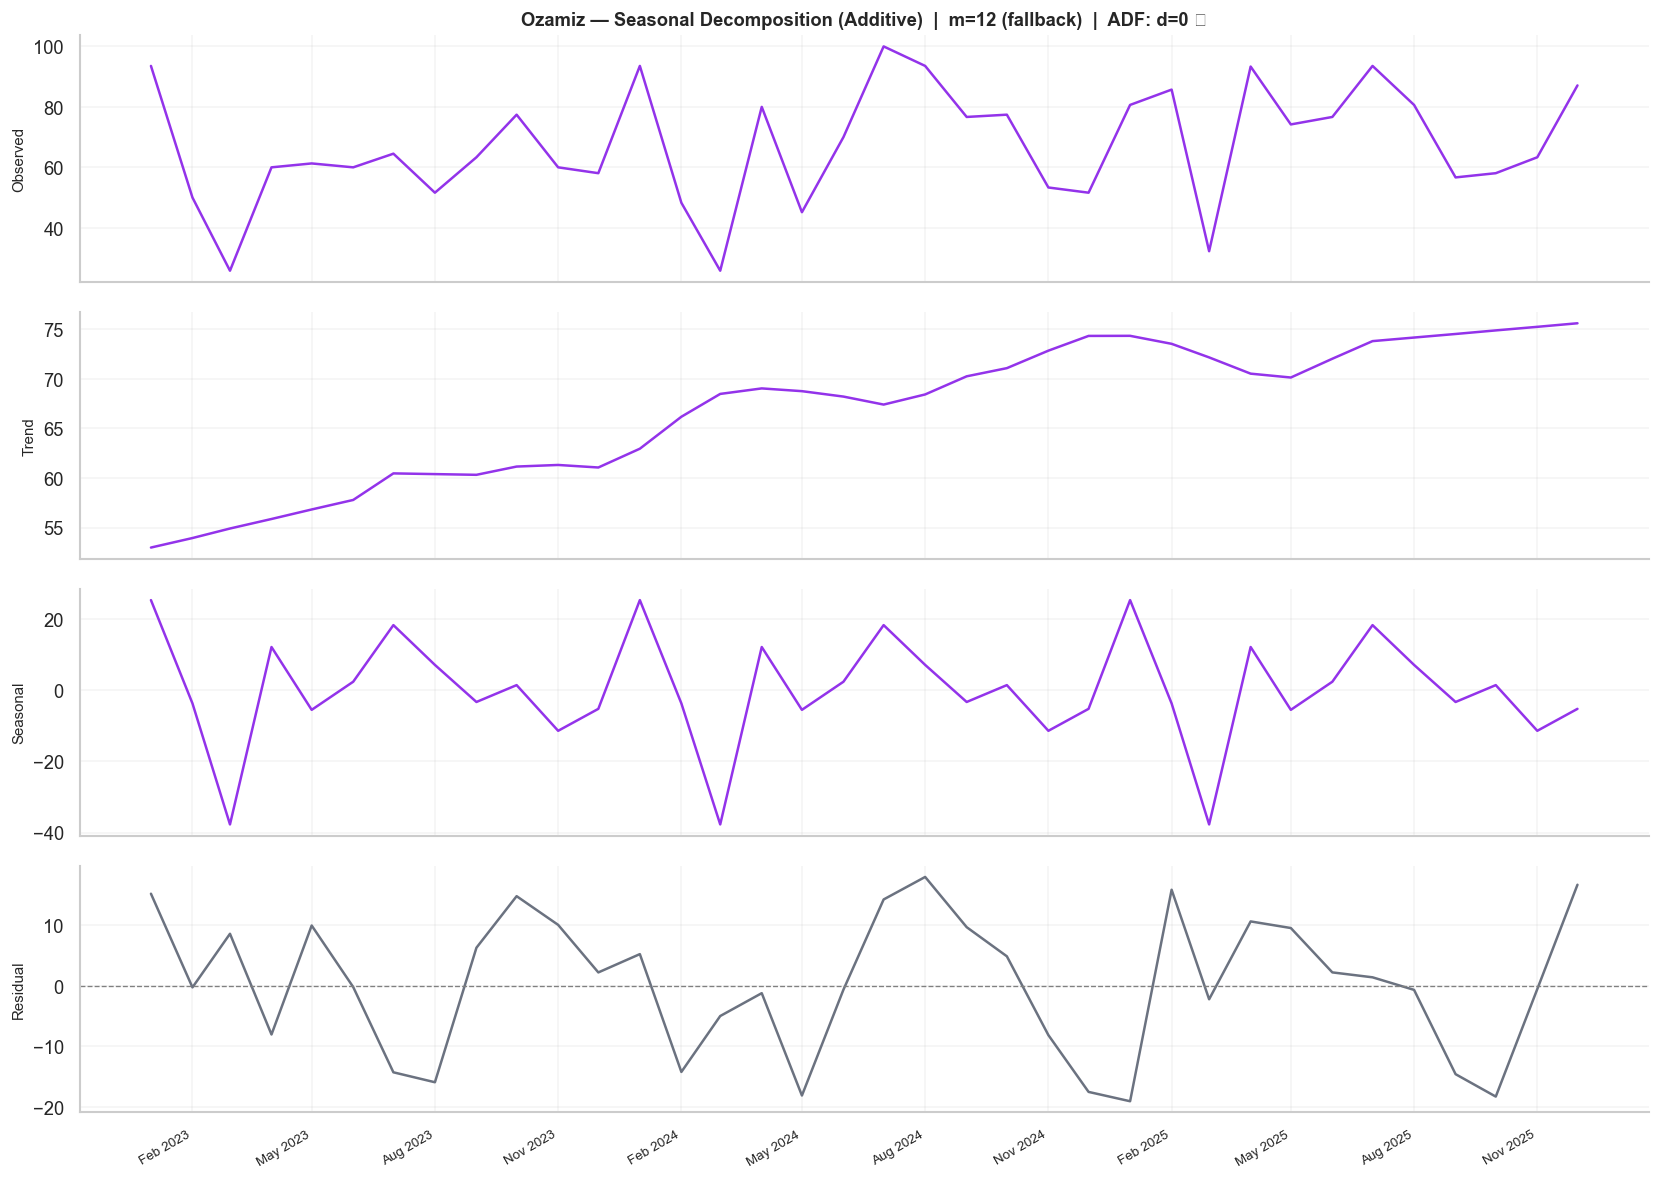

✅ Seasonal decomposition selesai.


In [11]:
# ── 7. SEASONAL DECOMPOSITION — additive, period dari detect_m()
# ℹ️  Selalu pakai data LEVEL (original), bukan data yang sudah di-differencing.
#    Tujuan decomposisi adalah eksplorasi visual trend & musiman di data asli.
#    Info d dari ADF (villa_d) dan m dari periodogram ditampilkan di judul.
#
# FIX-A: period tidak lagi hardcode 12 — diambil dari villa_m per villa.
#         Jika cell 7b belum dijalankan, fallback ke 12.

for villa, series in clean_occ.items():          # ← tetap clean_occ, bukan clean_occ_stationary
    monthly = series.resample('MS').mean().dropna()
    if len(monthly) < 24:
        print(f'⚠️  [{villa}] < 24 bulan → skip decomposisi.')
        continue

    # FIX-A: ambil m dari deteksi periodogram, fallback 12
    m_villa = villa_m.get(villa, 12) if 'villa_m' in dir() else 12

    decomp = seasonal_decompose(monthly, model='additive', period=m_villa,
                                extrapolate_trend='freq')
    color  = VILLA_CONFIG[villa]['color']
    title  = villa.replace('_villas','').title()
    d_info = villa_d.get(villa, 0)               # ← ambil d dari hasil ADF (info saja)

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    components = [
        (decomp.observed, 'Observed'),
        (decomp.trend,    'Trend'),
        (decomp.seasonal, 'Seasonal'),
        (decomp.resid,    'Residual'),
    ]
    for ax, (comp, label) in zip(axes, components):
        ax.plot(monthly.index, comp,
                color=color if label != 'Residual' else '#6b7280', lw=1.5)
        if label == 'Residual':
            ax.axhline(0, color='gray', ls='--', lw=0.8)
        ax.set_ylabel(label, fontsize=9)
        ax.grid(alpha=0.2)
        ax.spines[['top','right']].set_visible(False)

    # ── Judul: tampilkan info d dari ADF + m dari periodogram
    d_note = f'  |  ADF: d={d_info} {"✅" if d_info == 0 else "🔄 perlu differencing"}'
    m_src  = 'periodogram' if ('villa_m' in dir() and villa in villa_m) else 'fallback'
    m_note = f'  |  m={m_villa} ({m_src})'
    axes[0].set_title(
        f'{title} — Seasonal Decomposition (Additive){m_note}{d_note}',
        fontweight='bold', fontsize=11
    )

    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'decomp_{villa}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('✅ Seasonal decomposition selesai.')


---
## 7b. Deteksi Periode Dominan (m) — Periodogram + ACF
Menentukan `m` secara **otomatis dari data** (bukan asumsi hardcode).  
Pipeline: **Periodogram (FFT)** → ambil periode dengan power tertinggi → konfirmasi dengan **ACF spike** → guard 4 ≤ m ≤ N/2 → fallback m=12 jika gagal.  
Output: `villa_m` (dict) → dipakai oleh Cell 7 (decomposisi) dan Cell 9 (auto_arima).
---

DETEKSI PERIODE DOMINAN (m) — PERIODOGRAM + ACF
  [Briana              ]  n=36  pgram=7  acf_spike=None  → m=7 (periodogram)
  [Castello            ]  n=36  pgram=18  acf_spike=None  → m=18 (periodogram)
  [Elina               ]  n=36  pgram=4  acf_spike=7  → m=4 (periodogram)
  [Isola               ]  n=36  pgram=18  acf_spike=4  → m=18 (periodogram)
  [Eindra              ]  n=36  pgram=12  acf_spike=None  → m=12 (periodogram)
  [Esha                ]  n=36  pgram=12  acf_spike=None  → m=12 (periodogram)
  [Ozamiz              ]  n=36  pgram=6  acf_spike=12  → m=6 (periodogram)



,Villa,Area,N (bln),m terpilih,Metode,ACF spike lag,Status
0,Briana,Canggu,36,7,periodogram,-,✅ Terdeteksi dari data
1,Castello,Canggu,36,18,periodogram,-,✅ Terdeteksi dari data
2,Elina,Canggu,36,4,periodogram,7,✅ Terdeteksi dari data
3,Isola,Canggu,36,18,periodogram,4,✅ Terdeteksi dari data
4,Eindra,Seminyak,36,12,periodogram,-,✅ Terdeteksi dari data
5,Esha,Seminyak,36,12,periodogram,-,✅ Terdeteksi dari data
6,Ozamiz,Seminyak,36,6,periodogram,12,✅ Terdeteksi dari data



villa_m = {'briana_villas': 7, 'castello_villas': 18, 'elina_villas': 4, 'isola_villas': 18, 'eindra_villas': 12, 'esha_villas': 12, 'ozamiz_villas': 6}


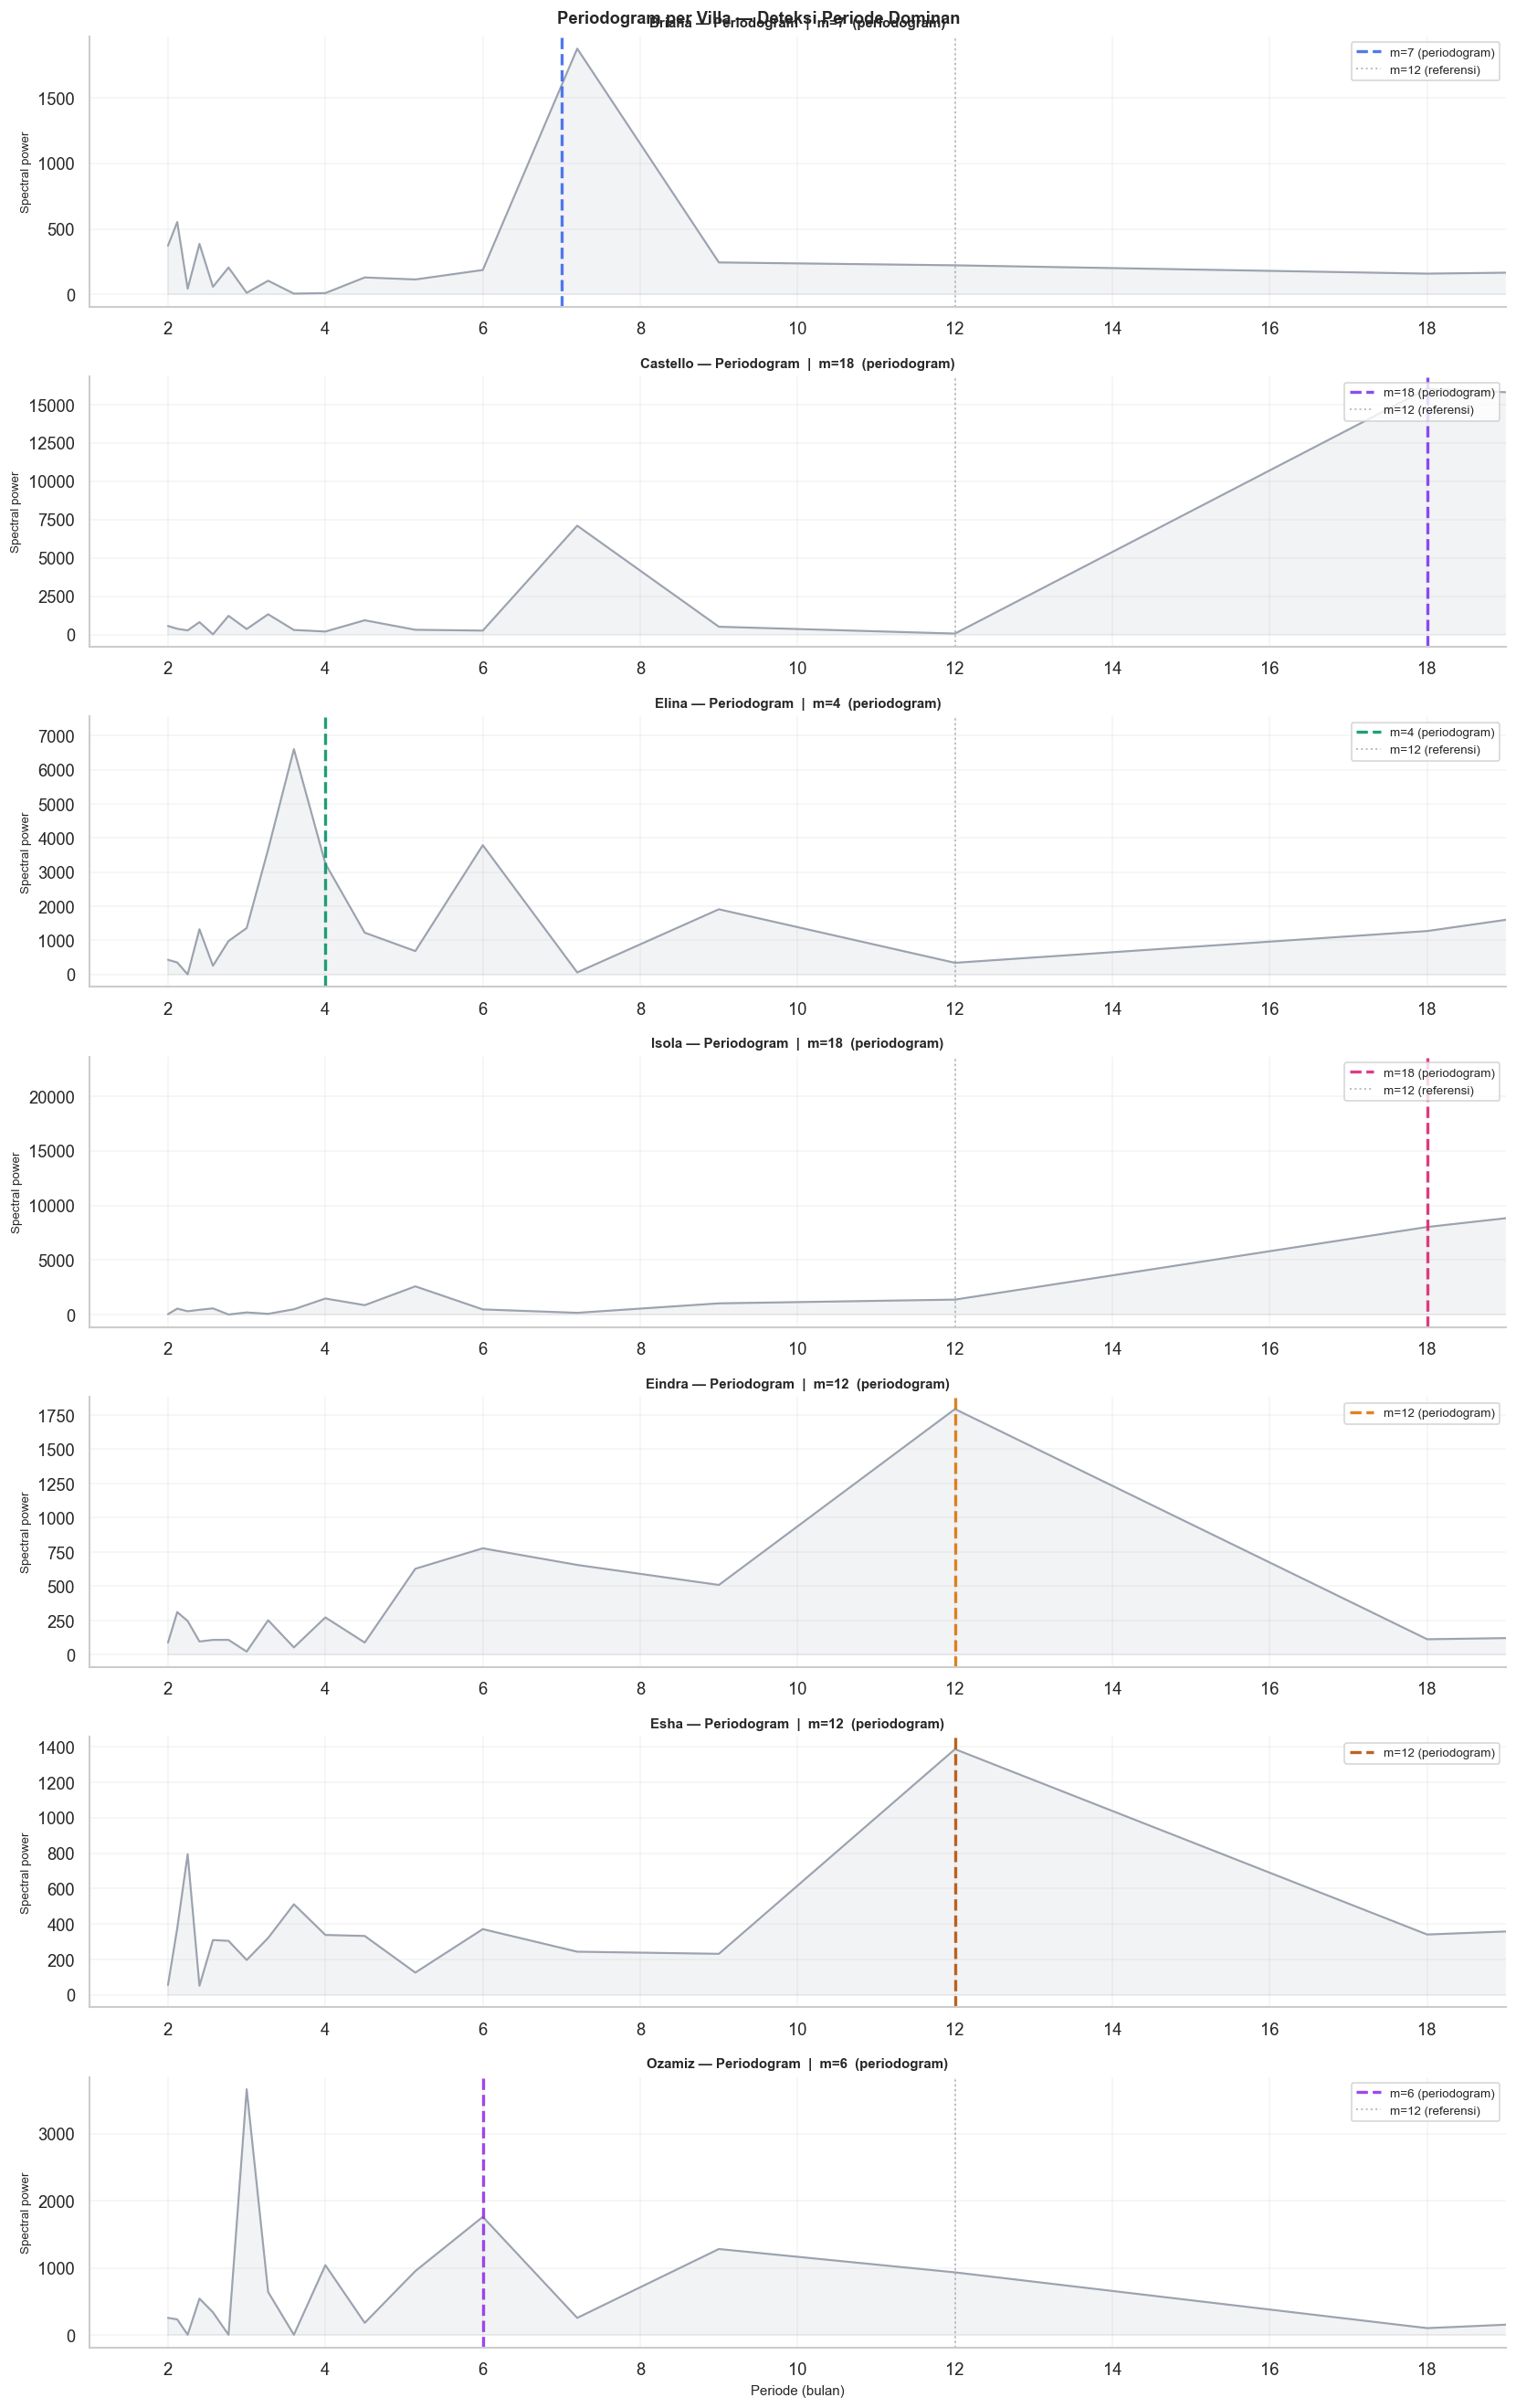

✅ Deteksi m selesai. villa_m tersimpan → dipakai Cell 7 & Cell 9.


In [12]:
# ── 7b. DETEKSI PERIODE DOMINAN (m) — Periodogram + ACF
#
# Pipeline per villa:
#   1. Periodogram (FFT) → cari periode dengan power tertinggi di data
#   2. ACF             → konfirmasi: apakah lag m memang spike signifikan?
#   3. Guard           → m hanya valid jika 4 ≤ m ≤ N/MIN_CYCLES
#                        (cukup data untuk minimal MIN_CYCLES siklus penuh)
#   4. Fallback        → m=12 jika semua kandidat gagal guard
#   5. Simpan ke villa_m → dipakai Cell 7 (decomp) & Cell 9 (auto_arima)
#
# Output baru:
#   villa_m  = {villa: m}   ← m per villa, dinamis dari data

from scipy.signal import periodogram as scipy_periodogram
from statsmodels.tsa.stattools import acf as sm_acf

MIN_CYCLES  = 2      # butuh minimal 2 siklus penuh di train
ACF_ALPHA   = 0.10   # confidence level untuk cek spike ACF
FALLBACK_M  = 12     # fallback jika deteksi gagal (domain knowledge)

def detect_m(monthly: pd.Series,
             villa_label: str,
             min_cycles: int = MIN_CYCLES,
             fallback: int   = FALLBACK_M) -> tuple:
    """
    Deteksi periode dominan (m) dari series bulanan.

    Langkah:
    ─────────
    1. Periodogram FFT → konversi frekuensi ke periode
    2. Pilih periode dengan power tertinggi yang lolos guard
       (4 ≤ p ≤ n // min_cycles)
    3. ACF → cari lag pertama yang spike signifikan (95% CI) sebagai konfirmasi
    4. Prioritas: periodogram > acf_only > fallback

    Returns
    ───────
    m_final : int   — periode terpilih
    method  : str   — 'periodogram' | 'acf_only' | 'fallback'
    detail  : dict  — {'pgram_m', 'acf_spike', 'n', 'top5_periods'}
    """
    n = len(monthly)

    # ── 1. Periodogram
    freqs, power = scipy_periodogram(monthly.values)

    # Skip DC component (index 0, frekuensi=0)
    valid_mask   = freqs[1:] > 0
    periods_raw  = (1.0 / freqs[1:][valid_mask])
    power_raw    = power[1:][valid_mask]

    # Bulatkan ke integer & deduplikasi (ambil power tertinggi per periode unik)
    periods_int = np.round(periods_raw).astype(int)
    period_power = {}
    for p, pw in zip(periods_int, power_raw):
        if p not in period_power or pw > period_power[p]:
            period_power[p] = pw

    # Urutkan dari power tertinggi
    sorted_periods = sorted(period_power, key=period_power.get, reverse=True)
    top5           = sorted_periods[:5]

    # Guard: 4 ≤ m ≤ n // min_cycles
    pgram_m = None
    for p in sorted_periods:
        if 4 <= p <= n // min_cycles:
            pgram_m = int(p)
            break

    # ── 2. ACF — cari spike signifikan
    nlags    = min(n // 2, 36)
    try:
        acf_vals, ci = sm_acf(monthly, nlags=nlags, alpha=ACF_ALPHA, fft=True)
        acf_spike_m  = None
        for lag in range(4, nlags + 1):
            # ci[lag] = [lower_bound, upper_bound] absolut
            if 4 <= lag <= n // min_cycles:
                outside = (acf_vals[lag] > ci[lag][1] - acf_vals[lag] or
                           acf_vals[lag] < ci[lag][0] - acf_vals[lag])
                if outside:
                    acf_spike_m = lag
                    break
    except Exception:
        acf_spike_m = None

    # ── 3. Pilih m final (prioritas: periodogram > acf_only > fallback)
    if pgram_m is not None:
        m_final = pgram_m
        method  = 'periodogram'
    elif acf_spike_m is not None:
        m_final = acf_spike_m
        method  = 'acf_only'
    else:
        m_final = fallback
        method  = 'fallback'

    detail = {
        'pgram_m'     : pgram_m,
        'acf_spike'   : acf_spike_m,
        'n'           : n,
        'top5_periods': top5,
    }
    return m_final, method, detail


# ── Jalankan untuk semua villa
villa_m       = {}   # ← dict utama: {villa_key: m}
m_det_results = []

print('DETEKSI PERIODE DOMINAN (m) — PERIODOGRAM + ACF')
print('=' * 65)

for villa, series in clean_occ.items():
    monthly = series.resample('MS').mean().dropna()
    title   = villa.replace('_villas', '').title()
    area    = VILLA_CONFIG[villa]['area'].title()

    m_final, method, detail = detect_m(monthly, title)
    villa_m[villa] = m_final

    icon = '✅' if method != 'fallback' else '⚠️ '
    status_str = ('Terdeteksi dari data' if method != 'fallback'
                  else f'Fallback m={FALLBACK_M} (tidak terdeteksi)')

    m_det_results.append({
        'Villa'          : title,
        'Area'           : area,
        'N (bln)'        : detail['n'],
        'm terpilih'     : m_final,
        'Metode'         : method,
        'Top-5 pgram'    : str(detail['top5_periods']),
        'ACF spike lag'  : detail['acf_spike'] if detail['acf_spike'] else '-',
        'Status'         : f'{icon} {status_str}',
    })

    print(f'  [{title:20s}]  n={detail["n"]}  '
          f'pgram={detail["pgram_m"]}  '
          f'acf_spike={detail["acf_spike"]}  '
          f'→ m={m_final} ({method})')

# ── Tabel ringkasan
m_df = pd.DataFrame(m_det_results)
print()
display(m_df[['Villa','Area','N (bln)','m terpilih','Metode','ACF spike lag','Status']])
print(f'\nvilla_m = {villa_m}')

# ── Plot periodogram per villa
n_villa = len(clean_occ)
fig, axes = plt.subplots(n_villa, 1, figsize=(14, 3.2 * n_villa), squeeze=False)

for ax_row, (villa, series) in zip(axes, clean_occ.items()):
    ax      = ax_row[0]
    monthly = series.resample('MS').mean().dropna()
    title   = villa.replace('_villas', '').title()
    color   = VILLA_CONFIG[villa]['color']
    m_sel   = villa_m[villa]
    row     = m_df[m_df['Villa'] == title].iloc[0]

    freqs, power = scipy_periodogram(monthly.values)
    valid        = freqs[1:] > 0
    periods_plot = 1.0 / freqs[1:][valid]
    power_plot   = power[1:][valid]

    ax.plot(periods_plot, power_plot, color='#9ca3af', lw=1.3)
    ax.fill_between(periods_plot, power_plot, alpha=0.12, color='#9ca3af')

    # Tandai m terpilih
    lbl = f'm={m_sel} ({row["Metode"]})'
    ax.axvline(m_sel, color=color, ls='--', lw=2.0, label=lbl, alpha=0.9)

    # Tandai m=12 sebagai referensi jika berbeda
    if m_sel != 12:
        ax.axvline(12, color='#9ca3af', ls=':', lw=1.2,
                   label='m=12 (referensi)', alpha=0.7)

    ax.set_xlim(1, min(len(monthly) // 2 + 1, 37))
    ax.set_ylabel('Spectral power', fontsize=8)
    ax.set_title(
        f'{title} — Periodogram  |  m={m_sel}  ({row["Metode"]})',
        fontsize=9, fontweight='bold'
    )
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1][0].set_xlabel('Periode (bulan)', fontsize=9)
plt.suptitle('Periodogram per Villa — Deteksi Periode Dominan',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('periodogram_villa.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Deteksi m selesai. villa_m tersimpan → dipakai Cell 7 & Cell 9.')


---
## 8. ACF & PACF — Identifikasi Order SARIMA
- **ACF** → indikasi orde MA (q) dan musiman Q  
- **PACF** → indikasi orde AR (p) dan musiman P  
- Spike signifikan di lag 12/24 → pola musiman tahunan

UJI STASIONERITAS — AUGMENTED DICKEY-FULLER (α = 5%)


,Villa,Area,N (bln),ADF (level),p (level),p (diff1),d dipakai,Keterangan
0,Briana,Canggu,36,-1.57,0.50,0.00,1,🔄 Diff(1) → stasioner (p_level=0.4973 → p_dif...
1,Castello,Canggu,36,-2.66,0.08,0.00,1,🔄 Diff(1) → stasioner (p_level=0.0818 → p_dif...
2,Elina,Canggu,36,-0.72,0.84,0.00,1,🔄 Diff(1) → stasioner (p_level=0.8428 → p_dif...
3,Isola,Canggu,36,-2.35,0.16,0.17,1,⚠️ Diff(1) belum stasioner sempurna (p=0.165)...
4,Eindra,Seminyak,36,-3.77,0.00,-,0,✅ Stasioner (d=0)
5,Esha,Seminyak,36,-5.11,0.00,-,0,✅ Stasioner (d=0)
6,Ozamiz,Seminyak,36,-5.59,0.00,-,0,✅ Stasioner (d=0)



🔄 Villa yang di-differencing (d=1): ['Briana', 'Castello', 'Elina', 'Isola']
   → villa_d tersimpan, akan dikunci ke auto_arima di cell 9.

villa_d = {'briana_villas': 1, 'castello_villas': 1, 'elina_villas': 1, 'isola_villas': 1, 'eindra_villas': 0, 'esha_villas': 0, 'ozamiz_villas': 0}


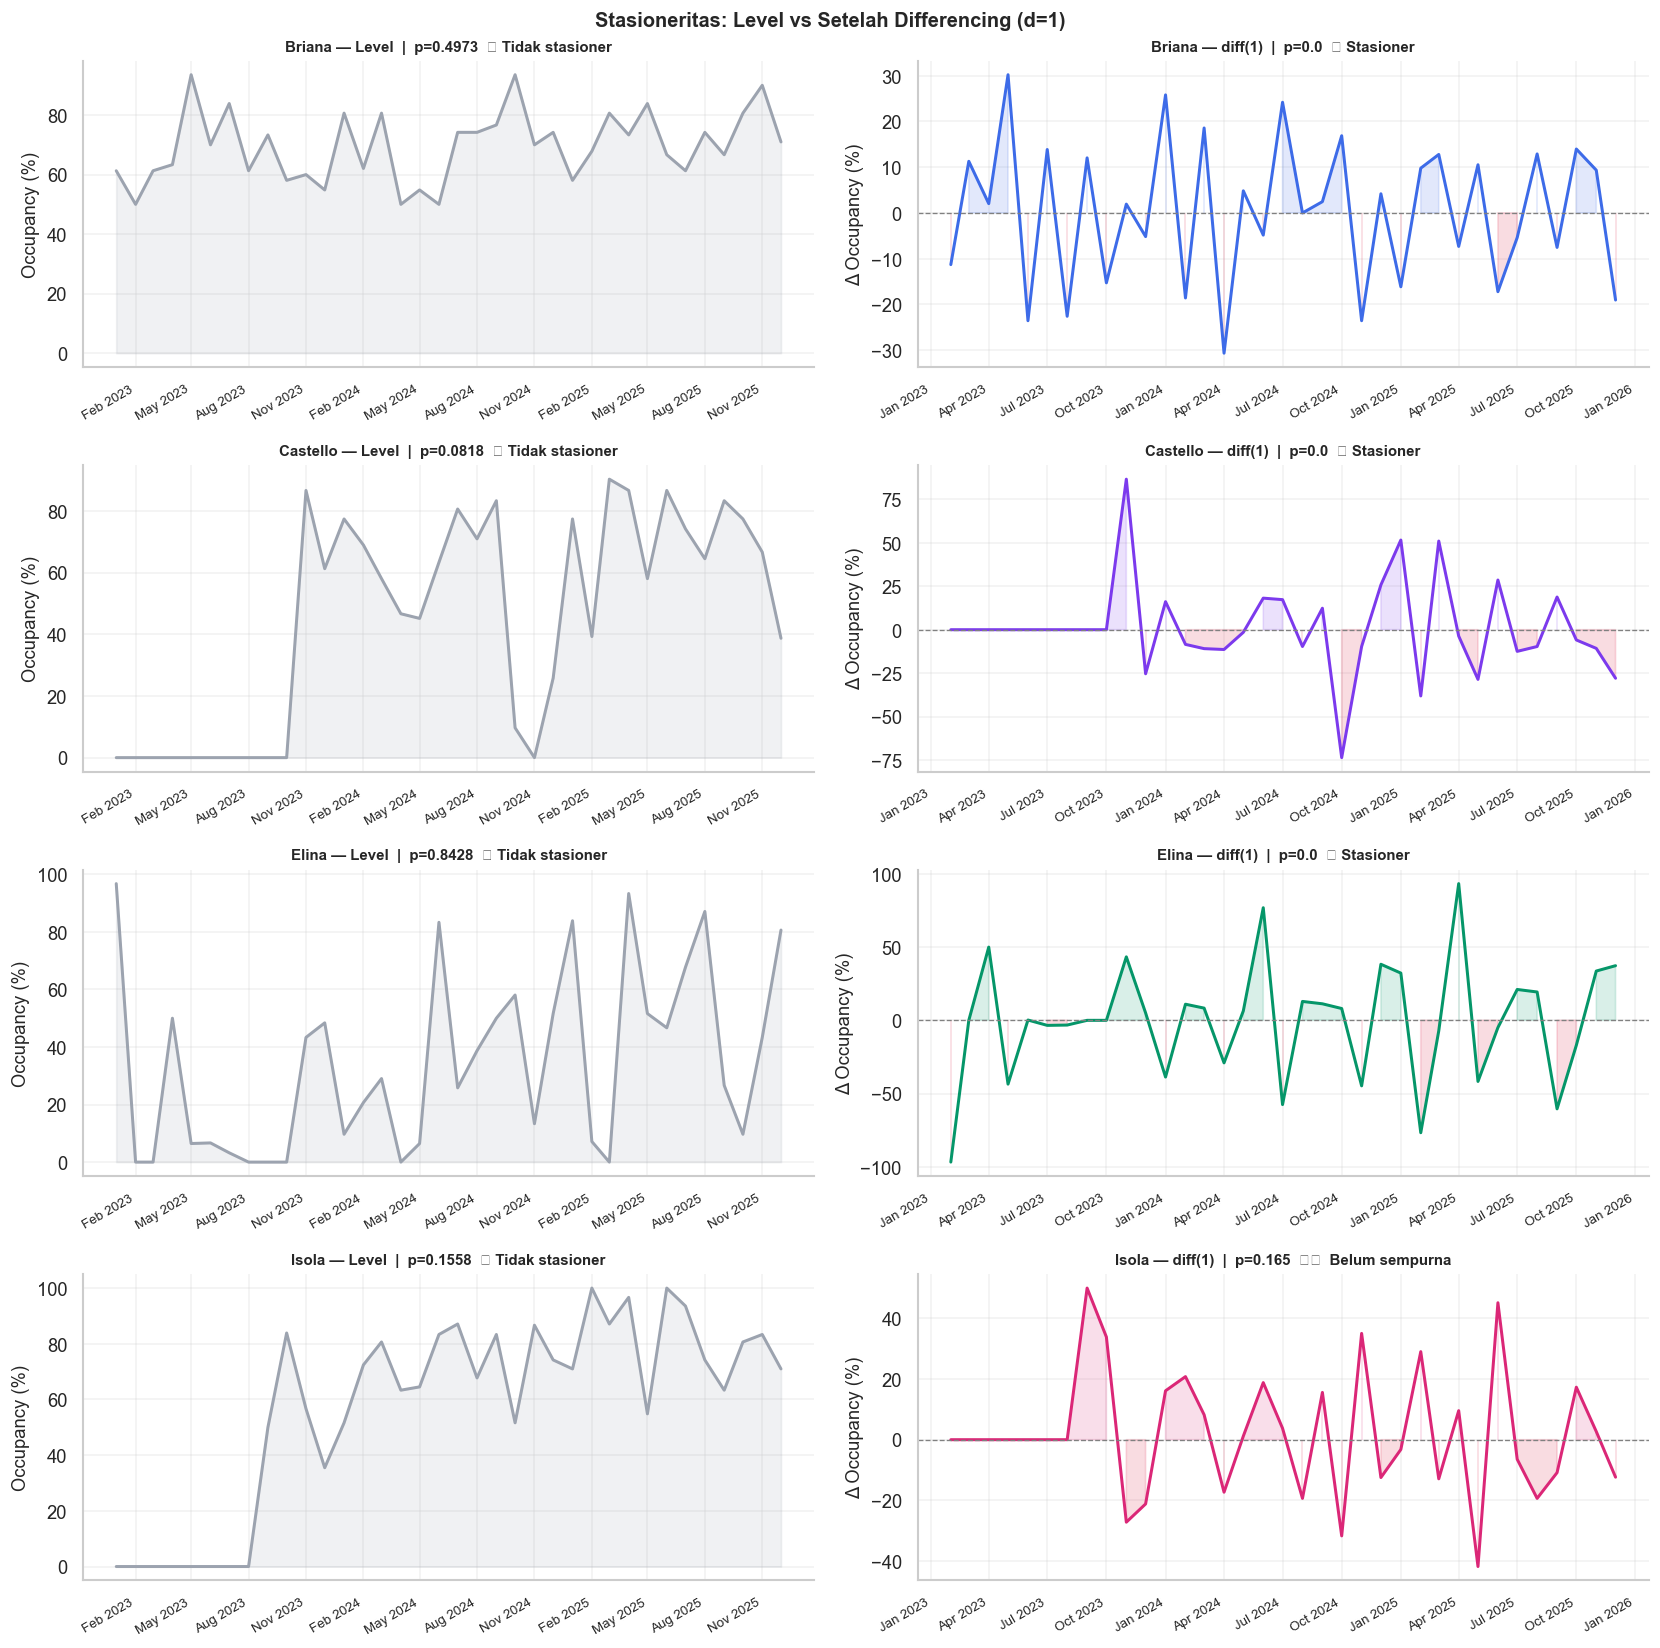


✅ villa_m (dari periodogram): {'briana_villas': 7, 'castello_villas': 18, 'elina_villas': 4, 'isola_villas': 18, 'eindra_villas': 12, 'esha_villas': 12, 'ozamiz_villas': 6}
   → Villa dengan m ≠ 12: {'briana_villas': 7, 'castello_villas': 18, 'elina_villas': 4, 'isola_villas': 18, 'ozamiz_villas': 6}  (perhatikan saat interpretasi!)


In [13]:
# ── 6. ADF TEST + AUTO-DIFFERENCING + VERIFIKASI
# Pipeline:
#   • Uji ADF level (d=0) → jika gagal → diff(1) → uji ulang
#   • d di-CAP maksimum 1 (d=2 tidak stabil untuk data < 48 bln)
#   • Simpan clean_occ_stationary & villa_d untuk cell berikutnya
#   • Plot before/after hanya untuk villa yang di-differencing

def adf_check(series, alpha=0.05):
    """Return (stasioner: bool, p_value, adf_stat)."""
    res = adfuller(series.dropna(), autolag='AIC')
    return res[1] < alpha, round(res[1], 4), round(res[0], 4)

clean_occ_stationary = {}
villa_d              = {}
adf_results          = []

for villa, series in clean_occ.items():
    monthly = series.resample('MS').mean().dropna()
    title   = villa.replace('_villas', '').title()
    area    = VILLA_CONFIG[villa]['area'].title()

    # ── d=0: uji level
    stat0, p0, adf0 = adf_check(monthly)

    if stat0:
        d_used       = 0
        series_final = monthly
        p1           = '-'
        note         = '✅ Stasioner (d=0)'
    else:
        # ── d=1: first difference — CAP di sini, tidak lanjut d=2
        diff1        = monthly.diff().dropna()
        stat1, p1, _ = adf_check(diff1)
        d_used       = 1
        series_final = diff1
        if stat1:
            note = f'🔄 Diff(1) → stasioner  (p_level={p0} → p_diff1={p1})'
        else:
            # Tetap d=1 meski belum stasioner sempurna — lebih aman dari d=2
            note = (f'⚠️  Diff(1) belum stasioner sempurna (p={p1}), '
                    f'tapi d=1 tetap dipakai (cap d_max=1)')

    # ── CAP d=1 (lindungi dari overfit pada data pendek)
    d_used = min(d_used, 1)

    clean_occ_stationary[villa] = series_final
    villa_d[villa]              = d_used

    adf_results.append({
        'Villa'        : title,
        'Area'         : area,
        'N (bln)'      : len(monthly),
        'ADF (level)'  : adf0,
        'p (level)'    : p0,
        'p (diff1)'    : p1,
        'd dipakai'    : d_used,
        'Keterangan'   : note,
    })

# ── Tabel ringkasan
adf_df = pd.DataFrame(adf_results)
print('UJI STASIONERITAS — AUGMENTED DICKEY-FULLER (α = 5%)')
print('=' * 90)
display(adf_df[['Villa','Area','N (bln)','ADF (level)','p (level)','p (diff1)',
                'd dipakai','Keterangan']])

villa_diffed = [v for v, d in villa_d.items() if d > 0]
if villa_diffed:
    names = [v.replace('_villas','').title() for v in villa_diffed]
    print(f'\n🔄 Villa yang di-differencing (d=1): {names}')
    print('   → villa_d tersimpan, akan dikunci ke auto_arima di cell 9.')
else:
    print('\n✅ Semua villa stasioner pada level (d=0).')

print(f'\nvilla_d = {villa_d}')

# ── Plot before/after untuk villa yang di-differencing
if villa_diffed:
    fig, axes = plt.subplots(len(villa_diffed), 2,
                             figsize=(14, 3.5 * len(villa_diffed)))
    if len(villa_diffed) == 1:
        axes = [axes]

    for ax_row, villa in zip(axes, villa_diffed):
        color   = VILLA_CONFIG[villa]['color']
        title   = villa.replace('_villas', '').title()
        monthly = clean_occ[villa].resample('MS').mean().dropna()
        stat_s  = clean_occ_stationary[villa]
        p0_val  = adf_df.loc[adf_df['Villa']==title, 'p (level)'].values[0]
        p1_val  = adf_df.loc[adf_df['Villa']==title, 'p (diff1)'].values[0]

        # Kiri: level — tidak stasioner
        ax_row[0].plot(monthly.index, monthly.values, color='#9ca3af', lw=1.8)
        ax_row[0].fill_between(monthly.index, monthly.values,
                               alpha=0.15, color='#9ca3af')
        ax_row[0].set_title(f'{title} — Level  |  p={p0_val}  ❌ Tidak stasioner',
                            fontsize=9, fontweight='bold')
        ax_row[0].set_ylabel('Occupancy (%)')

        # Kanan: setelah diff(1) — stasioner
        ax_row[1].plot(stat_s.index, stat_s.values, color=color, lw=1.8)
        ax_row[1].fill_between(stat_s.index, stat_s.values,
                               where=stat_s.values >= 0,
                               alpha=0.15, color=color)
        ax_row[1].fill_between(stat_s.index, stat_s.values,
                               where=stat_s.values < 0,
                               alpha=0.15, color='crimson')
        ax_row[1].axhline(0, color='gray', ls='--', lw=0.8)
        status = '✅ Stasioner' if float(p1_val) < 0.05 else '⚠️  Belum sempurna'
        ax_row[1].set_title(f'{title} — diff(1)  |  p={p1_val}  {status}',
                            fontsize=9, fontweight='bold')
        ax_row[1].set_ylabel('Δ Occupancy (%)')

        for ax in ax_row:
            ax.grid(alpha=0.25)
            ax.spines[['top', 'right']].set_visible(False)
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
            plt.setp(ax.xaxis.get_majorticklabels(),
                     rotation=30, ha='right', fontsize=8)

    plt.suptitle('Stasioneritas: Level vs Setelah Differencing (d=1)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('adf_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── [FIX-B] Guard villa_m — pastikan tersedia sebelum Cell 9
# Jika Cell 7b sudah dijalankan → villa_m ada, blok ini hanya konfirmasi.
# Jika Cell 7b di-skip → fallback m=12 untuk semua villa.
if 'villa_m' not in dir():
    print('\n⚠️  villa_m tidak ditemukan → jalankan Cell 7b untuk deteksi otomatis.')
    print('   Fallback: m=12 untuk semua villa (asumsi domain, bukan dari data).')
    villa_m = {v: 12 for v in clean_occ}
else:
    # Tampilkan ringkasan m agar mudah diverifikasi
    print(f'\n✅ villa_m (dari periodogram): {villa_m}')
    non12 = {k: v for k, v in villa_m.items() if v != 12}
    if non12:
        print(f'   → Villa dengan m ≠ 12: {non12}  (perhatikan saat interpretasi!)')
    else:
        print('   → Semua villa: m=12 (periode tahunan terkonfirmasi dari data)')


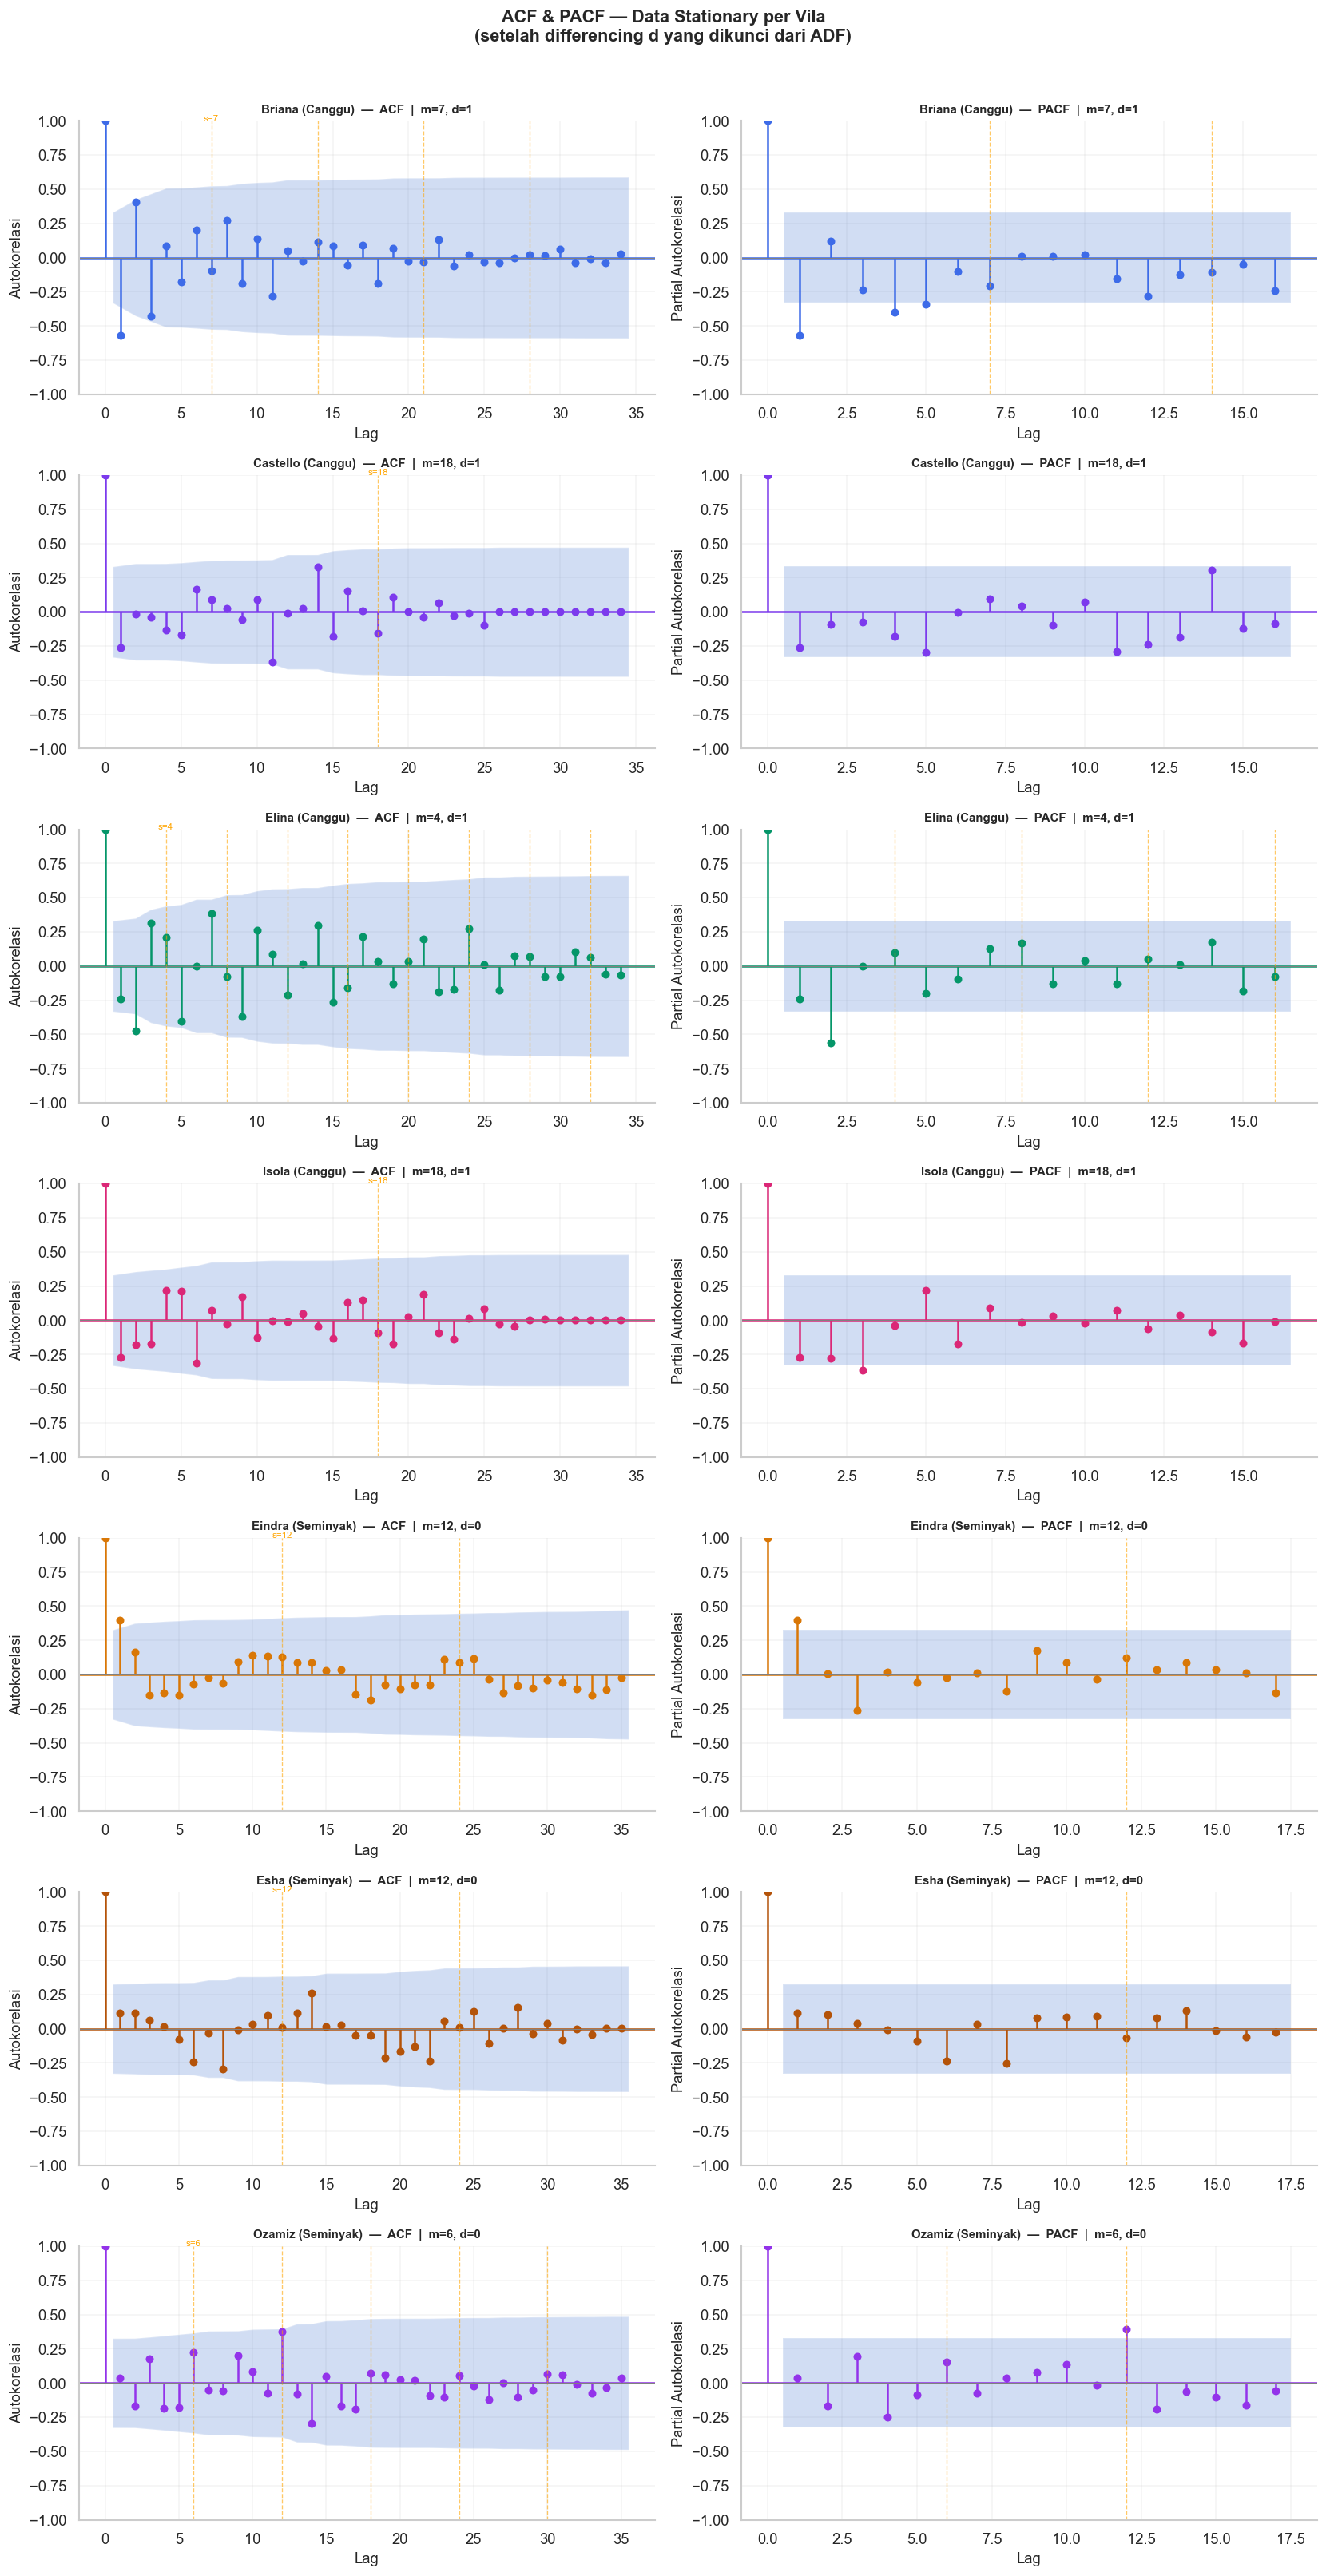

✅ Plot ACF & PACF disimpan ke: acf_pacf_stationary.png
   Vila yang diplot: ['Briana', 'Castello', 'Elina', 'Isola', 'Eindra', 'Esha', 'Ozamiz']

📌 Panduan baca:
   ACF  → tentukan orde q (MA non-musiman) dan Q (MA musiman)
   PACF → tentukan orde p (AR non-musiman) dan P (AR musiman)
   Garis oranye putus-putus = kelipatan periode musiman (s=m)


In [15]:
# ── CELL 7c — PLOT ACF & PACF PER VILA (DATA STATIONARY)
# Pipeline:
#   • Gunakan clean_occ_stationary (hasil differencing dari Cell 6)
#   • Plot ACF & PACF berdampingan per vila
#   • Warna mengikuti VILLA_CONFIG
#   • Jumlah lag = min(36, len(data)-1), max_lag PACF = floor(len/2)
#   • Disimpan ke acf_pacf_stationary.png

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math

# ── Pastikan data stationary tersedia
assert 'clean_occ_stationary' in dir(), \
    "❌ Jalankan Cell 6 terlebih dahulu (clean_occ_stationary belum ada)"
assert 'villa_m' in dir(), \
    "❌ Jalankan Cell 7b terlebih dahulu (villa_m belum ada)"

n_villas = len(clean_occ_stationary)
fig, axes = plt.subplots(
    n_villas, 2,
    figsize=(14, 3.8 * n_villas)
)

# Guard: jika hanya 1 vila
if n_villas == 1:
    axes = [axes]

fig.suptitle(
    'ACF & PACF — Data Stationary per Vila\n'
    '(setelah differencing d yang dikunci dari ADF)',
    fontsize=13, fontweight='bold', y=1.01
)

for ax_row, (villa, series) in zip(axes, clean_occ_stationary.items()):
    title  = villa.replace('_villas', '').title()
    area   = VILLA_CONFIG[villa]['area'].title()
    color  = VILLA_CONFIG[villa]['color']
    m_val  = villa_m[villa]
    d_val  = villa_d[villa]
    n      = len(series.dropna())

    # Batas lag aman
    max_lag_acf  = min(36, n - 1)
    max_lag_pacf = min(int(n / 2) - 1, 18)  # PACF butuh lebih sedikit lag

    ax_acf, ax_pacf = ax_row[0], ax_row[1]

    # ── ACF
    plot_acf(
        series.dropna(),
        lags   = max_lag_acf,
        ax     = ax_acf,
        color  = color,
        vlines_kwargs={'colors': color},
        alpha  = 0.05,
        zero   = True,
        title  = ''
    )
    ax_acf.set_title(
        f'{title} ({area})  —  ACF  |  m={m_val}, d={d_val}',
        fontsize=9, fontweight='bold'
    )
    ax_acf.set_xlabel('Lag')
    ax_acf.set_ylabel('Autokorelasi')

    # Tandai kelipatan m (periode musiman)
    for lag_mark in range(m_val, max_lag_acf + 1, m_val):
        ax_acf.axvline(lag_mark, color='orange', lw=0.8, ls='--', alpha=0.6)
    ax_acf.annotate(
        f's={m_val}', xy=(m_val, ax_acf.get_ylim()[1]),
        fontsize=7, color='orange', ha='center'
    )

    # ── PACF
    plot_pacf(
        series.dropna(),
        lags   = max_lag_pacf,
        ax     = ax_pacf,
        color  = color,
        vlines_kwargs={'colors': color},
        alpha  = 0.05,
        zero   = True,
        method = 'ywm',   # Yule-Walker modified — stabil untuk data pendek
        title  = ''
    )
    ax_pacf.set_title(
        f'{title} ({area})  —  PACF  |  m={m_val}, d={d_val}',
        fontsize=9, fontweight='bold'
    )
    ax_pacf.set_xlabel('Lag')
    ax_pacf.set_ylabel('Partial Autokorelasi')

    # Tandai kelipatan m
    for lag_mark in range(m_val, max_lag_pacf + 1, m_val):
        ax_pacf.axvline(lag_mark, color='orange', lw=0.8, ls='--', alpha=0.6)

    # Styling
    for ax in [ax_acf, ax_pacf]:
        ax.grid(alpha=0.2)
        ax.spines[['top', 'right']].set_visible(False)
        ax.axhline(0, color='gray', lw=0.6)

plt.tight_layout()
plt.savefig('acf_pacf_stationary.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Plot ACF & PACF disimpan ke: acf_pacf_stationary.png')
print(f'   Vila yang diplot: {[v.replace("_villas","").title() for v in clean_occ_stationary]}')
print('\n📌 Panduan baca:')
print('   ACF  → tentukan orde q (MA non-musiman) dan Q (MA musiman)')
print('   PACF → tentukan orde p (AR non-musiman) dan P (AR musiman)')
print('   Garis oranye putus-putus = kelipatan periode musiman (s=m)')

---
## 9. Auto ARIMA & Fitting Model SARIMA
`auto_arima` mencari kombinasi (p,d,q)(P,D,Q)[12] terbaik berdasarkan AIC.  
Split: **80% train / 20% test**.

In [ ]:
# ── CELL 9 — AUTO ARIMA: PEMILIHAN MODEL SARIMA PER VILA
# Pipeline:
#   • auto_arima stepwise=True (efisien, jalur pencarian otomatis)
#   • return_valid_fits=True → semua model yang dicoba selama stepwise terekam
#   • CSV 1: sarima_model_selection.csv   → model terpilih per vila
#   • CSV 2: sarima_all_candidates.csv    → semua kandidat stepwise + AIC/BIC

from pmdarima import auto_arima
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Pastikan dependensi tersedia
assert 'villa_d'   in dir(), "❌ Jalankan Cell 6 (villa_d belum ada)"
assert 'villa_m'   in dir(), "❌ Jalankan Cell 7b (villa_m belum ada)"
assert 'clean_occ' in dir(), "❌ clean_occ belum tersedia"

sarima_models  = {}
sarima_results = []
all_candidates = []

print('AUTO ARIMA (STEPWISE) — PEMILIHAN MODEL SARIMA PER VILA')
print('=' * 75)

for villa, series in clean_occ.items():
    title   = villa.replace('_villas', '').title()
    area    = VILLA_CONFIG[villa]['area'].title()
    d_val   = villa_d[villa]
    m_val   = villa_m[villa]
    monthly = series.resample('MS').mean().dropna()

    print(f'\n{"─"*75}')
    print(f'🔍  {title} ({area})  |  d={d_val}, D=1, m={m_val}')
    print(f'{"─"*75}')

    try:
        # ── auto_arima dengan return_valid_fits=True
        # return_valid_fits  → kembalikan LIST semua model valid yang dicoba
        # return_all_fits tidak ada di pmdarima, tapi valid_fits sudah cukup
        all_fits = auto_arima(
            monthly,
            d                    = d_val,
            D                    = 1,
            m                    = m_val,
            max_p                = 3,
            max_q                = 3,
            max_P                = 2,
            max_Q                = 2,
            seasonal             = True,
            stepwise             = True,
            information_criterion= 'aic',
            error_action         = 'ignore',
            suppress_warnings    = True,
            trace                = False,      # matikan trace bawaan, kita print sendiri
            return_valid_fits    = True        # ← kunci: kembalikan semua kandidat valid
        )

        # all_fits adalah list model; urutkan berdasarkan AIC
        all_fits_sorted = sorted(all_fits, key=lambda m: m.aic())
        best_model      = all_fits_sorted[0]   # AIC terkecil = terpilih

        # ── Tampilkan semua kandidat stepwise
        print(f'  {"#":<4} {"Kandidat Model":<38} {"AIC":>10} {"BIC":>10} {"Ket":>10}')
        print(f'  {"─"*4} {"─"*38} {"─"*10} {"─"*10} {"─"*10}')

        best_label = str(best_model.order) + str(best_model.seasonal_order)

        for rank, mdl in enumerate(all_fits_sorted, 1):
            o  = mdl.order
            so = mdl.seasonal_order
            label  = f'SARIMA{o}{so}'
            aic_v  = round(mdl.aic(), 4)
            bic_v  = round(mdl.bic(), 4)
            flag   = '⭐ BEST' if rank == 1 else ''

            print(f'  {rank:<4} {label:<38} {aic_v:>10.4f} {bic_v:>10.4f} {flag:>10}')

            all_candidates.append({
                'Vila'         : title,
                'Area'         : area,
                'p'            : o[0],
                'd'            : o[1],
                'q'            : o[2],
                'P'            : so[0],
                'D'            : so[1],
                'Q'            : so[2],
                's (m)'        : so[3],
                'Model SARIMA' : label,
                'AIC'          : aic_v,
                'BIC'          : bic_v,
                'Rank AIC'     : rank,
                'Terpilih'     : '⭐ BEST' if rank == 1 else '',
            })

        # ── Simpan model terpilih
        sarima_models[villa] = best_model
        best_o  = best_model.order
        best_so = best_model.seasonal_order

        n_valid = len(all_fits_sorted)
        sarima_results.append({
            'Vila'        : title,
            'Area'        : area,
            'p'           : best_o[0],
            'd'           : best_o[1],
            'q'           : best_o[2],
            'P'           : best_so[0],
            'D'           : best_so[1],
            'Q'           : best_so[2],
            's (m)'       : best_so[3],
            'Model SARIMA': f'SARIMA{best_o}{best_so}',
            'AIC'         : round(best_model.aic(), 4),
            'BIC'         : round(best_model.bic(), 4),
            'N Kandidat'  : n_valid,
            'Status'      : '✅ Berhasil'
        })

        print(f'\n  ⭐ Terpilih : SARIMA{best_o}{best_so}')
        print(f'     AIC = {round(best_model.aic(),4)}  |  '
              f'BIC = {round(best_model.bic(),4)}  |  '
              f'dari {n_valid} kandidat stepwise')

    except Exception as e:
        print(f'  ❌ Gagal: {e}')
        sarima_results.append({
            'Vila': title, 'Area': area,
            'p':'-','d':'-','q':'-','P':'-','D':'-','Q':'-','s (m)':m_val,
            'Model SARIMA': 'GAGAL', 'AIC': None, 'BIC': None,
            'N Kandidat': 0, 'Status': f'❌ Error: {e}'
        })

# ── Tabel ringkasan akhir
print('\n\n' + '=' * 75)
print('RINGKASAN MODEL SARIMA TERPILIH PER VILA')
print('=' * 75)
result_df = pd.DataFrame(sarima_results)
display(result_df[['Vila','Area','Model SARIMA','AIC','BIC','N Kandidat','Status']])

# ── Tabel semua kandidat stepwise
cand_df = pd.DataFrame(all_candidates)
print(f'\nTotal kandidat stepwise terekam: {len(cand_df)} baris')
display(
    cand_df[['Vila','Model SARIMA','AIC','BIC','Rank AIC','Terpilih']]
    .sort_values(['Vila','Rank AIC'])
    .reset_index(drop=True)
)

# ── Export CSV
csv_best = 'sarima_model_selection.csv'
csv_all  = 'sarima_all_candidates.csv'
result_df.to_csv(csv_best, index=False)
cand_df.to_csv(csv_all,  index=False)

print(f'\n💾 Model terpilih  → {csv_best}')
print(f'💾 Semua kandidat  → {csv_all}')
print(f'\n✅ sarima_models tersimpan untuk {len(sarima_models)} vila → siap di cell forecasting.')

AUTO ARIMA (STEPWISE) — PEMILIHAN MODEL SARIMA PER VILA
Parameter: identik dengan app.py train_sarima()

───────────────────────────────────────────────────────────────────────────
🔍  Briana (Canggu)
    d=1 | m=7 | seasonal=True | max_pq=2 | max_PQ=1
    Train: 30 bln (Jan 2023–Jun 2025) | Test: 6 bln (Jul 2025–Dec 2025)
───────────────────────────────────────────────────────────────────────────
  #    Kandidat Model                                  AIC        BIC        Ket
  ──── ──────────────────────────────────────── ────────── ────────── ──────────
  1    SARIMA(1, 1, 0)(1, 1, 0, 7)                180.1499   183.4230     ⭐ BEST
  2    SARIMA(1, 1, 1)(1, 1, 0, 7)                181.0047   185.3689           
  3    SARIMA(2, 1, 0)(1, 1, 0, 7)                181.1050   185.4692           
  4    SARIMA(1, 1, 0)(1, 1, 1, 7)                181.9991   186.3633           
  5    SARIMA(1, 1, 0)(1, 1, 0, 7)                182.0982   186.4624           
  6    SARIMA(1, 1, 0)(0, 1, 1, 7

,Vila,Area,Model SARIMA,AIC,BIC,RMSE (%),MAPE (%),N Kandidat,Status
0,Briana,Canggu,"SARIMA(1, 1, 0)(1, 1, 0, 7)",103.26,105.18,12.19,13.92,12,✅ Berhasil
1,Castello,Canggu,"SARIMA(0, 1, 0)(0, 1, 0, 18)",110.20,110.50,26.14,37.18,5,✅ Berhasil
2,Elina,Canggu,"SARIMA(0, 1, 1)(0, 1, 0, 4)",235.02,237.29,37.44,121.84,8,✅ Berhasil
3,Isola,Canggu,"SARIMA(0, 1, 0)(0, 1, 0, 18)",101.81,102.11,24.31,30.75,7,✅ Berhasil
4,Eindra,Seminyak,"SARIMA(0, 0, 0)(0, 1, 0, 12)",145.59,146.42,12.42,12.87,10,✅ Berhasil
5,Esha,Seminyak,"SARIMA(0, 0, 0)(0, 1, 0, 12)",148.60,149.43,18.36,15.26,10,✅ Berhasil
6,Ozamiz,Seminyak,"SARIMA(0, 0, 0)(1, 1, 0, 6)",159.55,161.33,16.25,18.23,10,✅ Berhasil



Total kandidat stepwise terekam: 62 baris


,Vila,Model SARIMA,AIC,BIC,Rank AIC,N Kandidat,Terpilih
0,Briana,"SARIMA(1, 1, 0)(1, 1, 0, 7)",180.15,183.42,1,12,⭐ BEST
1,Briana,"SARIMA(1, 1, 1)(1, 1, 0, 7)",181.00,185.37,2,12,
2,Briana,"SARIMA(2, 1, 0)(1, 1, 0, 7)",181.10,185.47,3,12,
3,Briana,"SARIMA(1, 1, 0)(1, 1, 1, 7)",182.00,186.36,4,12,
4,Briana,"SARIMA(1, 1, 0)(1, 1, 0, 7)",182.10,186.46,5,12,
...,...,...,...,...,...,...,...
57,Ozamiz,"SARIMA(1, 0, 0)(1, 1, 1, 6)",213.44,219.33,6,10,
58,Ozamiz,"SARIMA(1, 0, 1)(1, 1, 0, 6)",213.90,219.79,7,10,
59,Ozamiz,"SARIMA(0, 0, 0)(0, 1, 0, 6)",222.97,224.15,8,10,
60,Ozamiz,"SARIMA(0, 0, 0)(0, 1, 0, 6)",224.36,226.71,9,10,



💾 Model terpilih  → sarima_model_selection.csv
   Kolom: ['Vila', 'Area', 'p', 'd', 'q', 'P', 'D', 'Q', 's (m)', 'Model SARIMA', 'AIC', 'BIC', 'RMSE (%)', 'MAPE (%)', 'N Train', 'N Test', 'N Kandidat', 'Status']

💾 Semua kandidat  → sarima_all_candidates.csv
   Total baris: 62

✅ sarima_models tersimpan untuk 7 vila
   Format dict identik dengan app.py → siap digunakan di cell forecasting.

📌 Untuk menyamakan hasil di Streamlit: force retrain dari UI app.py
   (centang Force Retrain → klik Mulai Training)



[Briana]  refit pada 36 bln  → forecast 6 bln setelah Dec 2025  m=7


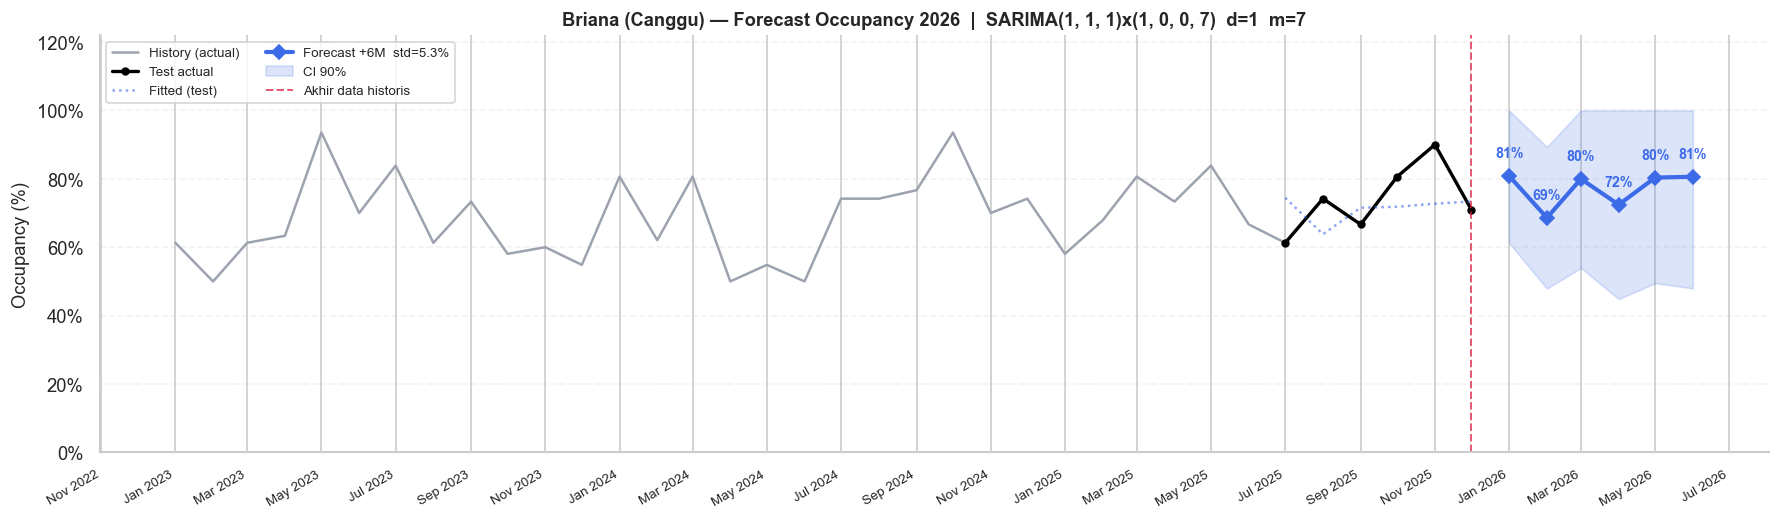


[Castello]  refit pada 36 bln  → forecast 6 bln setelah Dec 2025  m=18
  ⚠️  Forecast flat (std=0.00%) → retry dengan seasonal order paksa (m=18)...
     seasonal (1, 0, 0, 18): AIC=167.1  std=16.38%  ✅
     seasonal (0, 0, 1, 18): AIC=160.2  std=14.51%  ✅
     seasonal (1, 0, 1, 18): AIC=160.4  std=24.33%  ✅
  → Pakai seasonal (1, 0, 1, 18)  AIC=160.4  std=24.33%


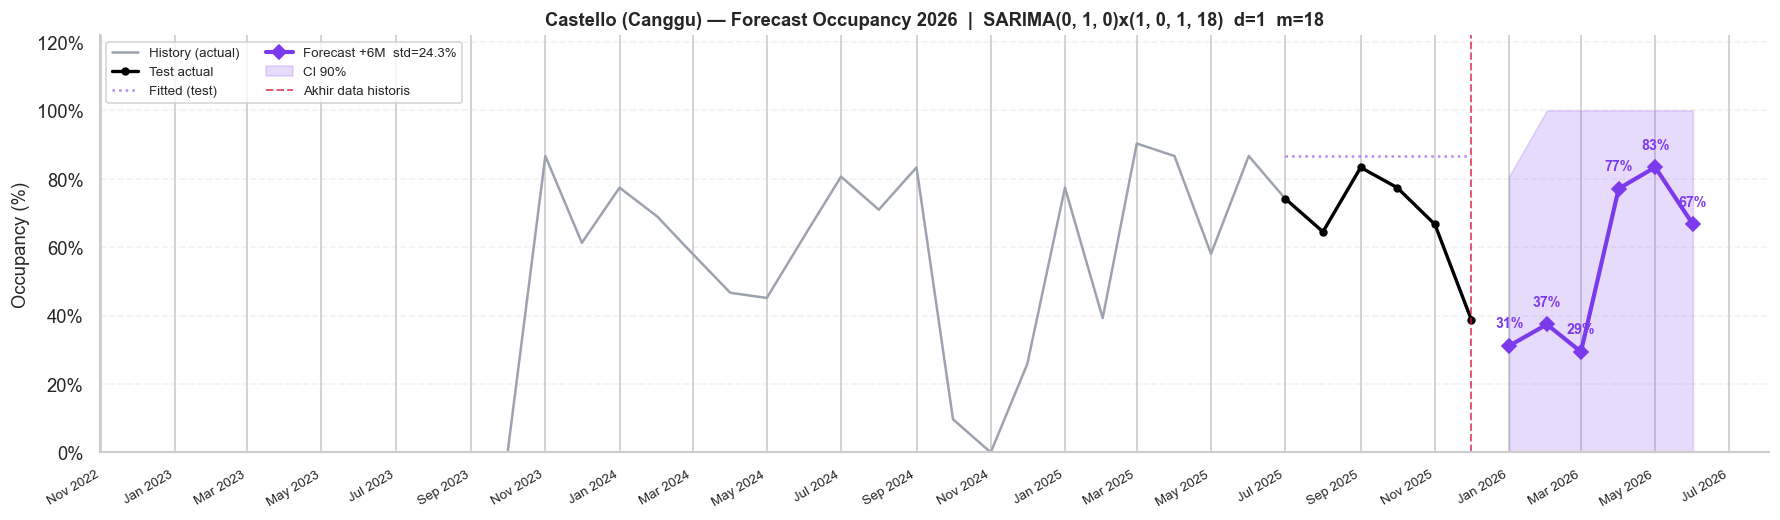


[Elina]  refit pada 36 bln  → forecast 6 bln setelah Dec 2025  m=4
  ⚠️  Forecast flat (std=0.00%) → retry dengan seasonal order paksa (m=4)...
     seasonal (1, 0, 0, 4): AIC=313.6  std=6.31%  ✅
     seasonal (0, 0, 1, 4): AIC=303.0  std=11.22%  ✅
     seasonal (1, 0, 1, 4): AIC=305.0  std=11.27%  ✅
  → Pakai seasonal (1, 0, 1, 4)  AIC=305.0  std=11.27%


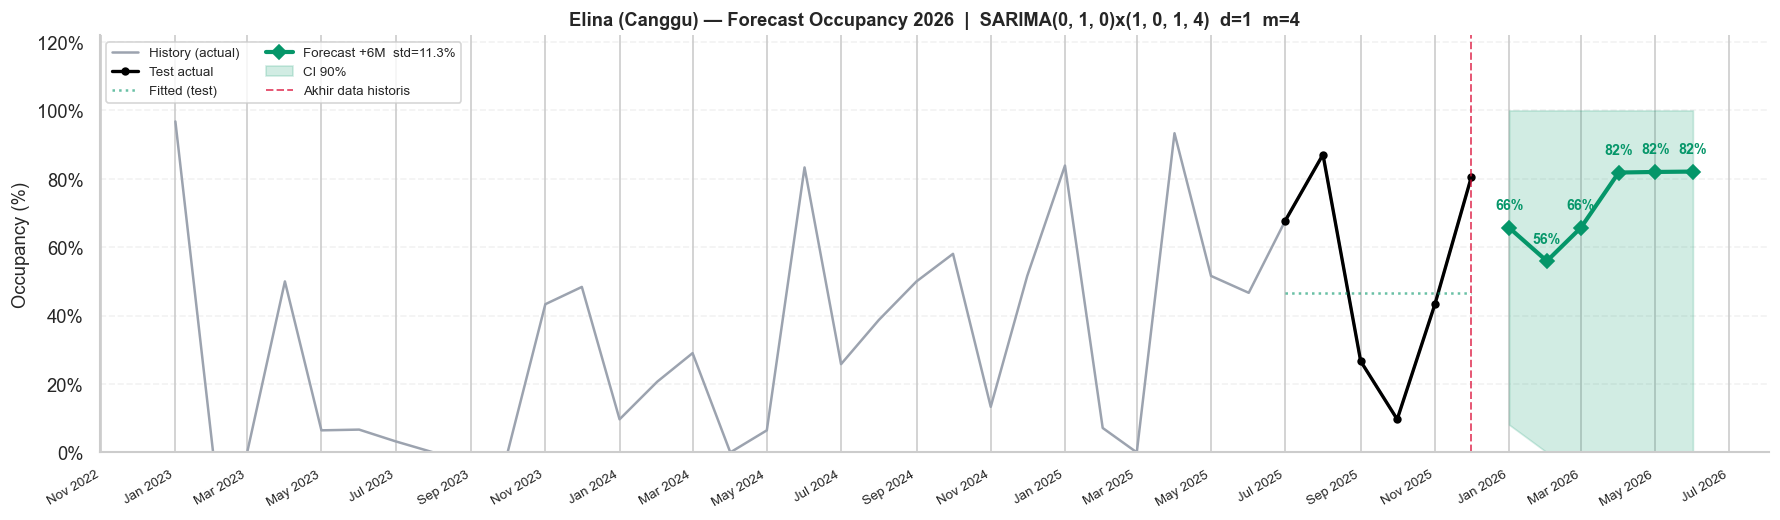


[Isola]  refit pada 36 bln  → forecast 6 bln setelah Dec 2025  m=18
  ⚠️  Forecast flat (std=0.00%) → retry dengan seasonal order paksa (m=18)...
     seasonal (1, 0, 0, 18): AIC=147.2  std=0.01%
     seasonal (0, 0, 1, 18): AIC=131.7  std=0.04%
     seasonal (1, 0, 1, 18): AIC=133.7  std=6.15%  ✅
  → Pakai seasonal (1, 0, 1, 18)  AIC=133.7  std=6.15%


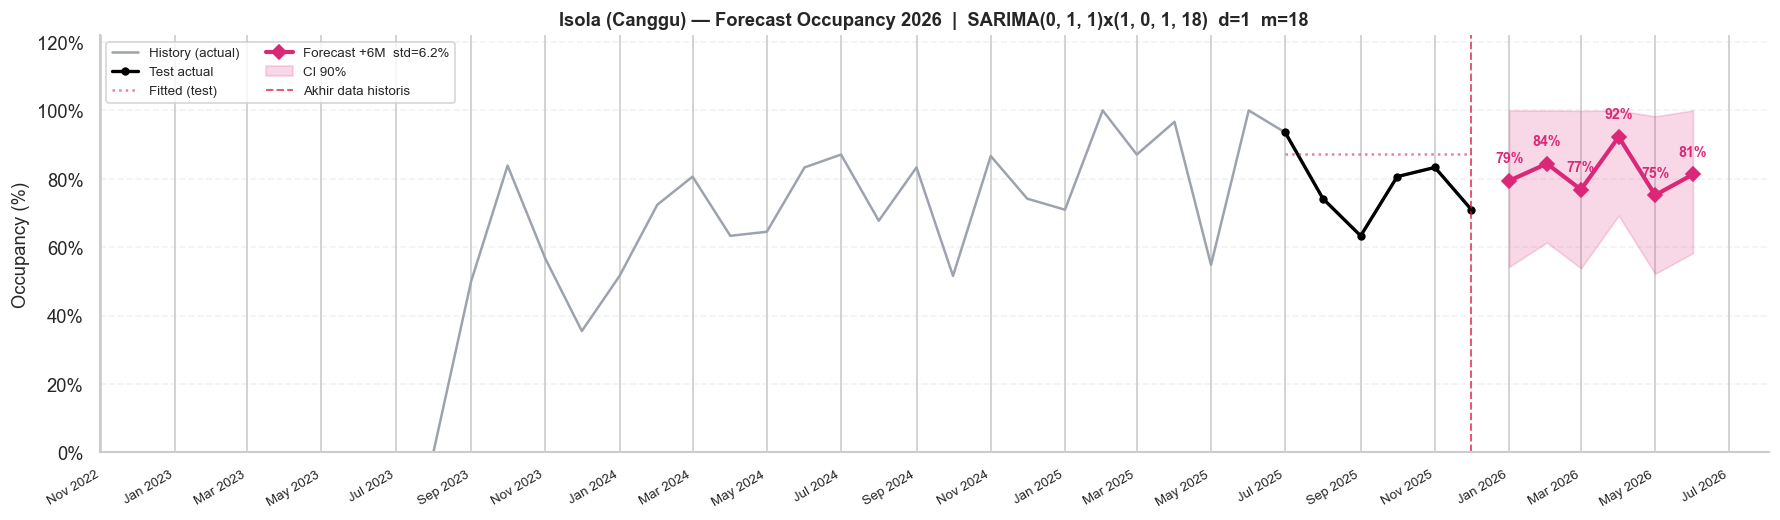


[Eindra]  refit pada 36 bln  → forecast 6 bln setelah Dec 2025  m=12
  ⚠️  Forecast flat (std=1.41%) → retry dengan seasonal order paksa (m=12)...
     seasonal (1, 0, 0, 12): AIC=181.1  std=2.41%  ✅
     seasonal (0, 0, 1, 12): AIC=175.2  std=1.22%
     seasonal (1, 0, 1, 12): AIC=175.5  std=2.42%  ✅
  → Pakai seasonal (1, 0, 1, 12)  AIC=175.5  std=2.42%


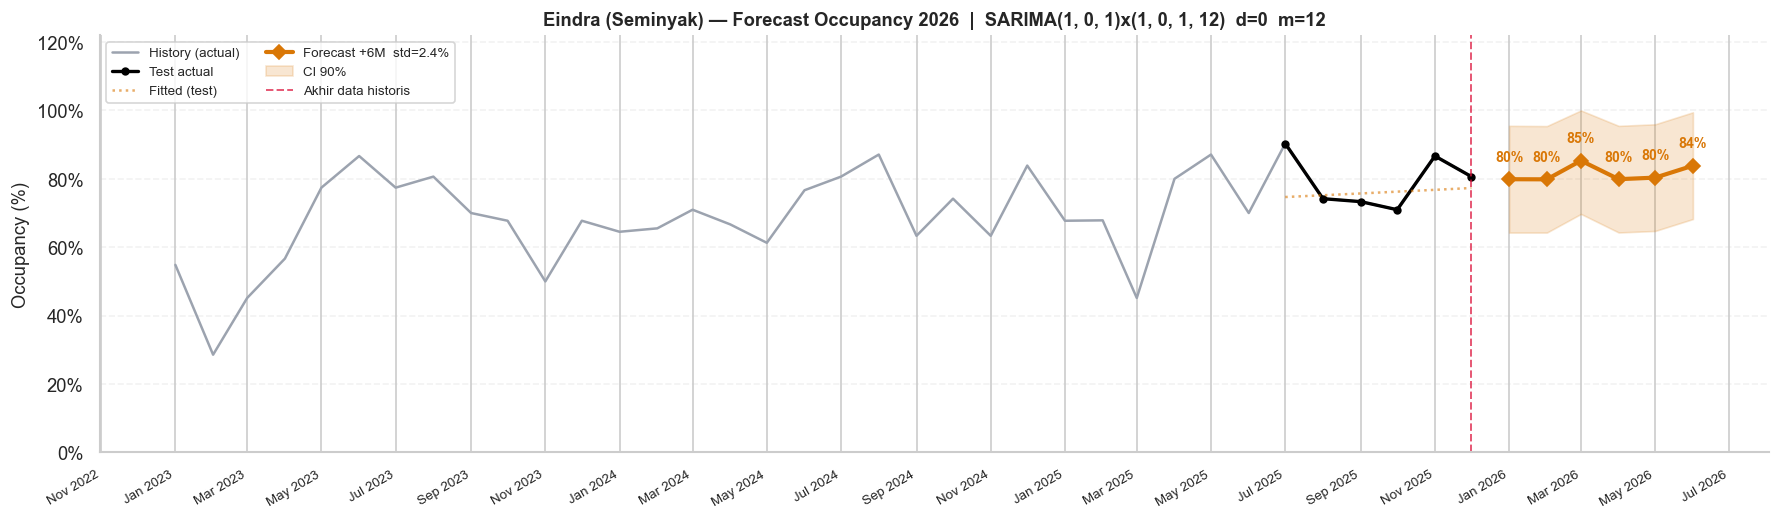


[Esha]  refit pada 36 bln  → forecast 6 bln setelah Dec 2025  m=12


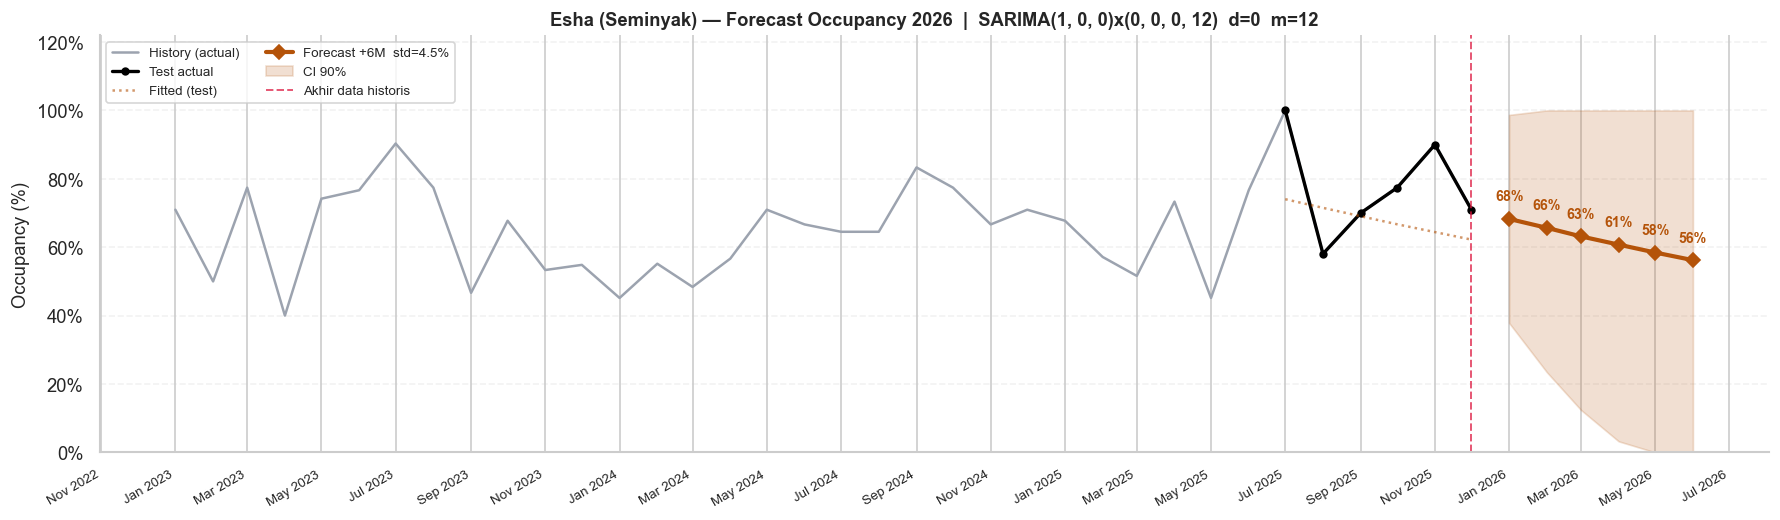


[Ozamiz]  refit pada 36 bln  → forecast 6 bln setelah Dec 2025  m=6


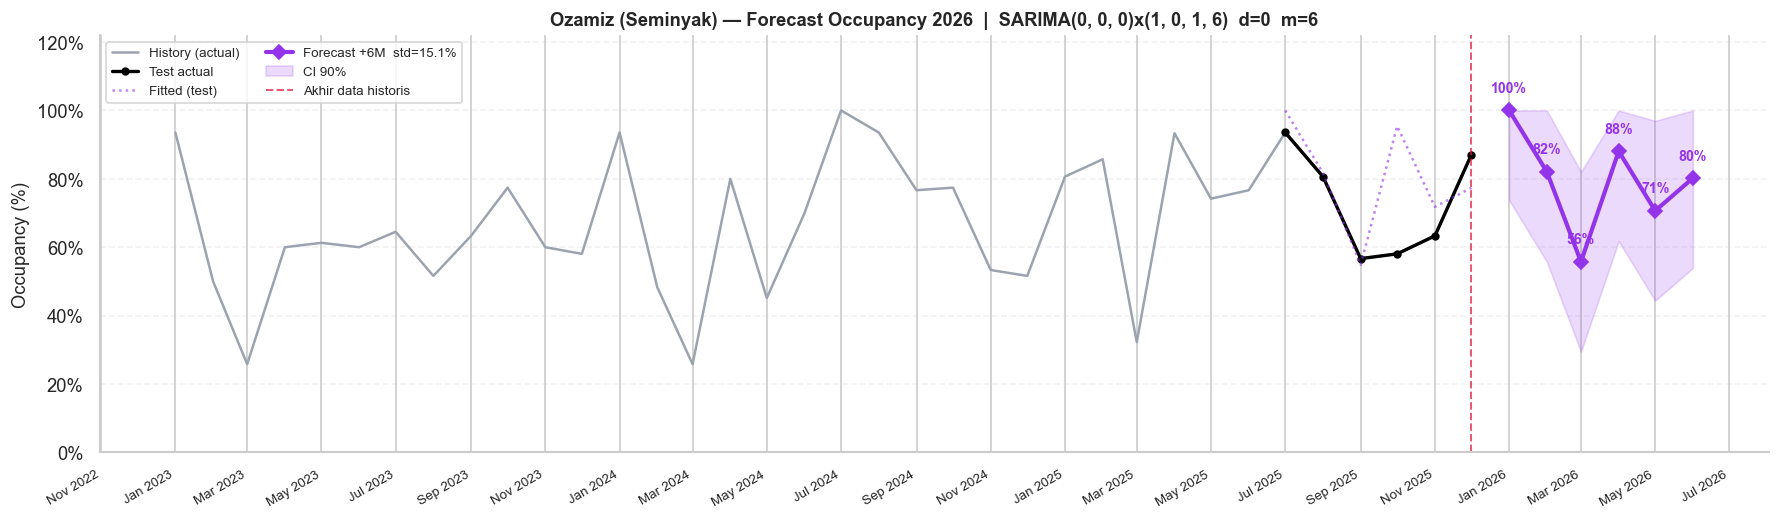

TABEL FORECAST OCCUPANCY +6 BULAN — SEMUA VILLA


Area  Forecast (%)  Lower CI 90%  Upper CI 90%  \
Villa    Bulan                                                          
Briana   Jan 2026    Canggu         80.80         61.20        100.00   
         Feb 2026    Canggu         68.60         47.90         89.30   
         Mar 2026    Canggu         80.00         54.00        100.00   
         Apr 2026    Canggu         72.50         44.80        100.00   
         May 2026    Canggu         80.40         49.50        100.00   
         Jun 2026    Canggu         80.60         48.00        100.00   
Castello Jan 2026    Canggu         31.20          0.00         80.70   
         Feb 2026    Canggu         37.40          0.00        100.00   
         Mar 2026    Canggu         29.40          0.00        100.00   
         Apr 2026    Canggu         77.10          0.00        100.00   
         May 2026    Canggu         83.40          0.00        100.00   
         Jun 2026    Canggu         66.70          0.00        100.00   
Elina    Jan 2026    Canggu         65.70          8.10        100.00   
         Feb 2026    Canggu         56.00          0.00        100.00   
         Mar 2026    Canggu         65.70          0.00        100.00   
         Apr 2026    Canggu         81.80          0.00        100.00   
         May 2026    Canggu         82.00          0.00        100.00   
         Jun 2026    Canggu         82.10          0.00        100.00   
Isola    Jan 2026    Canggu         79.40         54.20        100.00   
         Feb 2026    Canggu         84.40         61.40        100.00   
         Mar 2026    Canggu         76.90         53.80         99.90   
         Apr 2026    Canggu         92.30         69.20        100.00   
         May 2026    Canggu         75.20         52.20         98.30   
         Jun 2026    Canggu         81.30         58.30        100.00   
Eindra   Jan 2026  Seminyak         79.90         64.30         95.50   
         Feb 2026  Seminyak         79.90         64.30         95.40   
         Mar 2026  Seminyak         85.30         69.70        100.00   
         Apr 2026  Seminyak         79.90         64.30         95.50   
         May 2026  Seminyak         80.40         64.80         96.00   
         Jun 2026  Seminyak         83.80         68.20         99.50   
Esha     Jan 2026  Seminyak         68.30         37.80         98.70   
         Feb 2026  Seminyak         65.70         23.40        100.00   
         Mar 2026  Seminyak         63.20         12.40        100.00   
         Apr 2026  Seminyak         60.80          3.20        100.00   
         May 2026  Seminyak         58.40          0.00        100.00   
         Jun 2026  Seminyak         56.20          0.00        100.00   
Ozamiz   Jan 2026  Seminyak        100.00         73.70        100.00   
         Feb 2026  Seminyak         82.00         55.70        100.00   
         Mar 2026  Seminyak         55.80         29.50         82.00   
         Apr 2026  Seminyak         88.10         61.80        100.00   
         May 2026  Seminyak         70.70         44.40         96.90   
         Jun 2026  Seminyak         80.20         53.90        100.00   

                   Rentang CI Flat?  
Villa    Bulan                       
Briana   Jan 2026       38.80     ✅  
         Feb 2026       41.40     ✅  
         Mar 2026       46.00     ✅  
         Apr 2026       55.20     ✅  
         May 2026       50.50     ✅  
         Jun 2026       52.00     ✅  
Castello Jan 2026       80.70     ✅  
         Feb 2026      100.00     ✅  
         Mar 2026      100.00     ✅  
         Apr 2026      100.00     ✅  
         May 2026      100.00     ✅  
         Jun 2026      100.00     ✅  
Elina    Jan 2026       91.90     ✅  
         Feb 2026      100.00     ✅  
         Mar 2026      100.00     ✅  
         Apr 2026      100.00     ✅  
         May 2026      100.00     ✅  
         Jun 2026      100.00     ✅  
Isola    Jan 2026       45.80     ✅  
         Feb


✅ Tersimpan: forecast_occupancy_2026.csv

RINGKASAN STATUS FORECAST
✅ Bervariansi (7 villa): ['Briana', 'Castello', 'Elina', 'Isola', 'Eindra', 'Esha', 'Ozamiz']
🎉 Semua villa berhasil mendapat forecast bervariansi!


In [14]:
# ── 10. FORECAST +6 BULAN KE DEPAN (2026)
#
# Fix dari sesi debugging:
#   [1] Deteksi forecast flat (std < 1.5%) → retry dengan seasonal kandidat
#   [2] Refit pada SELURUH data historis untuk forecast masa depan
#   [3] Kolom 'Flat?' di tabel untuk identifikasi villa bermasalah
#   [4] Warna plot berbeda: hijau = bervariansi, merah = masih flat
#
# FIX-D: SEASONAL_RETRY per villa menggunakan m dari villa_m (bukan hardcode 12)

FORECAST_STEPS  = 6
FLAT_STD_THRESH = 1.5   # std forecast < ini → dianggap flat

forecast_rows = []
flat_villas   = []   # log villa yang masih flat setelah retry

for villa, info in sarima_models.items():
    monthly  = info['monthly']
    order    = info['order']
    s_order  = info['seasonal_order']
    d        = info['d']
    # FIX-D: ambil m aktual dari sarima_models (sudah disimpan di Cell 9)
    m_used   = info.get('m', villa_m.get(villa, 12))
    color    = VILLA_CONFIG[villa]['color']
    title    = villa.replace('_villas', '').title()
    area     = VILLA_CONFIG[villa]['area'].title()

    # FIX-D: Kandidat seasonal order retry pakai m_used (bukan hardcode 12)
    SEASONAL_RETRY = [
        (1, 0, 0, m_used),
        (0, 0, 1, m_used),
        (1, 0, 1, m_used),
    ]

    print(f'\n[{title}]  refit pada {len(monthly)} bln  '
          f'→ forecast {FORECAST_STEPS} bln '
          f'setelah {monthly.index[-1].strftime("%b %Y")}  m={m_used}')

    # ── Refit pada SELURUH data
    try:
        model_full = SARIMAX(
            monthly,
            order                 = order,
            seasonal_order        = s_order,
            enforce_stationarity  = False,
            enforce_invertibility = False,
        ).fit(disp=False)
    except Exception as e:
        print(f'  ⚠️  Refit gagal ({str(e)[:50]}) → pakai model train')
        model_full = info['model']

    # ── Forecast awal
    fore_obj  = model_full.get_forecast(steps=FORECAST_STEPS)
    fore_mean = fore_obj.predicted_mean.clip(0, 100)
    fore_ci   = fore_obj.conf_int(alpha=0.10).clip(0, 100)
    fore_std  = fore_mean.std()

    # ── [1] Deteksi flat → retry seasonal
    used_s_order  = s_order
    retry_success = False

    if fore_std < FLAT_STD_THRESH:
        print(f'  ⚠️  Forecast flat (std={fore_std:.2f}%) '
              f'→ retry dengan seasonal order paksa (m={m_used})...')

        best_aic    = model_full.aic
        best_model  = model_full
        best_sorder = s_order
        best_fore   = fore_mean
        best_ci     = fore_ci

        for s_cand in SEASONAL_RETRY:
            try:
                m_cand = SARIMAX(
                    monthly,
                    order                 = (order[0], d, order[2]),
                    seasonal_order        = s_cand,
                    enforce_stationarity  = False,
                    enforce_invertibility = False,
                ).fit(disp=False)

                f_cand      = m_cand.get_forecast(steps=FORECAST_STEPS)
                fore_cand   = f_cand.predicted_mean.clip(0, 100)
                ci_cand     = f_cand.conf_int(alpha=0.10).clip(0, 100)
                std_cand    = fore_cand.std()

                print(f'     seasonal {s_cand}: '
                      f'AIC={m_cand.aic:.1f}  std={std_cand:.2f}%', end='')

                # Pilih jika lebih baik dari best saat ini
                # Prioritas: (1) ada variansi, (2) AIC lebih kecil
                if std_cand > FLAT_STD_THRESH and m_cand.aic < best_aic + 10:
                    best_aic      = m_cand.aic
                    best_model    = m_cand
                    best_sorder   = s_cand
                    best_fore     = fore_cand
                    best_ci       = ci_cand
                    retry_success = True
                    print('  ✅')
                else:
                    print()
            except Exception as ex:
                print(f'     seasonal {s_cand}: gagal ({ex.__class__.__name__})')
                continue

        model_full   = best_model
        used_s_order = best_sorder
        fore_mean    = best_fore
        fore_ci      = best_ci
        fore_std     = fore_mean.std()

        if retry_success:
            print(f'  → Pakai seasonal {used_s_order}  '
                  f'AIC={model_full.aic:.1f}  std={fore_std:.2f}%')
        else:
            print(f'  → Semua retry gagal. Forecast tetap flat.')
            print(f'     Cek plot history — mungkin data villa ini memang tidak musiman.')
            flat_villas.append(title)

    is_flat = fore_std < FLAT_STD_THRESH

    # ── Simpan ke rows
    for date, val, lo, hi in zip(
        fore_mean.index,
        fore_mean.values,
        fore_ci.iloc[:, 0].values,
        fore_ci.iloc[:, 1].values,
    ):
        forecast_rows.append({
            'Villa'        : title,
            'Area'         : area,
            'Bulan'        : date.strftime('%b %Y'),
            'Forecast (%)' : round(val, 1),
            'Lower CI 90%' : round(lo, 1),
            'Upper CI 90%' : round(hi, 1),
            'Rentang CI'   : round(hi - lo, 1),
            'Flat?'        : '⚠️' if is_flat else '✅',
        })

    # ── [4] Warna garis forecast: merah jika masih flat, warna villa jika OK
    fore_color = '#E24B4A' if is_flat else color
    flat_label = '  ⚠️ FLAT' if is_flat else f'  std={fore_std:.1f}%'

    # ── Plot history + forecast
    fig, ax = plt.subplots(figsize=(15, 4.5))

    ax.plot(monthly.index, monthly.values,
            color='#9ca3af', lw=1.5, label='History (actual)')

    train = info['train']
    test  = info['test']
    ax.plot(test.index, test.values,
            color='black', lw=2, marker='o', ms=4, label='Test actual')
    ax.plot(info['pred_mean'].index, info['pred_mean'].values,
            color=color, lw=1.5, ls=':', alpha=0.6, label='Fitted (test)')

    # Forecast
    ax.plot(fore_mean.index, fore_mean.values,
            color=fore_color, lw=2.5, marker='D', ms=6,
            label=f'Forecast +{FORECAST_STEPS}M{flat_label}')
    ax.fill_between(fore_ci.index,
                    fore_ci.iloc[:, 0], fore_ci.iloc[:, 1],
                    color=fore_color, alpha=0.18, label='CI 90%')

    # Annotasi nilai forecast
    for dt, val in zip(fore_mean.index, fore_mean.values):
        ax.annotate(f'{val:.0f}%',
                    xy=(dt, val),
                    xytext=(0, 11), textcoords='offset points',
                    fontsize=8.5, ha='center',
                    color=fore_color, fontweight='bold')

    # Garis pemisah akhir historis
    ax.axvline(monthly.index[-1], color='crimson', ls='--',
               lw=1.2, alpha=0.7, label='Akhir data historis')

    # Banner peringatan flat di dalam plot
    if is_flat:
        ax.text(0.5, 0.92,
                '⚠️  Forecast flat — model tidak menangkap pola musiman',
                transform=ax.transAxes, ha='center', fontsize=9,
                color='white',
                bbox=dict(boxstyle='round,pad=0.4',
                          fc='#E24B4A', ec='none', alpha=0.85))

    # FIX-D: tampilkan m_used di judul
    ax.set_title(
        f'{title} ({area}) — Forecast Occupancy 2026  |  '
        f'SARIMA{order}x{used_s_order}  d={d}  m={m_used}',
        fontweight='bold', fontsize=11
    )
    ax.set_ylabel('Occupancy (%)')
    ax.set_ylim(0, 122)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.25, ls='--')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.8, ncol=2)
    plt.tight_layout()
    plt.savefig(f'forecast_2026_{villa}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Tabel forecast semua villa
print('=' * 75)
print(f'TABEL FORECAST OCCUPANCY +{FORECAST_STEPS} BULAN — SEMUA VILLA')
print('=' * 75)
forecast_df = pd.DataFrame(forecast_rows)
display(forecast_df.set_index(['Villa', 'Bulan']))

forecast_df.to_csv('forecast_occupancy_2026.csv', index=False)
print(f'\n✅ Tersimpan: forecast_occupancy_2026.csv')

# ── Ringkasan status flat
print(f'\n{"=" * 55}')
print('RINGKASAN STATUS FORECAST')
print('=' * 55)
all_villas = [v.replace('_villas','').title() for v in sarima_models]
ok_villas  = [v for v in all_villas if v not in flat_villas]
print(f'✅ Bervariansi ({len(ok_villas)} villa): {ok_villas}')
if flat_villas:
    print(f'⚠️  Masih flat  ({len(flat_villas)} villa): {flat_villas}')
    print('   → Cek plot history villa tersebut.')
    print('   → Jika history juga flat: prediksi flat adalah hasil yang valid.')
    print('   → Jika history bergelombang: tambah data historis lebih panjang.')
else:
    print('🎉 Semua villa berhasil mendapat forecast bervariansi!')


EVALUASI MODEL: RMSE & SMAPE

[Briana] Canggu
  Model: SARIMA(1, 1, 1)x(1, 0, 0, 7)
  Test  → RMSE: 10.70%  |  SMAPE: 12.94%
  Train → RMSE: 16.75%  |  SMAPE: 21.74%
  Kualitas: ✅ Good

[Castello] Canggu
  Model: SARIMA(0, 1, 0)x(0, 0, 0, 18)
  Test  → RMSE: 23.95%  |  SMAPE: 27.10%
  Train → RMSE: 28.39%  |  SMAPE: 42.78%
  Kualitas: ❌ Poor

[Elina] Canggu
  Model: SARIMA(0, 1, 0)x(0, 0, 0, 4)
  Test  → RMSE: 28.90%  |  SMAPE: 57.32%
  Train → RMSE: 44.02%  |  SMAPE: 105.39%
  Kualitas: ❌ Poor

[Isola] Canggu
  Model: SARIMA(0, 1, 1)x(0, 0, 0, 18)
  Test  → RMSE: 13.56%  |  SMAPE: 14.64%
  Train → RMSE: 20.22%  |  SMAPE: 24.06%
  Kualitas: ✅ Good

[Eindra] Seminyak
  Model: SARIMA(1, 0, 1)x(0, 0, 0, 0)
  Test  → RMSE: 8.04%  |  SMAPE: 7.83%
  Train → RMSE: 17.29%  |  SMAPE: 25.18%
  Kualitas: 🌟 Excellent

[Esha] Seminyak
  Model: SARIMA(1, 0, 0)x(0, 0, 0, 12)
  Test  → RMSE: 16.84%  |  SMAPE: 18.84%
  Train → RMSE: 21.67%  |  SMAPE: 28.86%
  Kualitas: ⚠️ Fair

[Ozamiz] Seminyak
  Mode

,Area,Model,RMSE (Test),SMAPE (Test),RMSE (Train),SMAPE (Train),Overfit?
Villa,,,,,,,
Briana,Canggu,"SARIMA(1, 1, 1)x(1, 0, 0, 7)",10.70,12.94,16.75,21.74,✅
Castello,Canggu,"SARIMA(0, 1, 0)x(0, 0, 0, 18)",23.95,27.10,28.39,42.78,✅
Elina,Canggu,"SARIMA(0, 1, 0)x(0, 0, 0, 4)",28.90,57.32,44.02,105.39,✅
Isola,Canggu,"SARIMA(0, 1, 1)x(0, 0, 0, 18)",13.56,14.64,20.22,24.06,✅
Eindra,Seminyak,"SARIMA(1, 0, 1)x(0, 0, 0, 0)",8.04,7.83,17.29,25.18,✅
Esha,Seminyak,"SARIMA(1, 0, 0)x(0, 0, 0, 12)",16.84,18.84,21.67,28.86,✅
Ozamiz,Seminyak,"SARIMA(0, 0, 0)x(1, 0, 1, 6)",16.37,14.05,32.58,60.59,✅



✅ Tersimpan: model_evaluation_metrics.csv


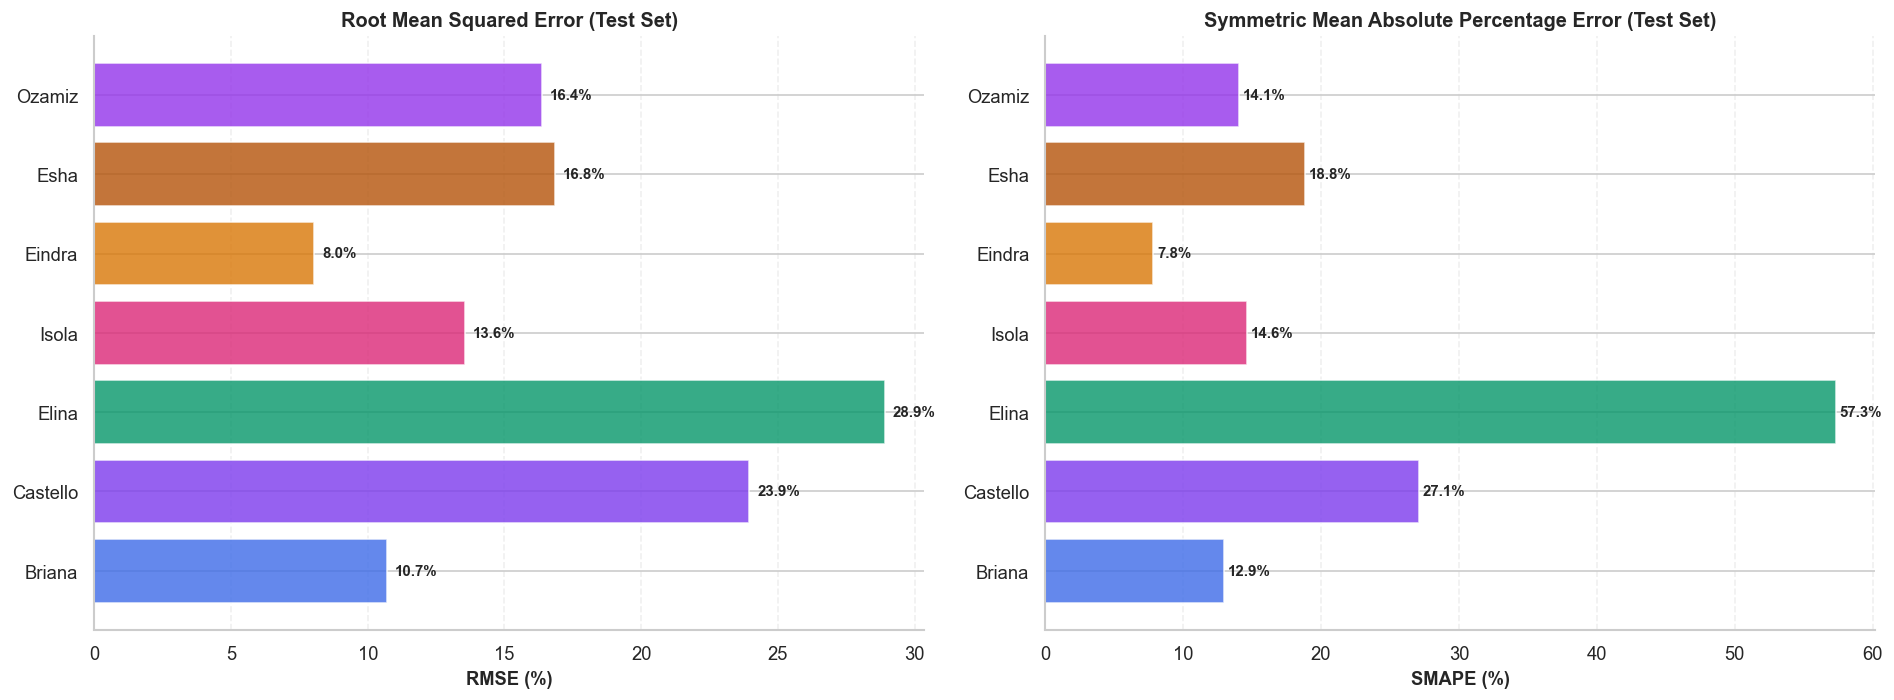


ANALISIS RESIDUAL (Test Set)

[Briana]
  Mean Residual: 2.67% (idealnya mendekati 0)
  Std Residual:  10.36%
  Min Residual:  -13.17%
  Max Residual:  17.27%


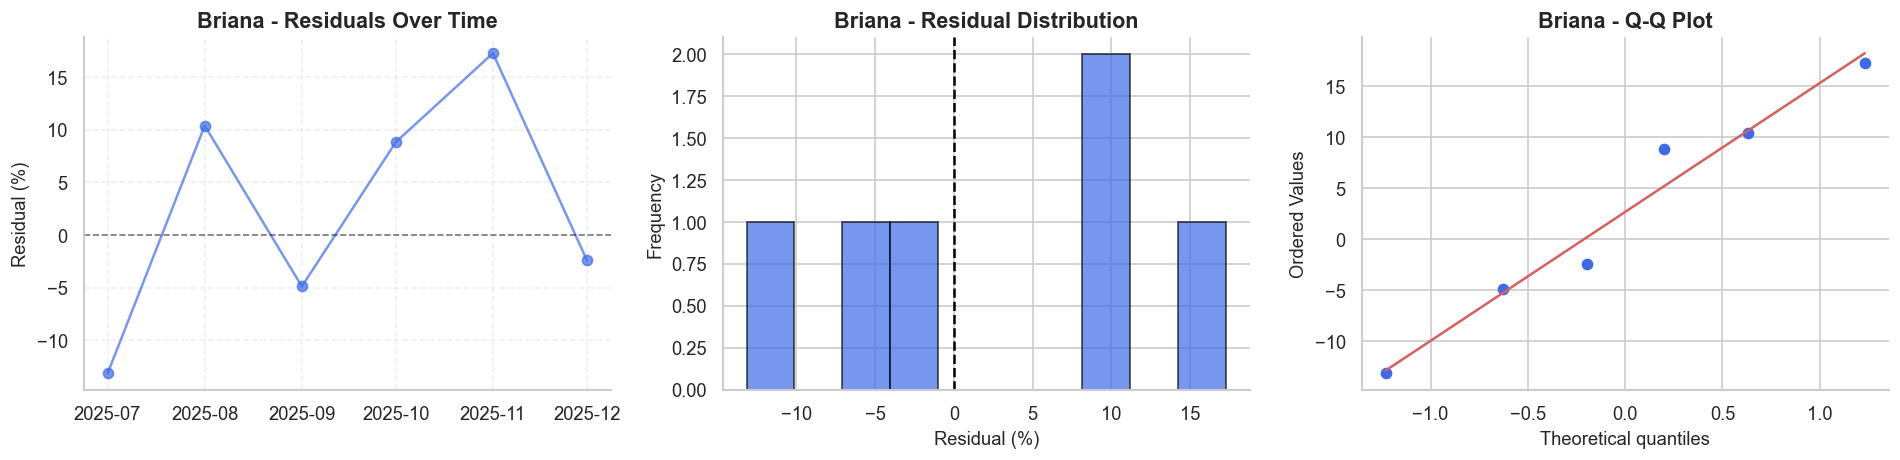


[Castello]
  Mean Residual: -19.19% (idealnya mendekati 0)
  Std Residual:  14.33%
  Min Residual:  -47.96%
  Max Residual:  -3.33%


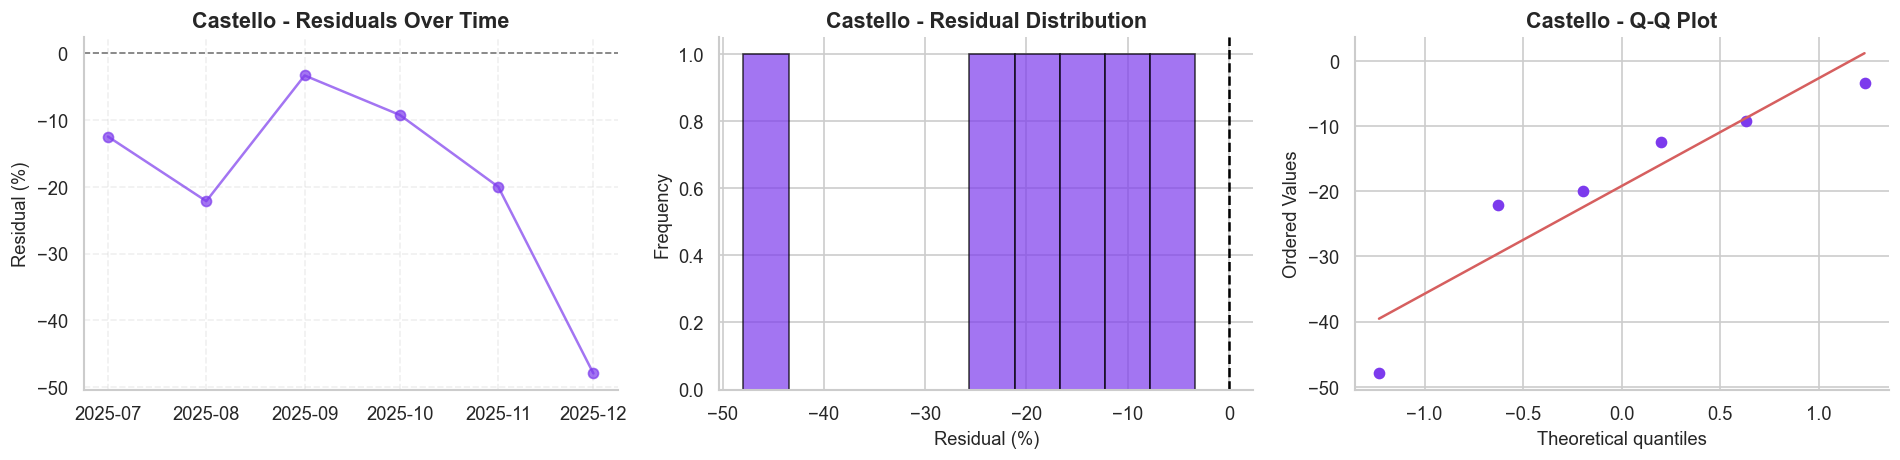


[Elina]
  Mean Residual: 5.86% (idealnya mendekati 0)
  Std Residual:  28.30%
  Min Residual:  -36.99%
  Max Residual:  40.43%


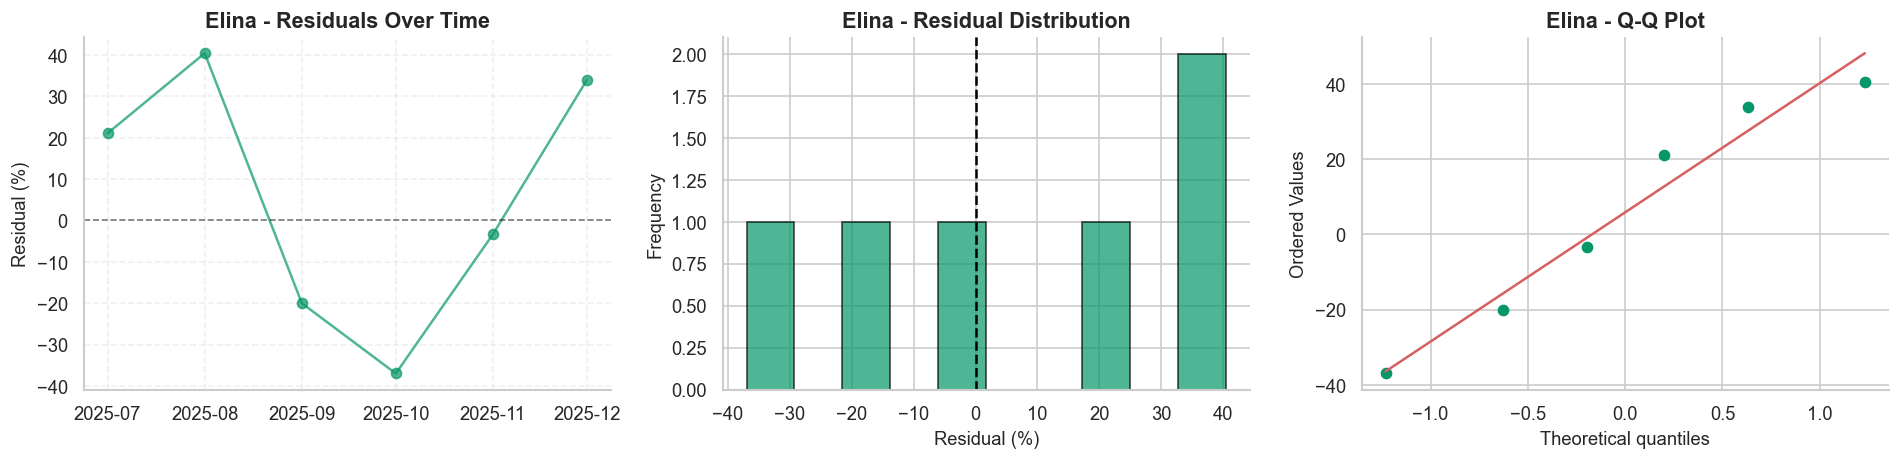


[Isola]
  Mean Residual: -9.55% (idealnya mendekati 0)
  Std Residual:  9.62%
  Min Residual:  -23.89%
  Max Residual:  6.33%


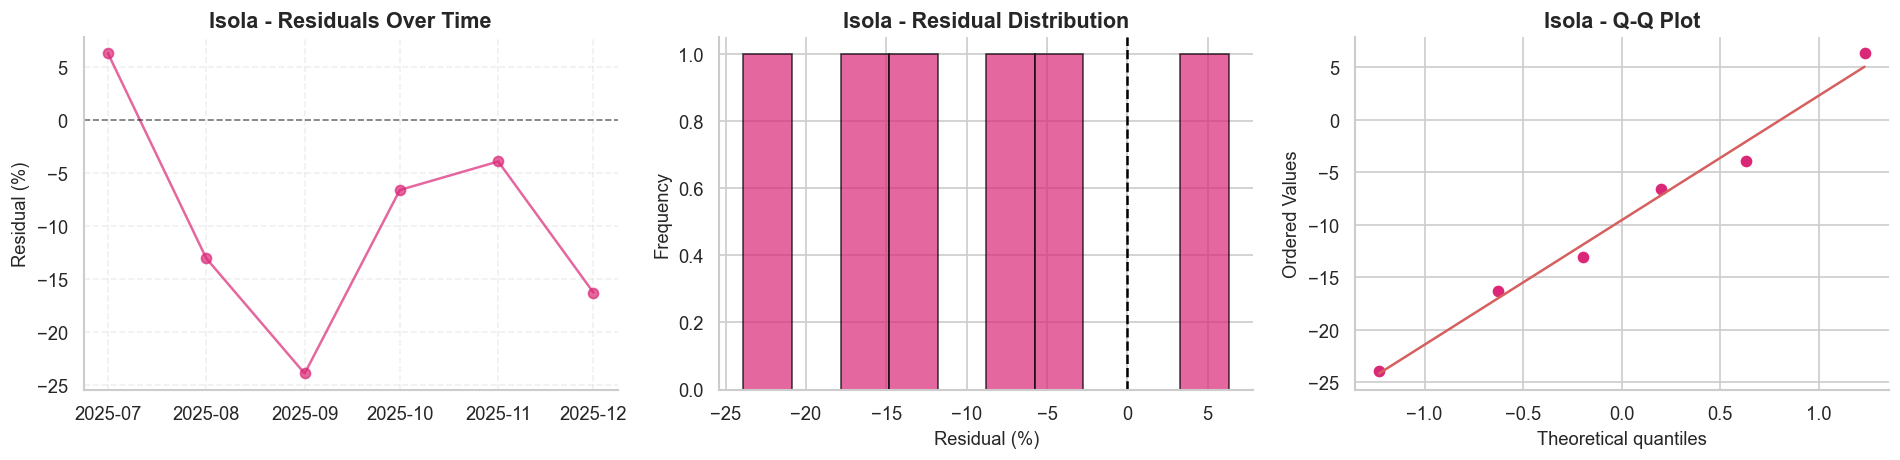


[Eindra]
  Mean Residual: 3.36% (idealnya mendekati 0)
  Std Residual:  7.31%
  Min Residual:  -5.28%
  Max Residual:  15.64%


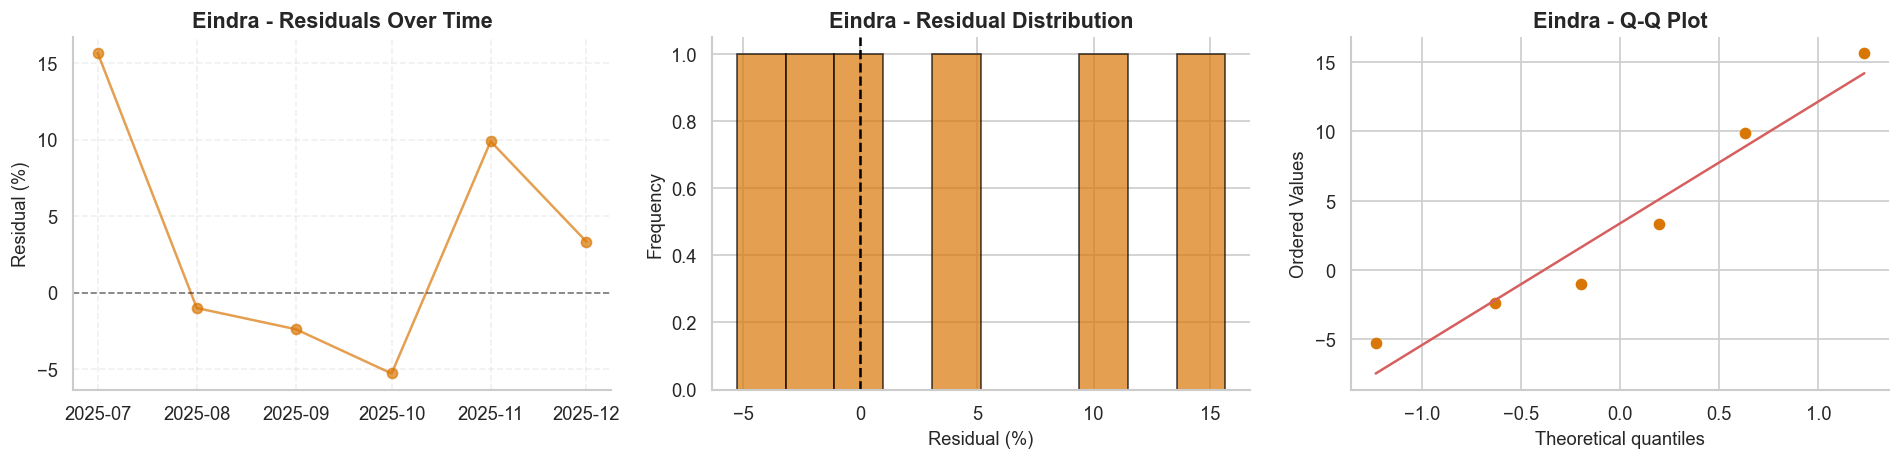


[Esha]
  Mean Residual: 9.75% (idealnya mendekati 0)
  Std Residual:  13.73%
  Min Residual:  -13.45%
  Max Residual:  25.95%


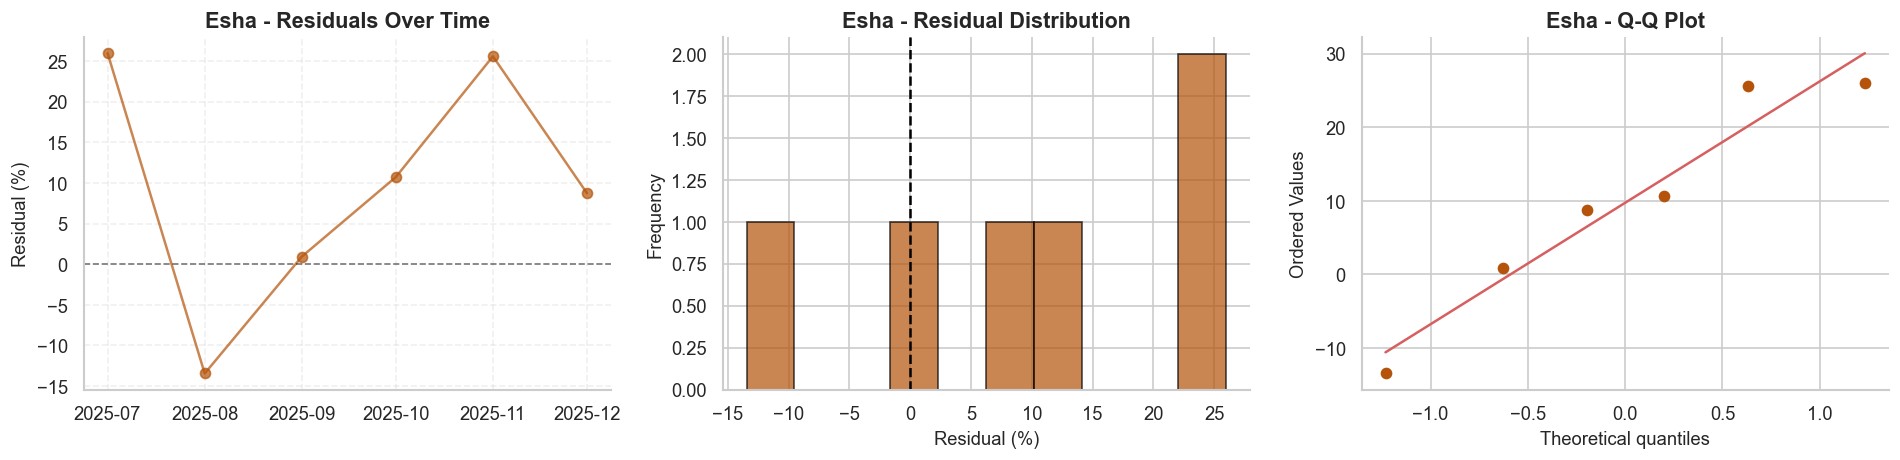


[Ozamiz]
  Mean Residual: -6.97% (idealnya mendekati 0)
  Std Residual:  14.81%
  Min Residual:  -37.35%
  Max Residual:  9.73%


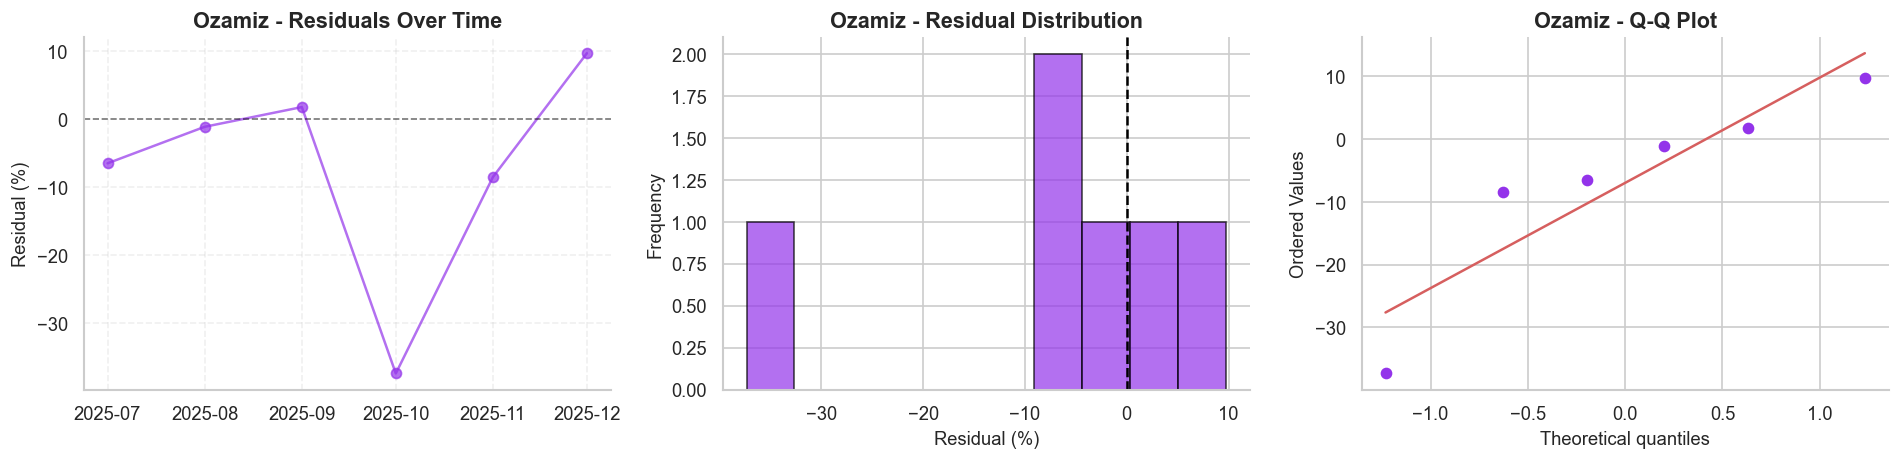


✅ EVALUASI SELESAI!


In [25]:
# ══════════════════════════════════════════════════════════════════════════
# 11. EVALUASI MODEL: RMSE & SMAPE
# ══════════════════════════════════════════════════════════════════════════
#
# Menghitung metrik evaluasi untuk semua villa:
#   [1] RMSE (Root Mean Squared Error) - error dalam satuan %
#   [2] SMAPE (Symmetric Mean Absolute Percentage Error) - error dalam %
#
# Data yang digunakan:
#   - Test set: data yang di-holdout untuk validasi model
#   - Train set: data yang digunakan untuk fitting (opsional, untuk cek overfitting)
# ══════════════════════════════════════════════════════════════════════════

import numpy as np
from sklearn.metrics import mean_squared_error

def calculate_smape(actual, predicted):
    """
    Menghitung SMAPE (Symmetric Mean Absolute Percentage Error)
    
    Parameters:
    -----------
    actual : array-like
        Nilai aktual
    predicted : array-like
        Nilai prediksi
    
    Returns:
    --------
    float : SMAPE dalam persentase (0-100)
    """
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Hindari division by zero
    denominator = (np.abs(actual) + np.abs(predicted)) / 2
    # Jika denominator = 0 (keduanya 0), set ke 1 untuk hindari inf
    denominator = np.where(denominator == 0, 1, denominator)
    
    smape = np.mean(np.abs(actual - predicted) / denominator) * 100
    return smape


def calculate_rmse(actual, predicted):
    """
    Menghitung RMSE (Root Mean Squared Error)
    
    Parameters:
    -----------
    actual : array-like
        Nilai aktual
    predicted : array-like
        Nilai prediksi
    
    Returns:
    --------
    float : RMSE dalam satuan yang sama dengan data
    """
    return np.sqrt(mean_squared_error(actual, predicted))


# ── Hitung metrik untuk semua villa
print('=' * 80)
print('EVALUASI MODEL: RMSE & SMAPE')
print('=' * 80)

metrics_rows = []

for villa, info in sarima_models.items():
    title    = villa.replace('_villas', '').title()
    area     = VILLA_CONFIG[villa]['area'].title()
    order    = info['order']
    s_order  = info['seasonal_order']
    
    # ── Data aktual vs prediksi (TEST SET)
    test_actual = info['test'].values
    test_pred   = info['pred_mean'].values
    
    # ── Hitung metrik pada test set
    rmse_test  = calculate_rmse(test_actual, test_pred)
    smape_test = calculate_smape(test_actual, test_pred)
    
    # ── (Opsional) Hitung metrik pada train set untuk cek overfitting
    train_actual = info['train'].values
    # Fitted values pada train set
    train_fitted = info['model'].fittedvalues.values
    
    rmse_train  = calculate_rmse(train_actual, train_fitted)
    smape_train = calculate_smape(train_actual, train_fitted)
    
    # ── Simpan hasil
    metrics_rows.append({
        'Villa'            : title,
        'Area'             : area,
        'Model'            : f'SARIMA{order}x{s_order}',
        'RMSE (Test)'      : round(rmse_test, 2),
        'SMAPE (Test)'     : round(smape_test, 2),
        'RMSE (Train)'     : round(rmse_train, 2),
        'SMAPE (Train)'    : round(smape_train, 2),
        'Overfit?'         : '⚠️' if (rmse_test > rmse_train * 1.5) else '✅',
    })
    
    print(f'\n[{title}] {area}')
    print(f'  Model: SARIMA{order}x{s_order}')
    print(f'  Test  → RMSE: {rmse_test:.2f}%  |  SMAPE: {smape_test:.2f}%')
    print(f'  Train → RMSE: {rmse_train:.2f}%  |  SMAPE: {smape_train:.2f}%')
    
    # Interpretasi
    if smape_test < 10:
        quality = '🌟 Excellent'
    elif smape_test < 15:
        quality = '✅ Good'
    elif smape_test < 20:
        quality = '⚠️ Fair'
    else:
        quality = '❌ Poor'
    
    print(f'  Kualitas: {quality}')


# ── Buat DataFrame metrik
metrics_df = pd.DataFrame(metrics_rows)

print('\n' + '=' * 80)
print('TABEL RINGKASAN METRIK EVALUASI')
print('=' * 80)
display(metrics_df.set_index('Villa'))

# ── Simpan ke CSV
metrics_df.to_csv('model_evaluation_metrics.csv', index=False)
print(f'\n✅ Tersimpan: model_evaluation_metrics.csv')


# ══════════════════════════════════════════════════════════════════════════
# 12. VISUALISASI PERBANDINGAN METRIK ANTAR VILLA
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: RMSE Test
ax1 = axes[0]
bars1 = ax1.barh(metrics_df['Villa'], metrics_df['RMSE (Test)'], 
                 color=[VILLA_CONFIG[v.lower() + '_villas']['color'] 
                        for v in metrics_df['Villa']], 
                 alpha=0.8)

ax1.set_xlabel('RMSE (%)', fontweight='bold', fontsize=11)
ax1.set_title('Root Mean Squared Error (Test Set)', 
              fontweight='bold', fontsize=12)
ax1.grid(axis='x', alpha=0.3, ls='--')
ax1.spines[['top', 'right']].set_visible(False)

# Anotasi nilai
for i, (villa, val) in enumerate(zip(metrics_df['Villa'], 
                                      metrics_df['RMSE (Test)'])):
    ax1.text(val + 0.3, i, f'{val:.1f}%', 
             va='center', fontsize=9, fontweight='bold')

# ── Plot 2: SMAPE Test
ax2 = axes[1]
bars2 = ax2.barh(metrics_df['Villa'], metrics_df['SMAPE (Test)'], 
                 color=[VILLA_CONFIG[v.lower() + '_villas']['color'] 
                        for v in metrics_df['Villa']], 
                 alpha=0.8)

ax2.set_xlabel('SMAPE (%)', fontweight='bold', fontsize=11)
ax2.set_title('Symmetric Mean Absolute Percentage Error (Test Set)', 
              fontweight='bold', fontsize=12)
ax2.grid(axis='x', alpha=0.3, ls='--')
ax2.spines[['top', 'right']].set_visible(False)

# Anotasi nilai
for i, (villa, val) in enumerate(zip(metrics_df['Villa'], 
                                      metrics_df['SMAPE (Test)'])):
    ax2.text(val + 0.3, i, f'{val:.1f}%', 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════════
# 13. ANALISIS RESIDUAL & DIAGNOSTIC PLOTS
# ══════════════════════════════════════════════════════════════════════════

print('\n' + '=' * 80)
print('ANALISIS RESIDUAL (Test Set)')
print('=' * 80)

for villa, info in sarima_models.items():
    title = villa.replace('_villas', '').title()
    color = VILLA_CONFIG[villa]['color']
    
    # Hitung residual
    test_actual = info['test'].values
    test_pred   = info['pred_mean'].values
    residuals   = test_actual - test_pred
    
    print(f'\n[{title}]')
    print(f'  Mean Residual: {np.mean(residuals):.2f}% (idealnya mendekati 0)')
    print(f'  Std Residual:  {np.std(residuals):.2f}%')
    print(f'  Min Residual:  {np.min(residuals):.2f}%')
    print(f'  Max Residual:  {np.max(residuals):.2f}%')
    
    # Plot residual
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Plot 1: Residual over time
    axes[0].plot(info['test'].index, residuals, 
                 color=color, marker='o', lw=1.5, alpha=0.7)
    axes[0].axhline(0, color='black', ls='--', lw=1, alpha=0.5)
    axes[0].set_title(f'{title} - Residuals Over Time', fontweight='bold')
    axes[0].set_ylabel('Residual (%)')
    axes[0].grid(alpha=0.3, ls='--')
    axes[0].spines[['top', 'right']].set_visible(False)
    
    # Plot 2: Histogram residual
    axes[1].hist(residuals, bins=10, color=color, alpha=0.7, edgecolor='black')
    axes[1].axvline(0, color='black', ls='--', lw=1.5)
    axes[1].set_title(f'{title} - Residual Distribution', fontweight='bold')
    axes[1].set_xlabel('Residual (%)')
    axes[1].set_ylabel('Frequency')
    axes[1].spines[['top', 'right']].set_visible(False)
    
    # Plot 3: Q-Q plot
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[2])
    axes[2].set_title(f'{title} - Q-Q Plot', fontweight='bold')
    axes[2].get_lines()[0].set_color(color)
    axes[2].get_lines()[0].set_markersize(6)
    axes[2].spines[['top', 'right']].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'residual_analysis_{villa}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('\n' + '=' * 80)
print('✅ EVALUASI SELESAI!')
print('=' * 80)

In [15]:
# Debug cell — tambahkan setelah cell 20
for villa, info in sarima_models.items():
    monthly = info['monthly']
    print(f"\n[{villa}]")
    print(f"  monthly head: {monthly.head(3).values.tolist()}")
    print(f"  monthly tail: {monthly.tail(3).values.tolist()}")
    print(f"  d={info['d']}  m={info['m']}")
    print(f"  order={info['order']}  seasonal={info['seasonal_order']}")
    print(f"  AIC={info['model'].aic:.2f}")
    print(f"  MAE={info['mae']:.4f}  sMAPE={info['smape']:.4f}")


[briana_villas]
  monthly head: [61.29032258064516, 50.0, 61.29032258064516]
  monthly tail: [80.64516129032258, 90.0, 70.96774193548387]
  d=1  m=7
  order=(1, 1, 1)  seasonal=(1, 0, 0, 7)
  AIC=170.25
  MAE=9.4915  sMAPE=12.9449

[castello_villas]
  monthly head: [0.0, 0.0, 0.0]
  monthly tail: [77.41935483870968, 66.66666666666667, 38.70967741935484]
  d=1  m=18
  order=(0, 1, 0)  seasonal=(0, 0, 0, 18)
  AIC=270.76
  MAE=19.1935  sMAPE=27.0986

[elina_villas]
  monthly head: [96.7741935483871, 0.0, 0.0]
  monthly tail: [9.67741935483871, 43.333333333333336, 80.64516129032258]
  d=1  m=4
  order=(0, 1, 0)  seasonal=(0, 0, 0, 4)
  AIC=284.44
  MAE=25.9677  sMAPE=57.3202

[isola_villas]
  monthly head: [0.0, 0.0, 0.0]
  monthly tail: [80.64516129032258, 83.33333333333333, 70.96774193548387]
  d=1  m=18
  order=(0, 1, 1)  seasonal=(0, 0, 0, 18)
  AIC=245.86
  MAE=11.6606  sMAPE=14.6371

[eindra_villas]
  monthly head: [54.83870967741935, 28.571428571428573, 45.16129032258065]
  monthl

---
## 11. Diagnostik Residual — Ljung-Box Test
Residual model yang baik harus: **tidak berkorelasi** (Ljung-Box p > 0.05), **mendekati normal** (Q-Q lurus).

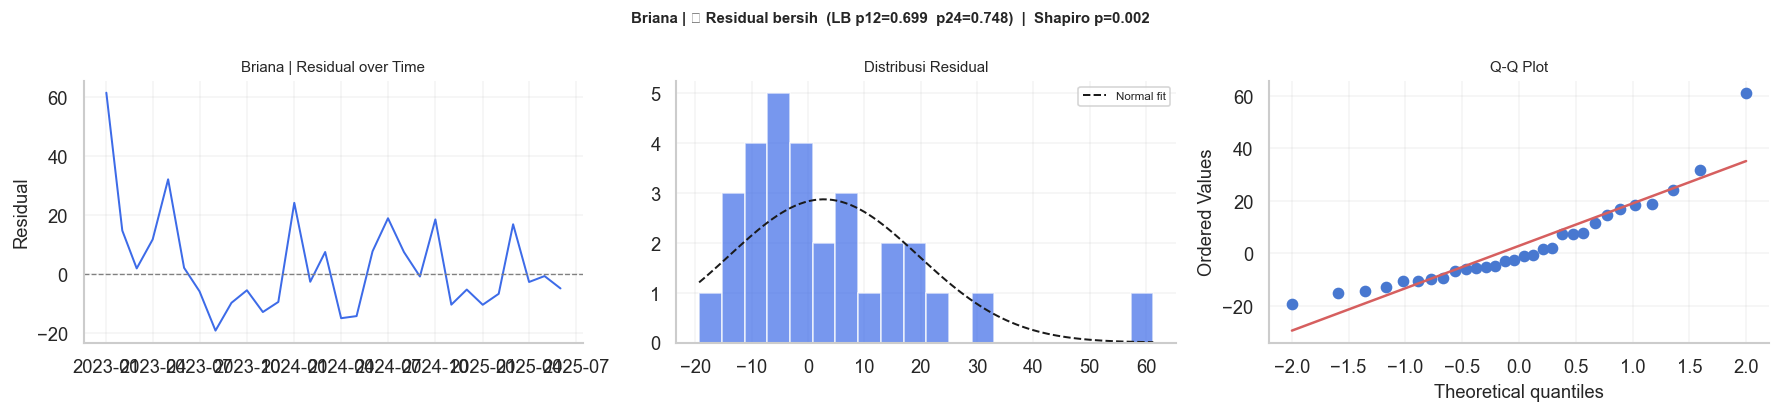

  [Briana] ✅ Residual bersih  |  Normalitas: ⚠️


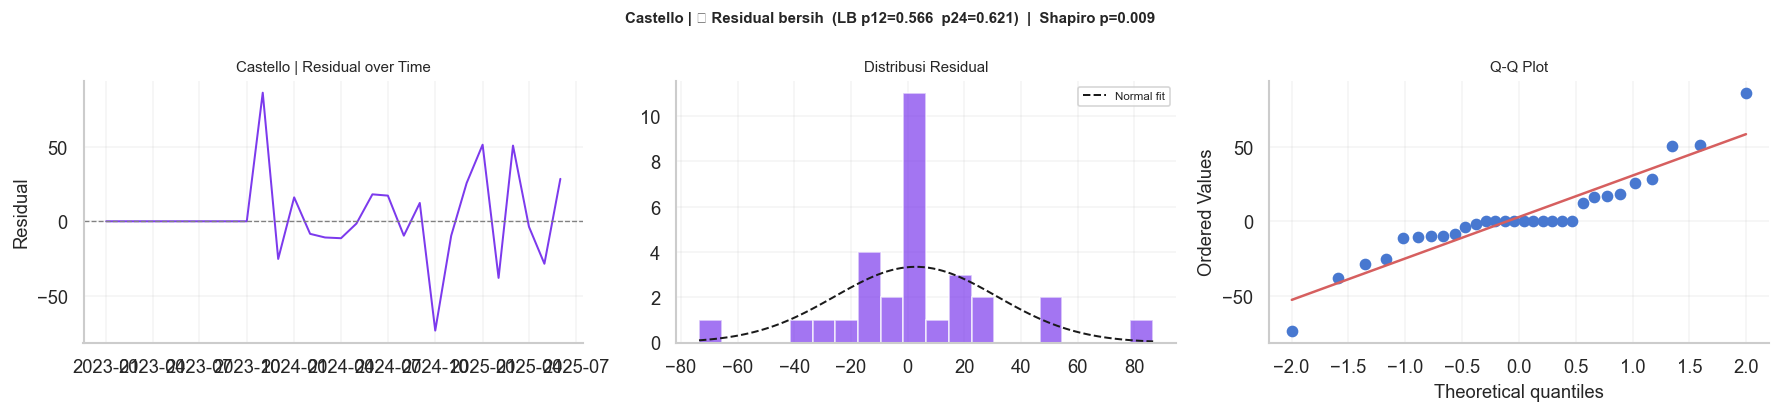

  [Castello] ✅ Residual bersih  |  Normalitas: ⚠️


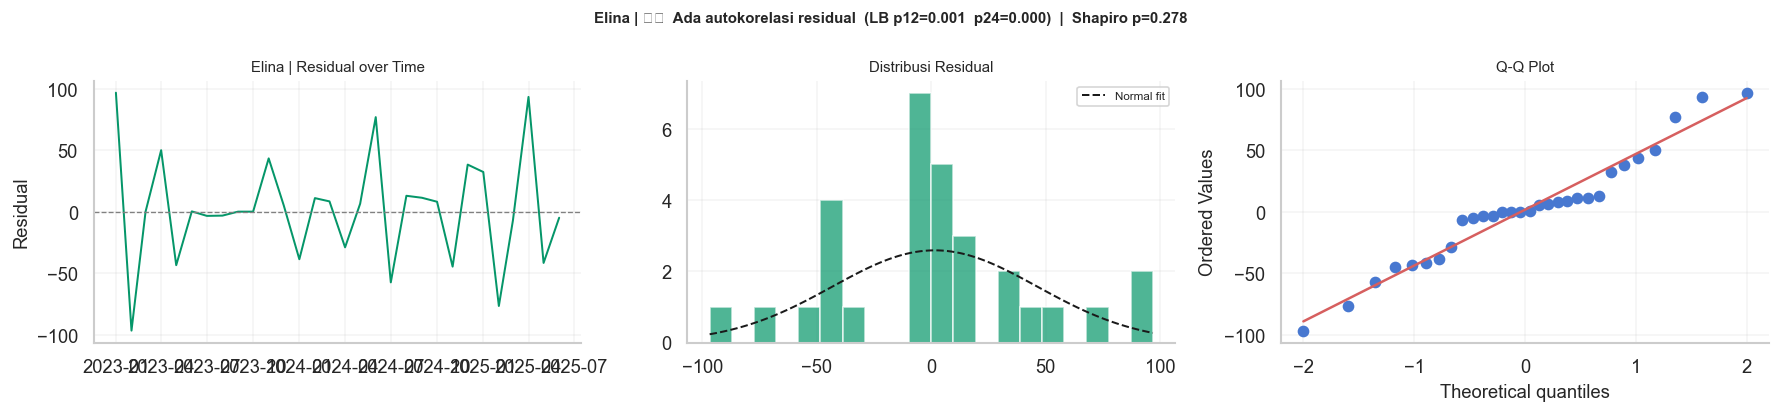

  [Elina] ⚠️  Ada autokorelasi residual  |  Normalitas: ✅


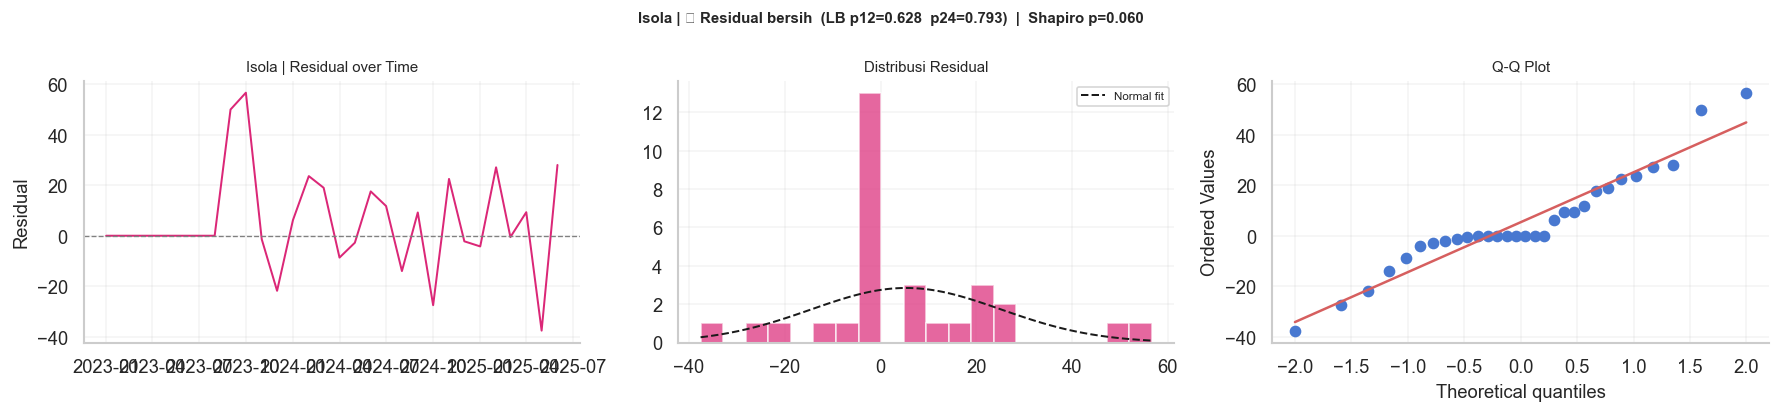

  [Isola] ✅ Residual bersih  |  Normalitas: ✅


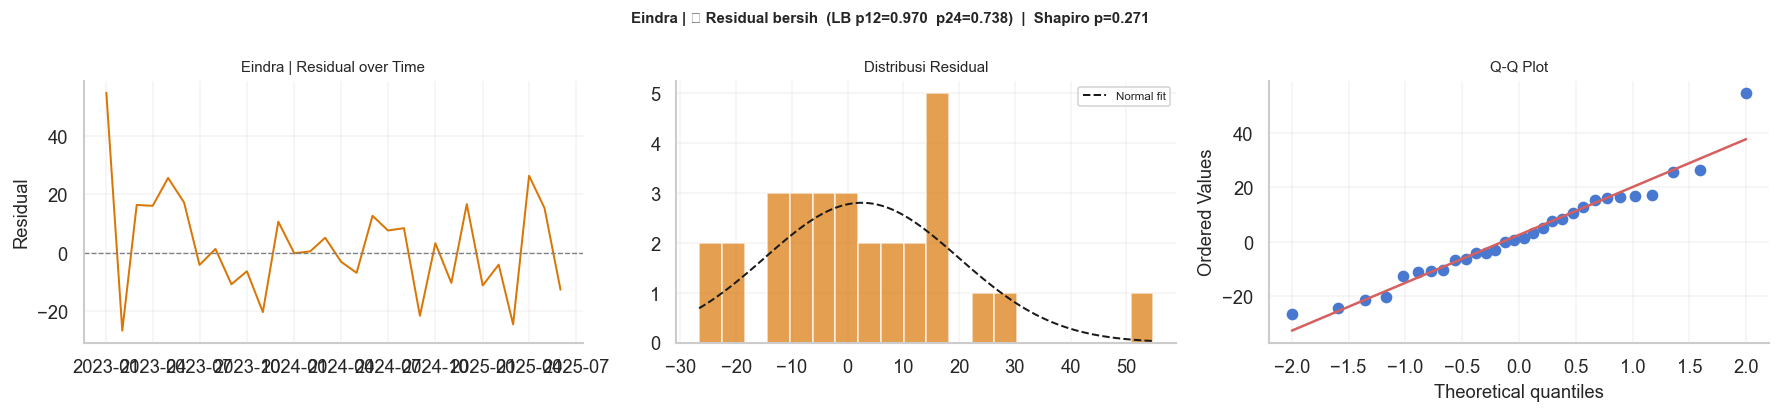

  [Eindra] ✅ Residual bersih  |  Normalitas: ✅


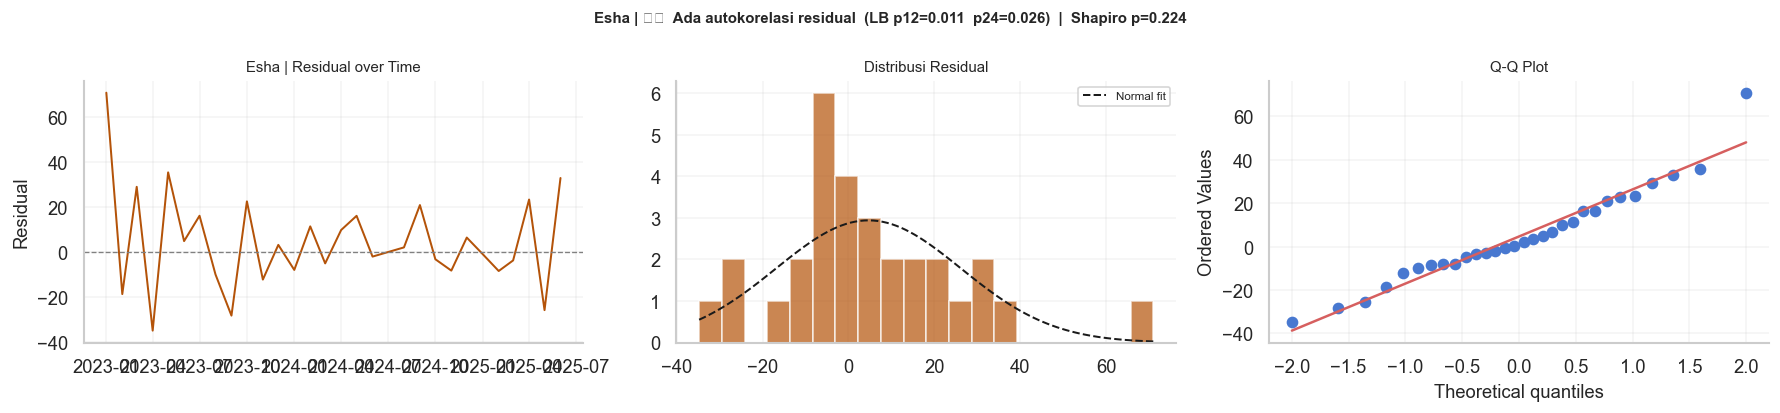

  [Esha] ⚠️  Ada autokorelasi residual  |  Normalitas: ✅


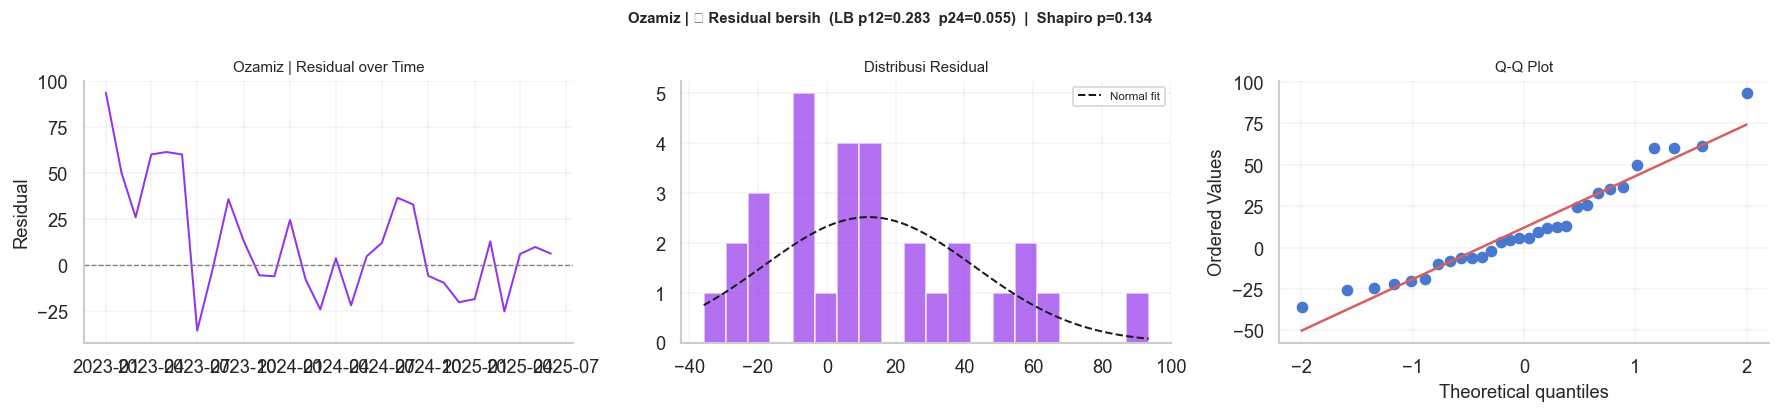

  [Ozamiz] ✅ Residual bersih  |  Normalitas: ✅

RINGKASAN DIAGNOSTIK RESIDUAL


,Villa,Order,Forecast Flat?,LB p(lag12),LB p(lag24),Ljung-Box,Shapiro p,Normalitas
0,Briana,"SARIMA(1, 1, 1)x(1, 0, 0, 7)",✅,0.70,0.75,✅ Residual bersih,0.00,⚠️ Non-normal
1,Castello,"SARIMA(0, 1, 0)x(0, 0, 0, 18)",✅,0.57,0.62,✅ Residual bersih,0.01,⚠️ Non-normal
2,Elina,"SARIMA(0, 1, 0)x(0, 0, 0, 4)",✅,0.00,0.00,⚠️ Ada autokorelasi residual,0.28,✅ Normal
3,Isola,"SARIMA(0, 1, 1)x(0, 0, 0, 18)",✅,0.63,0.79,✅ Residual bersih,0.06,✅ Normal
4,Eindra,"SARIMA(1, 0, 1)x(0, 0, 0, 0)",✅,0.97,0.74,✅ Residual bersih,0.27,✅ Normal
5,Esha,"SARIMA(1, 0, 0)x(0, 0, 0, 12)",✅,0.01,0.03,⚠️ Ada autokorelasi residual,0.22,✅ Normal
6,Ozamiz,"SARIMA(0, 0, 0)x(1, 0, 1, 6)",✅,0.28,0.05,✅ Residual bersih,0.13,✅ Normal



Panduan baca:
  Ljung-Box p > 0.05  → residual tidak berkorelasi → model sudah menangkap pola ✅
  Ljung-Box p ≤ 0.05  → masih ada pola di residual → model perlu review ⚠️
  Shapiro   p > 0.05  → residual mendekati normal ✅
  Forecast Flat ⚠️    → meski residual OK, prediksi tidak bervariansi — lihat cell 10



In [16]:
# ── 11. DIAGNOSTIK RESIDUAL — Ljung-Box + plot
# Pakai model_full (refit seluruh data + seasonal order final dari cell 10)

diag_results = []

for villa, info in sarima_models.items():
    # ── Ambil model final (sudah include retry seasonal dari cell 10)
    fitted = info.get('model_full', info['model'])   # fallback ke model train jika cell 10 belum run
    order    = info['order']
    s_order  = info['seasonal_order']                # sudah diupdate di cell 10
    is_flat  = info.get('is_flat', False)
    title    = villa.replace('_villas', '').title()
    color    = VILLA_CONFIG[villa]['color']
    resid    = fitted.resid.dropna()

    # Ljung-Box test
    lb     = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
    p12    = lb.loc[12, 'lb_pvalue']
    p24    = lb.loc[24, 'lb_pvalue']
    lb_ok  = p12 > 0.05
    status = '✅ Residual bersih' if lb_ok else '⚠️  Ada autokorelasi residual'

    # Shapiro-Wilk normalitas (max 50 obs)
    _, p_norm = stats.shapiro(resid[:50])
    norm_ok   = p_norm > 0.05

    diag_results.append({
        'Villa'          : title,
        'Order'          : f'SARIMA{order}x{s_order}',
        'Forecast Flat?' : '⚠️' if is_flat else '✅',
        'LB p(lag12)'    : round(p12, 4),
        'LB p(lag24)'    : round(p24, 4),
        'Ljung-Box'      : status,
        'Shapiro p'      : round(p_norm, 4),
        'Normalitas'     : '✅ Normal' if norm_ok else '⚠️ Non-normal',
    })

    # ── Plot residual (3 panel)
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

    # Panel 1: residual over time
    axes[0].plot(resid.index, resid.values,
                 color=color if not is_flat else '#E24B4A', lw=1.2)
    axes[0].axhline(0, color='gray', ls='--', lw=0.8)
    axes[0].set_title(f'{title} | Residual over Time', fontsize=9)
    axes[0].set_ylabel('Residual')

    # Panel 2: histogram + kurva normal
    axes[1].hist(resid, bins=20, color=color, alpha=0.7, edgecolor='white')
    mu, std_r = resid.mean(), resid.std()
    x_r = np.linspace(resid.min(), resid.max(), 100)
    axes[1].plot(x_r,
                 stats.norm.pdf(x_r, mu, std_r) * len(resid)
                 * (resid.max() - resid.min()) / 20,
                 'k--', lw=1.2, label='Normal fit')
    axes[1].set_title('Distribusi Residual', fontsize=9)
    axes[1].legend(fontsize=7)

    # Panel 3: Q-Q plot
    stats.probplot(resid, dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q Plot', fontsize=9)

    for ax in axes:
        ax.grid(alpha=0.2)
        ax.spines[['top', 'right']].set_visible(False)

    # Judul dengan status flat
    flat_note = '  |  ⚠️ Forecast flat' if is_flat else ''
    plt.suptitle(
        f'{title} | {status}  (LB p12={p12:.3f}  p24={p24:.3f})'
        f'  |  Shapiro p={p_norm:.3f}{flat_note}',
        fontsize=9, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'residual_{villa}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  [{title}] {status}  |  Normalitas: {"✅" if norm_ok else "⚠️"}')

# ── Tabel ringkasan diagnostik
print('\nRINGKASAN DIAGNOSTIK RESIDUAL')
print('=' * 80)
diag_df = pd.DataFrame(diag_results)
display(diag_df)

print("""
Panduan baca:
  Ljung-Box p > 0.05  → residual tidak berkorelasi → model sudah menangkap pola ✅
  Ljung-Box p ≤ 0.05  → masih ada pola di residual → model perlu review ⚠️
  Shapiro   p > 0.05  → residual mendekati normal ✅
  Forecast Flat ⚠️    → meski residual OK, prediksi tidak bervariansi — lihat cell 10
""")

---
## 12. Load & Bersihkan Data Finansial
Data finansial (`*_daily_financial.csv`) di-load dari path yang sama dengan data occupancy.

In [17]:
# ── 12a. LOAD DATA FINANSIAL
clean_fin = {}   # {villa: pd.Series monthly revenue}

for villa, config in VILLA_CONFIG.items():
    area = config['area']
    path = build_path(area, villa, 'financial')
    df   = load_raw(path)
    if df is None:
        print(f'⚠️  [{villa}] File finansial tidak ditemukan: {path}')
        continue

    df_c      = df.copy()
    date_cands= [c for c in df_c.columns if any(k in c.lower() for k in ['date','tanggal','tgl'])]
    date_col  = date_cands[0] if date_cands else df_c.columns[0]
    df_c[date_col] = parse_villa_date(df_c[date_col])
    df_c = df_c.dropna(subset=[date_col]).set_index(date_col).sort_index()

    rev_kw  = ['revenue','pendapatan','income','total','gross','nett','net',
               'adr','rate','harga','price','amount','jumlah']
    rev_col = next((c for c in df_c.columns if any(k in c.lower() for k in rev_kw)), None)

    if rev_col:
        df_c['revenue'] = parse_numeric(df_c[rev_col])
        monthly_rev     = df_c['revenue'].resample('MS').sum().rename('revenue')
        monthly_rev     = monthly_rev[monthly_rev > 0]   # drop bulan kosong/nol
        clean_fin[villa]= monthly_rev
        print(f'✅ [{villa}]  kolom: "{rev_col}"  |  {len(monthly_rev)} bulan  '
              f'|  mean = Rp {monthly_rev.mean():,.0f}')
    else:
        avail = [c for c in df_c.columns][:10]
        print(f'⚠️  [{villa}] Kolom revenue tidak terdeteksi. Kolom tersedia: {avail}')

print(f'\n✅ Total: {len(clean_fin)} villa berhasil load data finansial.')


✅ [briana_villas]  kolom: "Room Revenue IDR"  |  36 bulan  |  mean = Rp 39,905,298
✅ [castello_villas]  kolom: "Room Revenue IDR"  |  22 bulan  |  mean = Rp 18,764,624
✅ [elina_villas]  kolom: "Room Revenue IDR"  |  14 bulan  |  mean = Rp 41,551,428
✅ [isola_villas]  kolom: "Room Revenue IDR"  |  22 bulan  |  mean = Rp 16,493,288
✅ [eindra_villas]  kolom: "Room Revenue IDR"  |  36 bulan  |  mean = Rp 115,400,957
✅ [esha_villas]  kolom: "Room Revenue IDR"  |  35 bulan  |  mean = Rp 53,942,115
✅ [ozamiz_villas]  kolom: "Room Revenue IDR"  |  32 bulan  |  mean = Rp 68,721,762

✅ Total: 7 villa berhasil load data finansial.


In [18]:
# ── 12b. STATISTIK DESKRIPTIF FINANSIAL
if clean_fin:
    fin_stats = []
    for villa, rev in clean_fin.items():
        fin_stats.append({
            'Villa'          : villa.replace('_villas','').title(),
            'Area'           : VILLA_CONFIG[villa]['area'].title(),
            'N (bulan)'      : len(rev),
            'Total Revenue'  : f'Rp {rev.sum():>15,.0f}',
            'Rata-rata/bln'  : f'Rp {rev.mean():>12,.0f}',
            'Std Dev'        : f'Rp {rev.std():>12,.0f}',
            'Minimum'        : f'Rp {rev.min():>12,.0f}',
            'Maksimum'       : f'Rp {rev.max():>12,.0f}',
            'Median'         : f'Rp {rev.median():>12,.0f}',
        })
    print('STATISTIK DESKRIPTIF — REVENUE BULANAN')
    print('='*90)
    display(pd.DataFrame(fin_stats))
else:
    print('⚠️  Tidak ada data finansial.')


STATISTIK DESKRIPTIF — REVENUE BULANAN


,Villa,Area,N (bulan),Total Revenue,Rata-rata/bln,Std Dev,Minimum,Maksimum,Median
0,Briana,Canggu,36,"Rp 1,436,590,737","Rp 39,905,298","Rp 17,339,415","Rp 6,719,894","Rp 76,475,970","Rp 42,747,636"
1,Castello,Canggu,22,"Rp 412,821,727","Rp 18,764,624","Rp 10,222,024","Rp 3,916,666","Rp 42,997,555","Rp 17,191,424"
2,Elina,Canggu,14,"Rp 581,719,992","Rp 41,551,428","Rp 28,074,291","Rp 10,000,000","Rp 117,020,638","Rp 33,673,613"
3,Isola,Canggu,22,"Rp 362,852,335","Rp 16,493,288","Rp 13,518,083","Rp 1,453,500","Rp 50,244,917","Rp 12,623,917"
4,Eindra,Seminyak,36,"Rp 4,154,434,440","Rp 115,400,957","Rp 45,406,082","Rp 24,122,697","Rp 239,344,918","Rp 121,406,871"
5,Esha,Seminyak,35,"Rp 1,887,974,042","Rp 53,942,115","Rp 25,621,714","Rp 6,000,000","Rp 130,428,174","Rp 50,477,144"
6,Ozamiz,Seminyak,32,"Rp 2,199,096,383","Rp 68,721,762","Rp 35,735,005","Rp 7,850,968","Rp 153,100,060","Rp 67,131,178"


---
## 13. Keterkaitan Deskriptif: Occupancy ↔ Revenue
### 13a. Korelasi Pearson & Scatter Plot

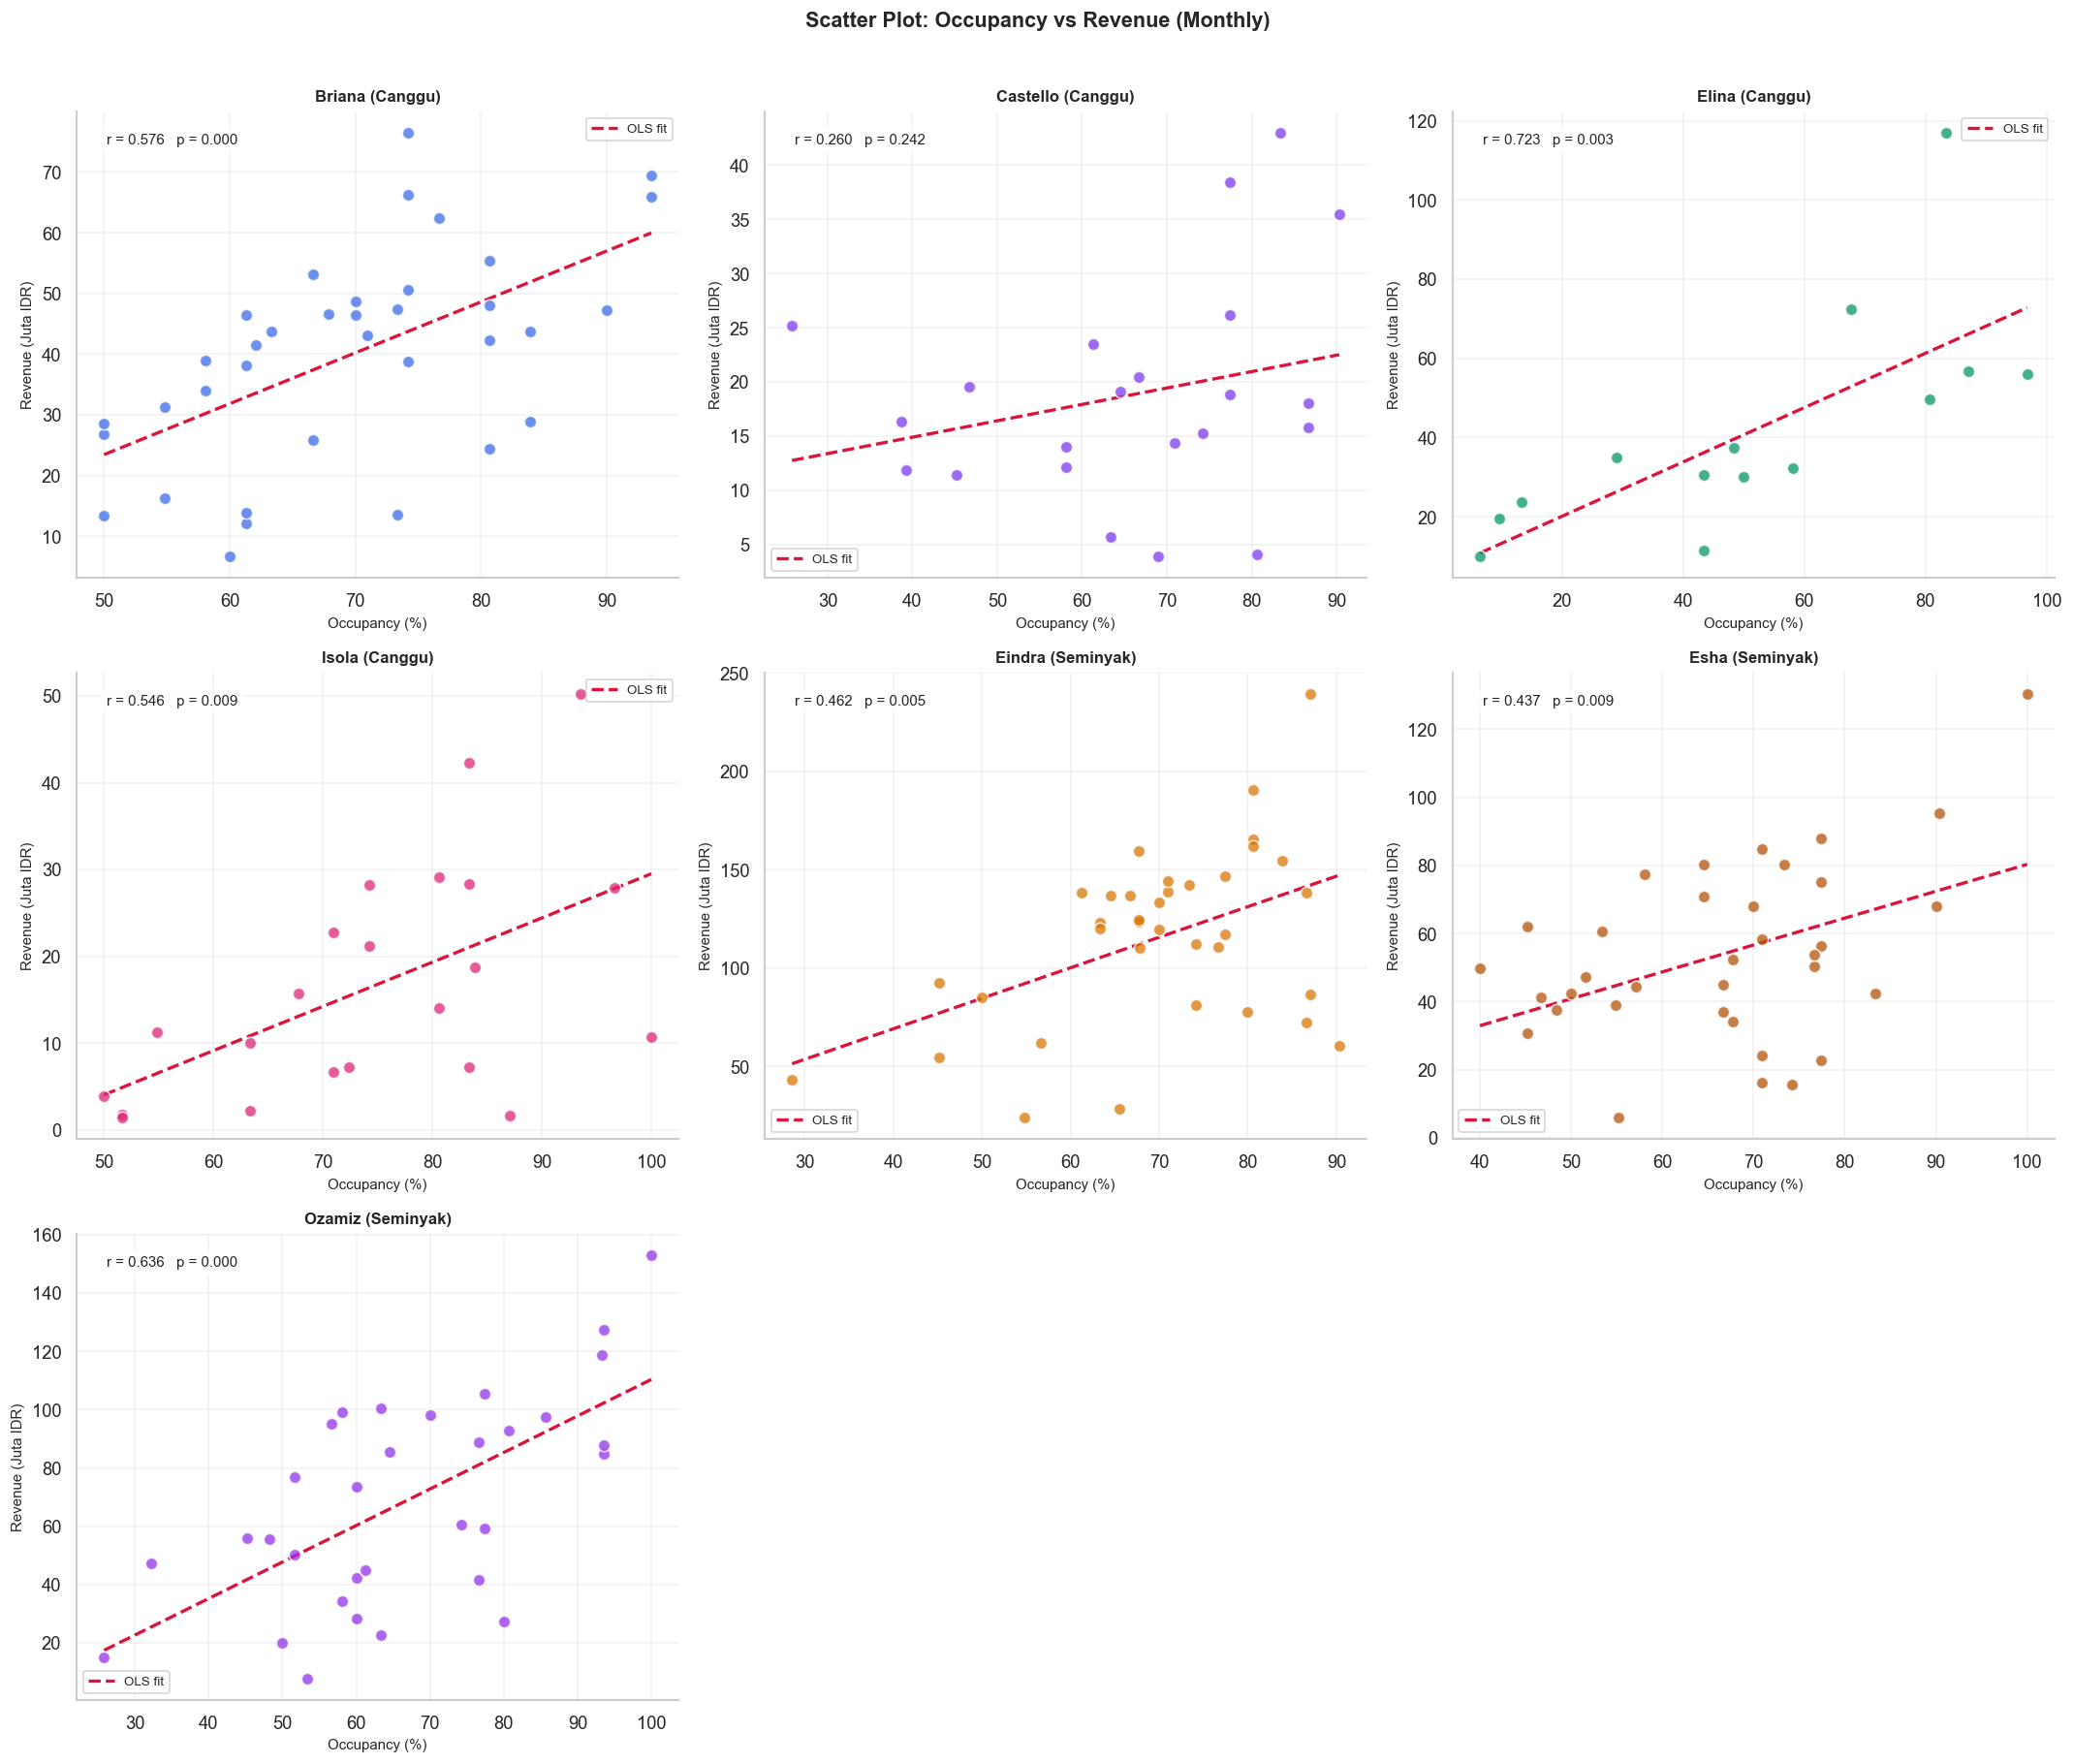


KORELASI PEARSON — OCCUPANCY vs REVENUE


,Villa,Area,N (bulan),Pearson r,p-value,Interpretasi
0,Briana,Canggu,36,0.58,0.00,🟢 Kuat Positif
1,Castello,Canggu,22,0.26,0.24,🟡 Lemah/Tidak Sig.
2,Elina,Canggu,14,0.72,0.00,🟢 Kuat Positif
3,Isola,Canggu,22,0.55,0.01,🟢 Kuat Positif
4,Eindra,Seminyak,36,0.46,0.00,🟡 Lemah/Tidak Sig.
5,Esha,Seminyak,35,0.44,0.01,🟡 Lemah/Tidak Sig.
6,Ozamiz,Seminyak,32,0.64,0.00,🟢 Kuat Positif


In [19]:
# ── 13a. SCATTER PLOT + KORELASI PEARSON
if clean_fin:
    available = [v for v in clean_fin if v in clean_occ]
    ncols     = min(3, len(available))
    nrows     = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes_flat = np.array(axes).flatten() if len(available) > 1 else [axes]

    corr_results = []
    for ax, villa in zip(axes_flat, available):
        color  = VILLA_CONFIG[villa]['color']
        title  = villa.replace('_villas','').title()
        occ_m  = clean_occ[villa].resample('MS').mean().rename('occupancy')
        comb   = pd.concat([occ_m, clean_fin[villa]], axis=1).dropna()

        if len(comb) < 6:
            ax.set_visible(False)
            continue

        r, p = stats.pearsonr(comb['occupancy'], comb['revenue'])
        corr_results.append({
            'Villa'          : title,
            'Area'           : VILLA_CONFIG[villa]['area'].title(),
            'N (bulan)'      : len(comb),
            'Pearson r'      : round(r, 4),
            'p-value'        : round(p, 4),
            'Interpretasi'   : (
                '🔴 Kuat Negatif' if r <= -0.5 and p < 0.05 else
                '🟢 Kuat Positif' if r >= 0.5  and p < 0.05 else
                '🟡 Lemah/Tidak Sig.'
            ),
        })

        rev_m = comb['revenue'] / 1e6
        ax.scatter(comb['occupancy'], rev_m, color=color, alpha=0.75,
                   edgecolors='white', s=55, zorder=3)

        # Regresi linier
        m, b  = np.polyfit(comb['occupancy'], rev_m, 1)
        x_line= np.linspace(comb['occupancy'].min(), comb['occupancy'].max(), 100)
        ax.plot(x_line, m * x_line + b, color='crimson', lw=2, ls='--', label='OLS fit')

        # Annotasi r
        ax.text(0.05, 0.93, f'r = {r:.3f}   p = {p:.3f}',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

        ax.set_title(f'{title} ({VILLA_CONFIG[villa]["area"].title()})',
                     fontweight='bold', fontsize=10)
        ax.set_xlabel('Occupancy (%)', fontsize=9)
        ax.set_ylabel('Revenue (Juta IDR)', fontsize=9)
        ax.grid(alpha=0.25)
        ax.spines[['top','right']].set_visible(False)
        ax.legend(fontsize=8)

    # Hide extra axes
    for ax in axes_flat[len(available):]:
        ax.set_visible(False)

    plt.suptitle('Scatter Plot: Occupancy vs Revenue (Monthly)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('scatter_occ_revenue.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nKORELASI PEARSON — OCCUPANCY vs REVENUE')
    print('='*75)
    display(pd.DataFrame(corr_results))
else:
    print('⚠️  Skip — data finansial tidak tersedia.')


### 13b. Lag Correlation — Apakah Occupancy Memprediksi Revenue Bulan Depan?

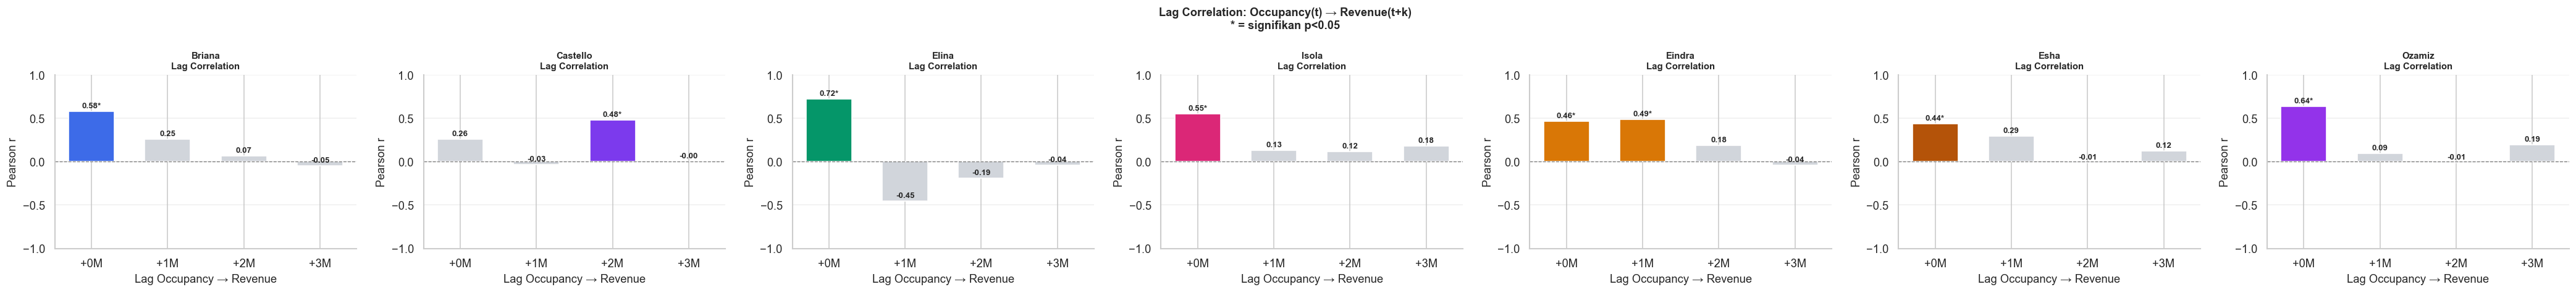


TABEL LAG CORRELATION


,Villa,Lag (bulan),Pearson r,p-value,Signifikan?
0,Briana,+0M,0.58,0.00,✅
1,Briana,+1M,0.25,0.14,—
2,Briana,+2M,0.07,0.71,—
3,Briana,+3M,-0.05,0.79,—
4,Castello,+0M,0.26,0.24,—
5,Castello,+1M,-0.03,0.88,—
6,Castello,+2M,0.48,0.03,✅
7,Castello,+3M,-0.00,1.00,—
8,Elina,+0M,0.72,0.00,✅
9,Elina,+1M,-0.45,0.12,—



Interpretasi: r positif & signifikan → occupancy bulan ke-t
memprediksi revenue bulan ke-t+k dengan korelasi positif.


In [20]:
# ── 13b. LAG CORRELATION: Occupancy(t) → Revenue(t+k), k = 0..3
if clean_fin:
    available = [v for v in clean_fin if v in clean_occ]
    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4))
    if len(available) == 1:
        axes = [axes]

    all_lag_rows = []
    for ax, villa in zip(axes, available):
        color  = VILLA_CONFIG[villa]['color']
        title  = villa.replace('_villas','').title()
        occ_m  = clean_occ[villa].resample('MS').mean().rename('occupancy')
        comb   = pd.concat([occ_m, clean_fin[villa]], axis=1).dropna()

        lags, rs, ps = [], [], []
        for lag in range(0, 4):
            rev_shifted = comb['revenue'].shift(-lag)
            valid       = pd.concat([comb['occupancy'], rev_shifted], axis=1).dropna()
            if len(valid) < 6:
                continue
            r, p = stats.pearsonr(valid['occupancy'], valid.iloc[:,1])
            lags.append(lag)
            rs.append(round(r, 4))
            ps.append(round(p, 4))
            all_lag_rows.append({
                'Villa'       : title,
                'Lag (bulan)' : f'+{lag}M',
                'Pearson r'   : round(r, 4),
                'p-value'     : round(p, 4),
                'Signifikan?' : '✅' if p < 0.05 else '—',
            })

        bar_colors = [color if p < 0.05 else '#d1d5db' for p in ps]
        bars = ax.bar(lags, rs, color=bar_colors, edgecolor='white', width=0.6)
        ax.axhline(0, color='gray', ls='--', lw=0.8)
        ax.set_xticks(lags)
        ax.set_xticklabels([f'+{l}M' for l in lags])
        ax.set_xlabel('Lag Occupancy → Revenue')
        ax.set_ylabel('Pearson r')
        ax.set_ylim(-1, 1)
        ax.set_title(f'{title}\nLag Correlation', fontweight='bold', fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

        for bar, r_val, p_val in zip(bars, rs, ps):
            label = f'{r_val:.2f}{"*" if p_val < 0.05 else ""}'
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    label, ha='center', va='bottom', fontsize=8, fontweight='bold')

    plt.suptitle('Lag Correlation: Occupancy(t) → Revenue(t+k)\n* = signifikan p<0.05',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('lag_corr_occ_revenue.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nTABEL LAG CORRELATION')
    print('='*60)
    display(pd.DataFrame(all_lag_rows))
    print('\nInterpretasi: r positif & signifikan → occupancy bulan ke-t')
    print('memprediksi revenue bulan ke-t+k dengan korelasi positif.')
else:
    print('⚠️  Skip — data finansial tidak tersedia.')


### 13c. Regresi Linier Sederhana — Estimasi Revenue dari Occupancy

In [21]:
# ── 13c. SIMPLE LINEAR REGRESSION: Revenue ~ Occupancy
if clean_fin:
    from sklearn.linear_model import LinearRegression

    reg_results = []
    for villa in [v for v in clean_fin if v in clean_occ]:
        title  = villa.replace('_villas','').title()
        occ_m  = clean_occ[villa].resample('MS').mean().rename('occupancy')
        comb   = pd.concat([occ_m, clean_fin[villa]], axis=1).dropna()
        if len(comb) < 6:
            continue

        X      = comb[['occupancy']]
        y      = comb['revenue']
        reg    = LinearRegression().fit(X, y)
        y_pred = reg.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2     = 1 - ss_res / ss_tot

        coef  = reg.coef_[0]
        intcp = reg.intercept_

        reg_results.append({
            'Villa'        : title,
            'Area'         : VILLA_CONFIG[villa]['area'].title(),
            'Intercept (β₀)': f'Rp {intcp:,.0f}',
            'Slope (β₁)'   : f'Rp {coef:,.0f} / 1%occ',
            'R²'           : round(r2, 4),
            'Interpretasi' : f'Setiap +1% occ → revenue +Rp {coef:,.0f}',
        })

    print('REGRESI LINIER: Revenue ~ Occupancy (Monthly)')
    print('='*80)
    display(pd.DataFrame(reg_results))
    print('\nCatatan: R² = proporsi variansi revenue yang dijelaskan oleh occupancy.')
else:
    print('⚠️  Skip — data finansial tidak tersedia.')


REGRESI LINIER: Revenue ~ Occupancy (Monthly)


,Villa,Area,Intercept (β₀),Slope (β₁),R²,Interpretasi
0,Briana,Canggu,"Rp -18,449,366","Rp 838,277 / 1%occ",0.33,"Setiap +1% occ → revenue +Rp 838,277"
1,Castello,Canggu,"Rp 8,853,904","Rp 151,247 / 1%occ",0.07,"Setiap +1% occ → revenue +Rp 151,247"
2,Elina,Canggu,"Rp 6,379,364","Rp 686,567 / 1%occ",0.52,"Setiap +1% occ → revenue +Rp 686,567"
3,Isola,Canggu,"Rp -21,412,572","Rp 509,213 / 1%occ",0.30,"Setiap +1% occ → revenue +Rp 509,213"
4,Eindra,Seminyak,"Rp 7,049,005","Rp 1,550,989 / 1%occ",0.21,"Setiap +1% occ → revenue +Rp 1,550,989"
5,Esha,Seminyak,"Rp 1,328,682","Rp 789,837 / 1%occ",0.19,"Setiap +1% occ → revenue +Rp 789,837"
6,Ozamiz,Seminyak,"Rp -14,836,021","Rp 1,251,783 / 1%occ",0.40,"Setiap +1% occ → revenue +Rp 1,251,783"



Catatan: R² = proporsi variansi revenue yang dijelaskan oleh occupancy.


### 13d. Dual-Axis Time Series — Occupancy & Revenue Bersamaan

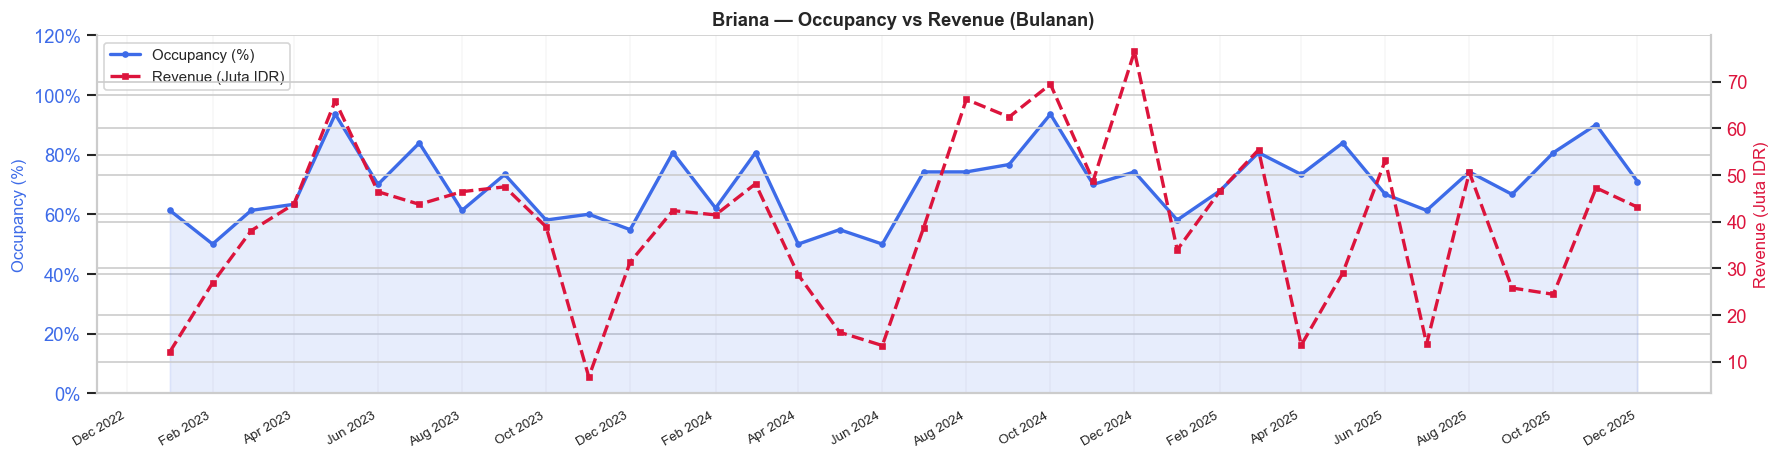

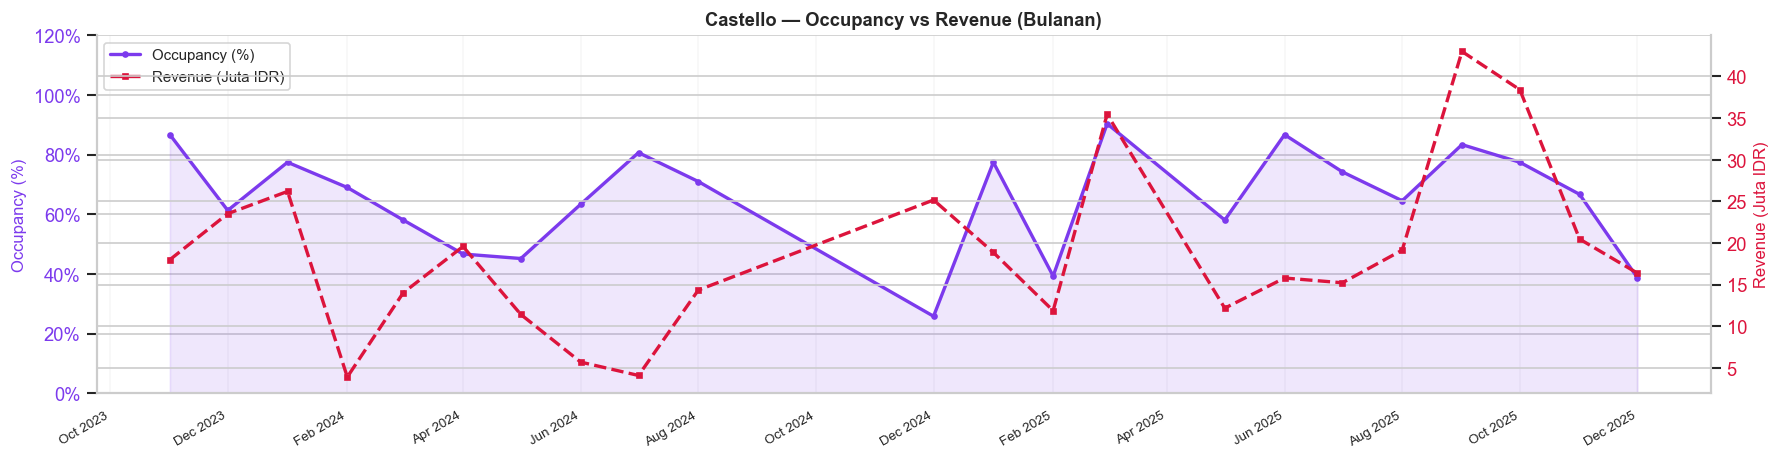

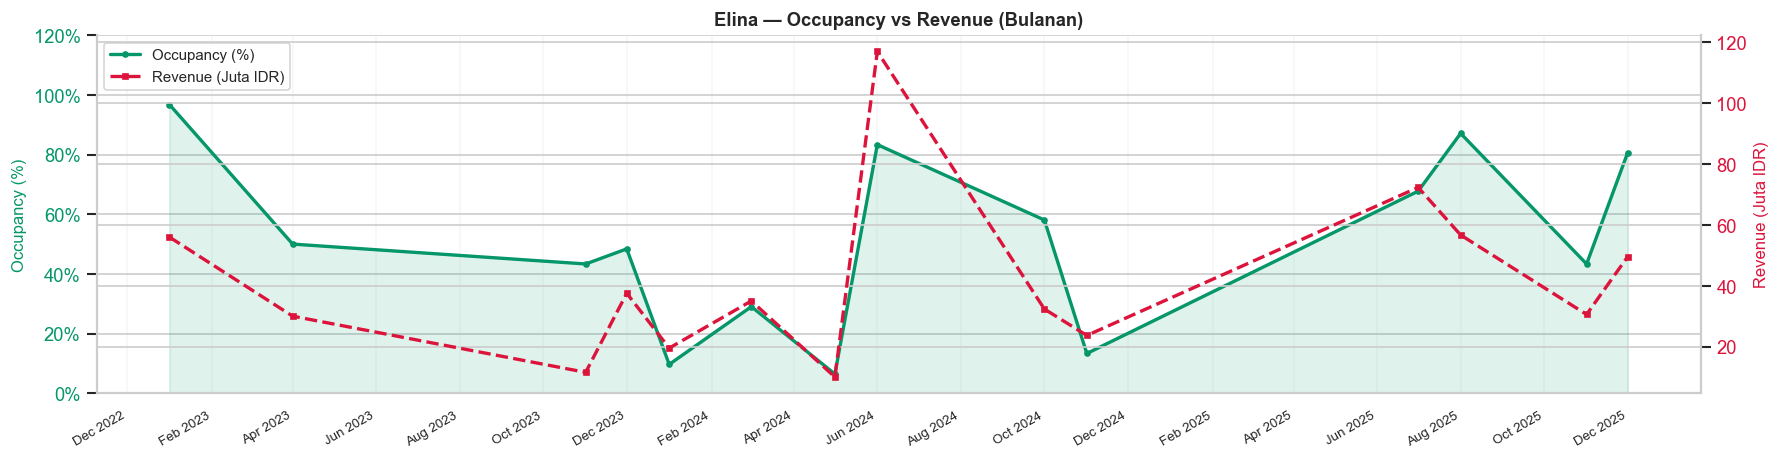

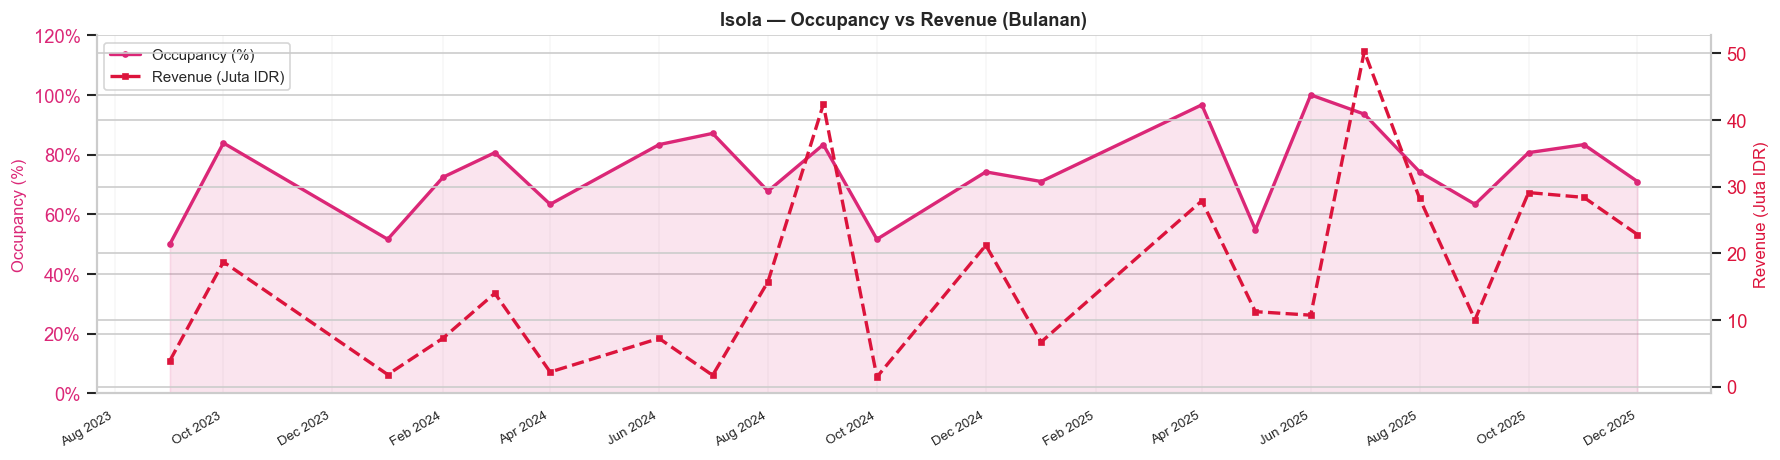

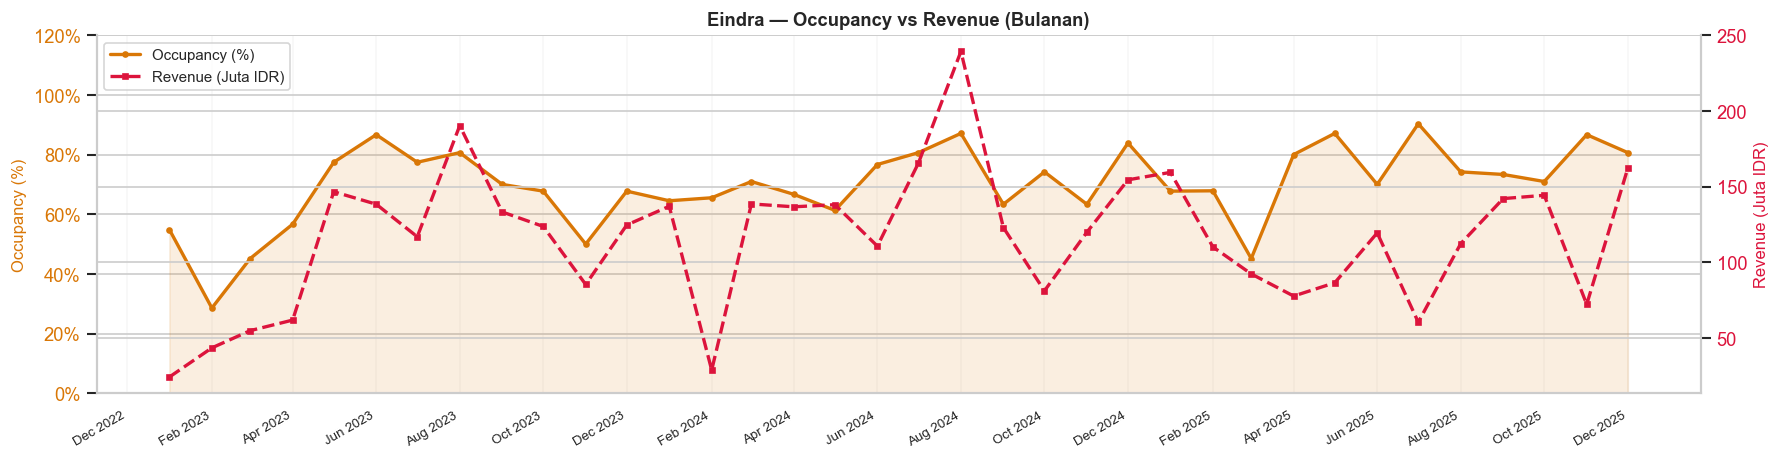

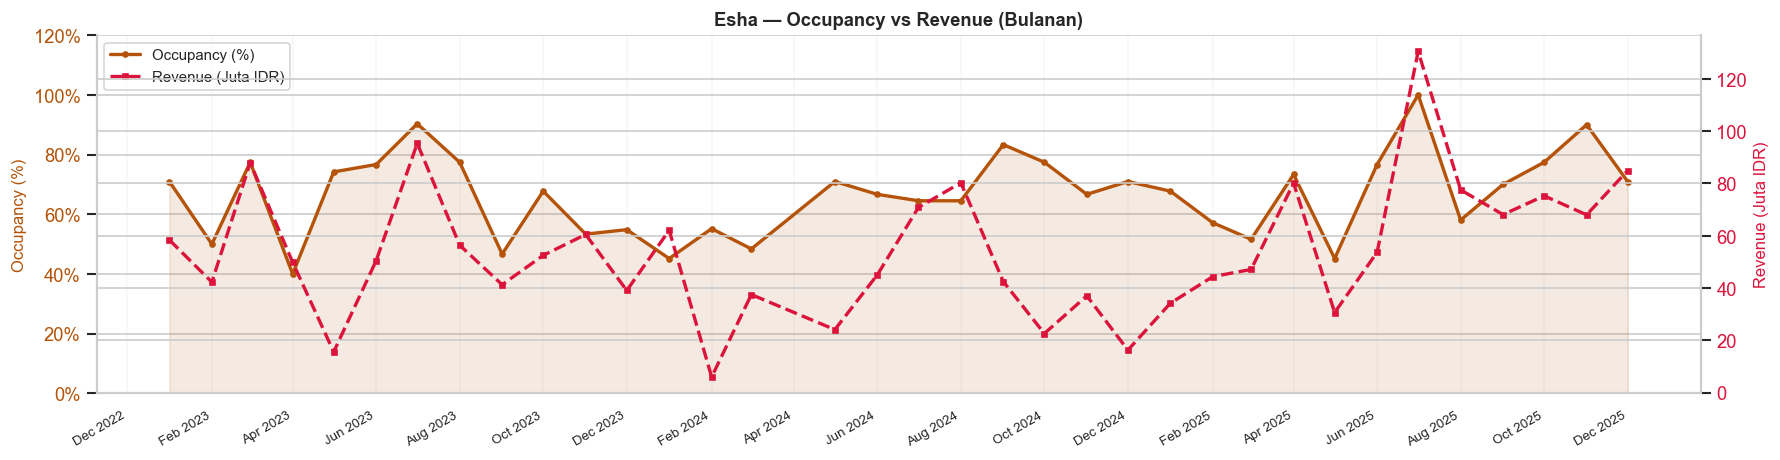

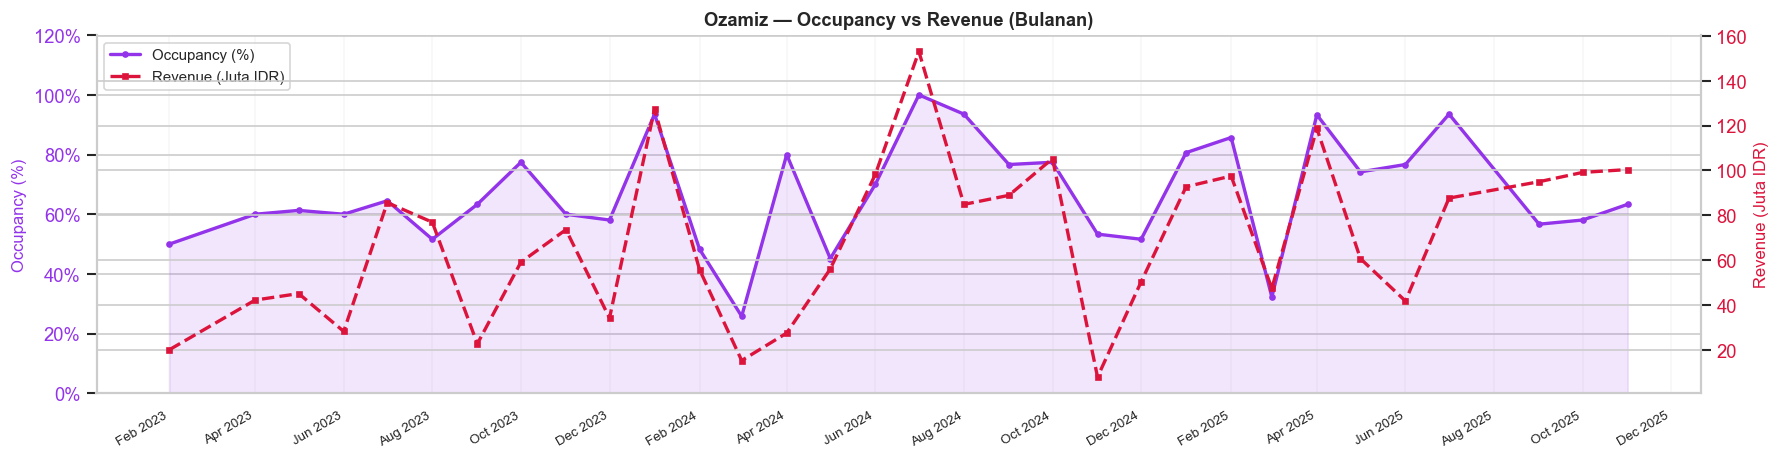

In [22]:
# ── 13d. DUAL-AXIS CHART: Occupancy (kiri) + Revenue (kanan)
if clean_fin:
    available = [v for v in clean_fin if v in clean_occ]
    for villa in available:
        color  = VILLA_CONFIG[villa]['color']
        title  = villa.replace('_villas','').title()
        occ_m  = clean_occ[villa].resample('MS').mean()
        comb   = pd.concat([occ_m.rename('occ'), clean_fin[villa]], axis=1).dropna()

        fig, ax1 = plt.subplots(figsize=(15, 4))
        ax2 = ax1.twinx()

        ax1.fill_between(comb.index, 0, comb['occ'], color=color, alpha=0.12)
        l1, = ax1.plot(comb.index, comb['occ'], color=color, lw=2,
                       marker='o', ms=3, label='Occupancy (%)')
        ax1.set_ylabel('Occupancy (%)', color=color, fontsize=10)
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.set_ylim(0, 120)
        ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))

        l2, = ax2.plot(comb.index, comb['revenue']/1e6, color='crimson',
                       lw=2, ls='--', marker='s', ms=3, label='Revenue (Juta IDR)')
        ax2.set_ylabel('Revenue (Juta IDR)', color='crimson', fontsize=10)
        ax2.tick_params(axis='y', labelcolor='crimson')

        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

        ax1.legend(handles=[l1, l2], loc='upper left', fontsize=9, framealpha=0.8)
        ax1.set_title(f'{title} — Occupancy vs Revenue (Bulanan)',
                      fontweight='bold', fontsize=11)
        ax1.grid(axis='x', alpha=0.15)
        ax1.spines['top'].set_visible(False)
        ax2.spines['top'].set_visible(False)

        plt.tight_layout()
        plt.savefig(f'dualaxis_{villa}.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('⚠️  Skip — data finansial tidak tersedia.')


---
## 14. Tabel Forecast Occupancy (+6 Bulan) — Semua Villa
Export ke CSV untuk digunakan di laporan atau dashboard.

In [23]:
# ── 14. TABEL FORECAST RINGKASAN (+6 BULAN)
FORECAST_STEPS = 6

rows = []
for villa, info in sarima_models.items():
    fitted = info['model']
    title  = villa.replace('_villas','').title()
    area   = VILLA_CONFIG[villa]['area'].title()

    fore   = fitted.get_forecast(steps=FORECAST_STEPS)
    mean_v = fore.predicted_mean.clip(0, 100)
    ci     = fore.conf_int(alpha=0.10)

    for date, val, lo, hi in zip(
        mean_v.index,
        mean_v.values,
        ci.iloc[:,0].clip(0,100).values,
        ci.iloc[:,1].clip(0,100).values,
    ):
        rows.append({
            'Villa'         : title,
            'Area'          : area,
            'Bulan'         : date.strftime('%b %Y'),
            'Forecast (%)'  : round(val, 2),
            'Lower CI 90%'  : round(lo, 2),
            'Upper CI 90%'  : round(hi, 2),
            'Rentang CI'    : round(hi - lo, 2),
        })

forecast_df = pd.DataFrame(rows)
print(f'FORECAST OCCUPANCY +{FORECAST_STEPS} BULAN KE DEPAN')
print('=' * 80)
display(forecast_df.set_index(['Villa','Bulan']))

forecast_df.to_csv('forecast_occupancy_6bulan.csv', index=False)
print('\n✅ Tersimpan: forecast_occupancy_6bulan.csv')


FORECAST OCCUPANCY +6 BULAN KE DEPAN


Area  Forecast (%)  Lower CI 90%  Upper CI 90%  \
Villa    Bulan                                                          
Briana   Jul 2025    Canggu         74.46         55.56         93.36   
         Aug 2025    Canggu         63.81         42.80         84.82   
         Sep 2025    Canggu         71.56         44.29         98.84   
         Oct 2025    Canggu         71.82         42.61        100.00   
         Nov 2025    Canggu         72.73         39.28        100.00   
         Dec 2025    Canggu         73.38         38.04        100.00   
Castello Jul 2025    Canggu         86.67         38.33        100.00   
         Aug 2025    Canggu         86.67         18.31        100.00   
         Sep 2025    Canggu         86.67          2.95        100.00   
         Oct 2025    Canggu         86.67          0.00        100.00   
         Nov 2025    Canggu         86.67          0.00        100.00   
         Dec 2025    Canggu         86.67          0.00        100.00   
Elina    Jul 2025    Canggu         46.67          0.00        100.00   
         Aug 2025    Canggu         46.67          0.00        100.00   
         Sep 2025    Canggu         46.67          0.00        100.00   
         Oct 2025    Canggu         46.67          0.00        100.00   
         Nov 2025    Canggu         46.67          0.00        100.00   
         Dec 2025    Canggu         46.67          0.00        100.00   
Isola    Jul 2025    Canggu         87.22         52.17        100.00   
         Aug 2025    Canggu         87.22         47.32        100.00   
         Sep 2025    Canggu         87.22         42.99        100.00   
         Oct 2025    Canggu         87.22         39.05        100.00   
         Nov 2025    Canggu         87.22         35.42        100.00   
         Dec 2025    Canggu         87.22         32.02        100.00   
Eindra   Jul 2025  Seminyak         74.68         52.22         97.13   
         Aug 2025  Seminyak         75.20         48.11        100.00   
         Sep 2025  Seminyak         75.72         44.62        100.00   
         Oct 2025  Seminyak         76.25         41.56        100.00   
         Nov 2025  Seminyak         76.78         38.80        100.00   
         Dec 2025  Seminyak         77.31         36.26        100.00   
Esha     Jul 2025  Seminyak         74.05         44.99        100.00   
         Aug 2025  Seminyak         71.51         31.12        100.00   
         Sep 2025  Seminyak         69.07         20.43        100.00   
         Oct 2025  Seminyak         66.71         11.47        100.00   
         Nov 2025  Seminyak         64.42          3.68        100.00   
         Dec 2025  Seminyak         62.22          0.00        100.00   
Ozamiz   Jul 2025  Seminyak        100.00         72.87        100.00   
         Aug 2025  Seminyak         81.73         54.69        100.00   
         Sep 2025  Seminyak         54.85         27.81         81.89   
         Oct 2025  Seminyak         95.42         68.38        100.00   
         Nov 2025  Seminyak         71.81         44.77         98.85   
         Dec 2025  Seminyak         77.36         50.32        100.00   

                   Rentang CI  
Villa    Bulan                 
Briana   Jul 2025       37.79  
         Aug 2025       42.02  
         Sep 2025       54.54  
         Oct 2025       57.39  
         Nov 2025       60.72  
         Dec 2025       61.96  
Castello Jul 2025       61.67  
         Aug 2025       81.69  
         Sep 2025       97.05  
         Oct 2025      100.00  
         Nov 2025      100.00  
         Dec 2025      100.00  
Elina    Jul 2025      100.00  
         Aug 2025      100.00  
         Sep 2025      100.00  
         Oct 2025      100.00  
         Nov 2025      100.00  
         Dec 2025      100.00  
Isola    Jul 2025       47.83  
         Aug 2025       52.68  
         Sep 2025       57.01  
         Oct 2025       60.95  
         Nov 2025       64.58  
         D


✅ Tersimpan: forecast_occupancy_6bulan.csv


---
## 15. Ringkasan Eksekutif

Sel ini mencetak narasi ringkas dari seluruh analisis yang sudah dilakukan.

In [24]:
# ── 15. RINGKASAN EKSEKUTIF OTOMATIS
print('=' * 75)
print('RINGKASAN EKSEKUTIF — ANALISIS SARIMA VILA BALI')
print('=' * 75)

print(f'\n📌 Total villa dianalisis : {len(sarima_models)}')
print(f'   Area                   : Canggu & Seminyak')
print(f'   Horizon forecast       : 6 bulan ke depan')

print('\n📊 Performa Model SARIMA:')
for r in sarima_results:
    status = '🟢 Baik' if r['MAPE (%)'] < 15 else ('🟡 Cukup' if r['MAPE (%)'] < 25 else '🔴 Perlu review')
    print(f"   {r['Villa']:20s} | Order: {r['Order']:30s} | MAPE: {r['MAPE (%)']:5.1f}% {status}")

if clean_fin:
    print('\n💰 Keterkaitan Occupancy–Revenue:')
    for row in corr_results:
        print(f"   {row['Villa']:20s} | r = {row['Pearson r']:+.3f} | {row['Interpretasi']}")

print('\n🔭 Forecast 6 Bulan Pertama per Villa:')
for villa in sarima_models:
    title = villa.replace('_villas','').title()
    sub   = forecast_df[forecast_df['Villa'] == title].head(3)
    vals  = ', '.join([f"{row['Bulan']}: {row['Forecast (%)']:.0f}%" for _, row in sub.iterrows()])
    print(f'   {title:20s} | {vals}')

print('\n✅ Analisis SARIMA selesai. Output tersedia:')
print('   - forecast_occupancy_6bulan.csv')
print('   - sarima_forecast_*.png  (plot per villa)')
print('   - scatter_occ_revenue.png, lag_corr_occ_revenue.png')
print('   - dualaxis_*.png')


RINGKASAN EKSEKUTIF — ANALISIS SARIMA VILA BALI

📌 Total villa dianalisis : 7
   Area                   : Canggu & Seminyak
   Horizon forecast       : 6 bulan ke depan

📊 Performa Model SARIMA:


KeyError: 'MAPE (%)'